# Preprocess .mat files
* version 1.1 CS 10
* data 20.10.2025
* author A.Subbotin

In [1]:
import scipy.io as sio  # Ensure scipy is imported for .mat file handling
import numpy as np  # Ensure numpy is imported for array handling
import pandas as pd  # Ensure pandas is imported for DataFrame handling
import matplotlib.pyplot as plt  # Ensure matplotlib is imported for plotting

In [2]:
def mat_to_pandas(mat_file_path, features_list):
    data = sio.loadmat(mat_file_path)

    # Extract the relevant data from the loaded .mat file
    insData = data['insData']
    extracted_data = {feature: insData[feature][0][0][0][0]['value'].T[0]  for feature in features_list}
    extracted_data['time'] = insData[features_list[0]][0][0][0][0]['time'].T[0]  # Extracting time separately    
    # Convert the extracted data to a pandas DataFrame
    df = pd.DataFrame.from_dict(extracted_data)

    return df

# Example usage
example_file_path = r"C:\Users\msbka\PINNS\Dataset\20140221_04_01_03_250lm.mat"

features = ['latitude', 'longitude', 'sideSlip', 'vxCG', 'vyCG', 'axCG', 'ayCG', 'yawRate']

features_filt = ['latitude', 'longitude', 'sideSlip', 'vxCG', 'vyCG', 'axCGFilt', 'ayCGFilt', 'yawRateFilt']
df = mat_to_pandas(example_file_path, features)

# Display the first few rows of the DataFrame
print(df.head())

   latitude  longitude  sideSlip  vxCG  vyCG      axCG      ayCG   yawRate  \
0       NaN        NaN       0.0   0.0   0.0  0.054183  0.042289  0.037534   
1       NaN        NaN       0.0   0.0   0.0  0.147014 -0.058505  0.388898   
2       NaN        NaN       0.0   0.0   0.0 -0.291975  0.730036 -0.142416   
3       NaN        NaN       0.0   0.0   0.0  0.111661 -0.086679  0.120025   
4       NaN        NaN       0.0   0.0   0.0  0.001944  0.053631  0.184540   

   time  
0  0.00  
1  0.01  
2  0.02  
3  0.03  
4  0.04  


* vxCG                       longitudinal velocity of the vehicle body measured at the center of gravity in meters per second
* vyCG                       lateral velocity of the vehicle body measured at the center of gravity in meters per second

* axCG                       longitudinal acceleration of the vehicle body measured at the center of gravity in meters per second per second
* ayCG                       lateral acceleration of the vehicle body measured at the center of gravity in meters per second per second

* yawRate                    vehicle body-frame angular rate in the z-direction in degrees per second
* yawAngle                   yaw angle (heading) of the vehicle body in degrees

* sideSlip                   vehicle body side slip angle defined as the angle between the vehicle body heading and the vehicle body horizontal velocity vector in degrees

In [3]:
from datetime import timedelta

def save_to_file(data, file_name):
    """
    Save the DataFrame to a CSV file.
    
    Parameters:
    data (pd.DataFrame): The DataFrame to save.
    file_name (str): The name of the file to save the DataFrame to.
    """
    data.to_csv(file_name, index=False)
    print(f"Data saved to {file_name}")

def plot_data(dataset, start_t=1000, stop_t=2260):
    start_td = timedelta(seconds=int(start_t))
    stop_td = timedelta(seconds=int(stop_t))
    duration_td = timedelta(seconds=int(stop_t - start_t))

    print(f"Start time: {str(start_td)}")
    print(f"Stop time: {str(stop_td)}")
    print(f"Duration: {str(duration_td)}")
    
    
    plt.figure(figsize=(20, 6))
    plt.plot(dataset['time'], dataset['vxCG'], label='Velocity X', color='blue')
    plt.plot(dataset['time'], dataset['vyCG'], label='Velocity Y', color='red')
    plt.vlines([start_t, stop_t], ymin=min(dataset['vxCG'].min(), dataset['vyCG'].min()),
           ymax=max(dataset['vxCG'].max(), dataset['vyCG'].max()),
           colors='green', linestyles='dashed', label='Interval')
    plt.ion()
    plt.xlabel('Time (s)')
    plt.ylabel('Velocity (m/s)')
    plt.title('Vehicle Velocities Over Time')
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(20, 6))
    plt.plot(dataset['time'], dataset['sideSlip'], label='Side Slip', color='purple')
    plt.vlines([start_t, stop_t], ymin=dataset['sideSlip'].min(), ymax=dataset['sideSlip'].max(),
           colors='green', linestyles='dashed', label='Interval')
    plt.xlabel('Time (s)')
    plt.ylabel('Side Slip (grad)')
    plt.title('Vehicle Side Slip Over Time')
    plt.legend()
    plt.grid()
    plt.show()
    
def plot_vehicle_path(train_data):
    plt.figure(figsize=(10, 6))
    plt.scatter(train_data['latitude'], train_data['longitude'], c=train_data['sideSlip'].abs(), label='Vehicle Path', marker='.', s=1, edgecolors='none', cmap='coolwarm', alpha=0.5,
                norm=plt.Normalize(vmin=0, vmax=1))
    plt.colorbar(label='Side Slip')
    plt.xlabel('Latitude')
    plt.ylabel('Longitude')
    plt.title('Vehicle Path Colored by Side Slip')
    plt.legend()
    plt.grid()
    plt.show()

___
# Test  data

In [3]:

test_file_path = r"C:\Users\msbka\PINNS\Dataset\20140221_04_01_03_250lm.mat"
test_data = mat_to_pandas(test_file_path, features)
# Display the first few rows of the test DataFrame
print(test_data.head())

   latitude  longitude  sideSlip  vxCG  vyCG      axCG      ayCG   yawRate  \
0       NaN        NaN       0.0   0.0   0.0  0.054183  0.042289  0.037534   
1       NaN        NaN       0.0   0.0   0.0  0.147014 -0.058505  0.388898   
2       NaN        NaN       0.0   0.0   0.0 -0.291975  0.730036 -0.142416   
3       NaN        NaN       0.0   0.0   0.0  0.111661 -0.086679  0.120025   
4       NaN        NaN       0.0   0.0   0.0  0.001944  0.053631  0.184540   

   time  
0  0.00  
1  0.01  
2  0.02  
3  0.03  
4  0.04  


In [4]:
start_t=50
stop_t=start_t + 11.5*60
plot_data(test_data, start_t=start_t, stop_t=stop_t)

NameError: name 'plot_data' is not defined

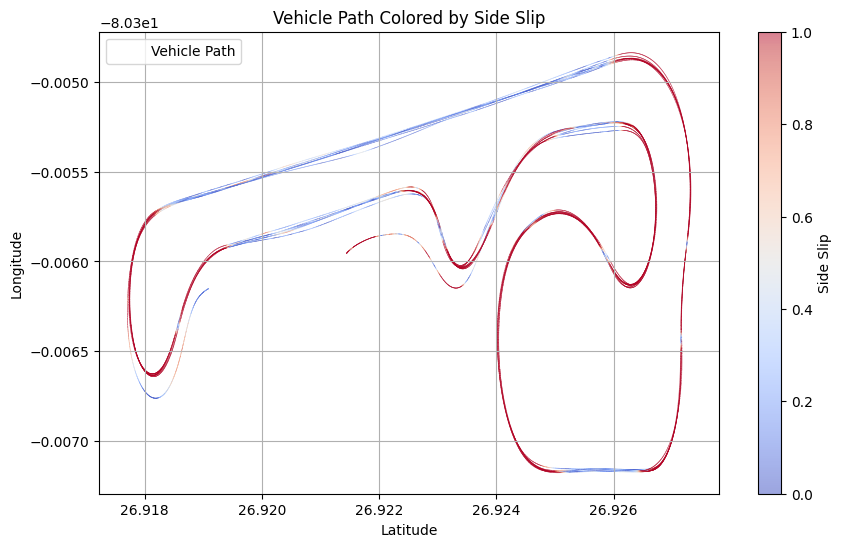

In [13]:
test_data = test_data[(test_data['time'] >= start_t) & (test_data['time'] <= stop_t)]

plot_vehicle_path(test_data)

In [7]:
save_to_file(test_data, 'processed_test_data.csv')

Data saved to processed_test_data.csv


# One Lap

___

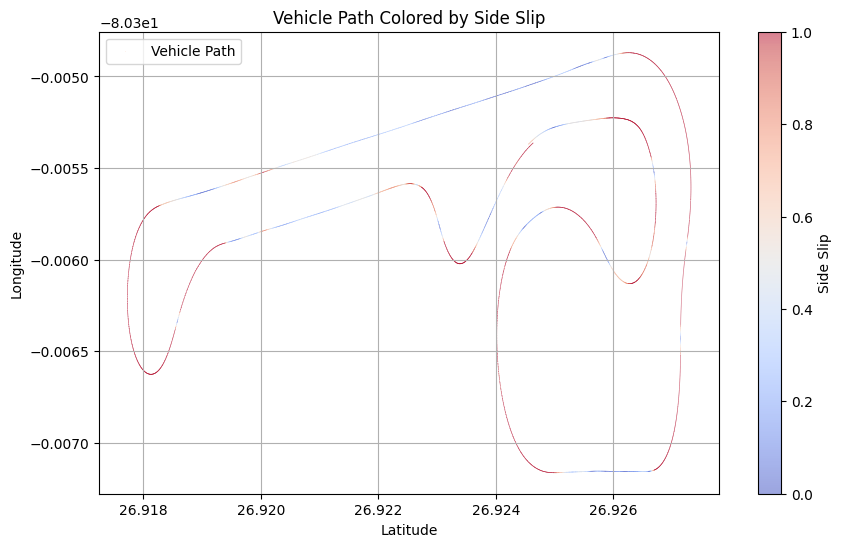

In [6]:
one_lap_data = test_data[(test_data['time'] >= 70) & (test_data['time'] <= 173)] #276
plot_vehicle_path(one_lap_data)

In [10]:
save_to_file(one_lap_data, 'processed_test_one_lap_data.csv')

Data saved to processed_test_one_lap_data.csv


# Training Data

The training data is obtained from the Revs Vehicle Dynamics Database.
The dataset corresponds to the 2013 Targa Sixty-Six event.

MAT File:
20130222_01_02_03_grandsport.mat

In [5]:

train_file_path = r"C:\Users\msbka\PINNS\Dataset\20130222_01_02_03_grandsport.mat"
train_data = mat_to_pandas(train_file_path, features)
# Display the first few rows of the test DataFrame
print(train_data.head())

    latitude  longitude  sideSlip      vxCG      vyCG      axCG      ayCG  \
0  26.920794 -80.306057       0.0 -0.008763  0.004499  0.215831  0.571743   
1  26.920794 -80.306057       0.0 -0.008364  0.012522  0.009553 -0.654905   
2  26.920794 -80.306057       0.0 -0.007207  0.019551 -0.088390 -0.241379   
3  26.920794 -80.306057       0.0 -0.009070 -0.000904  0.063293  0.049130   
4  26.920794 -80.306057       0.0 -0.008928 -0.009824 -0.000731 -0.062028   

    yawRate  time  
0 -0.064669  0.00  
1  0.041858  0.01  
2  0.076798  0.02  
3 -0.026415  0.03  
4  0.006813  0.04  


## Handle NaN values and interpolate missing entries

In [6]:

# Display the number of NaN values before preprocessing
print("NaN values before interpolation:\n")
print(train_data.isna().sum())

# Apply linear interpolation to fill missing values in all columns.
# The 'limit_direction' argument ensures interpolation occurs at the beginning
# and end of the dataset if needed.
train_data.interpolate(method="linear", limit_direction="both", inplace=True)

# Replace any remaining NaN values (if interpolation is not possible) with zeros.
train_data.fillna(0, inplace=True)

# Display the number of NaN values after preprocessing
print("\nNaN values after interpolation and filling:\n")
print(train_data.isna().sum())



NaN values before interpolation:

latitude     0
longitude    0
sideSlip     0
vxCG         0
vyCG         0
axCG         0
ayCG         0
yawRate      0
time         0
dtype: int64

NaN values after interpolation and filling:

latitude     0
longitude    0
sideSlip     0
vxCG         0
vyCG         0
axCG         0
ayCG         0
yawRate      0
time         0
dtype: int64


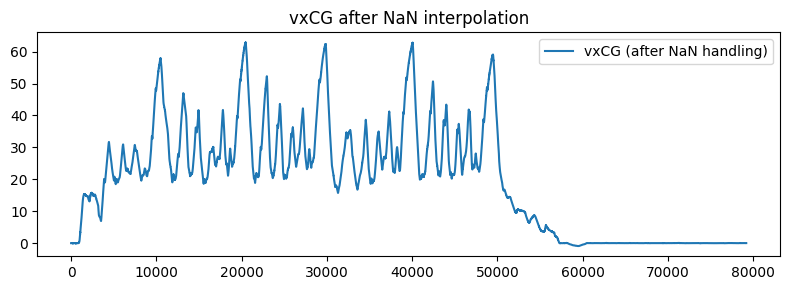

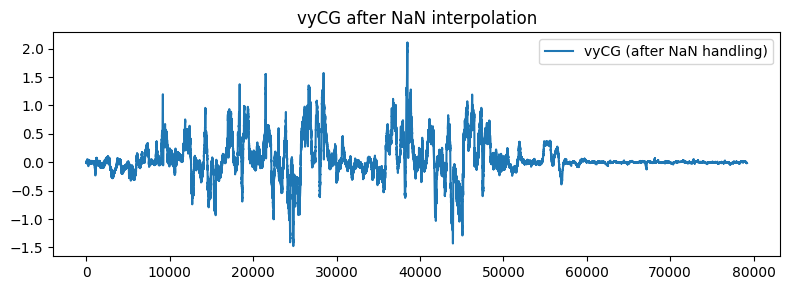

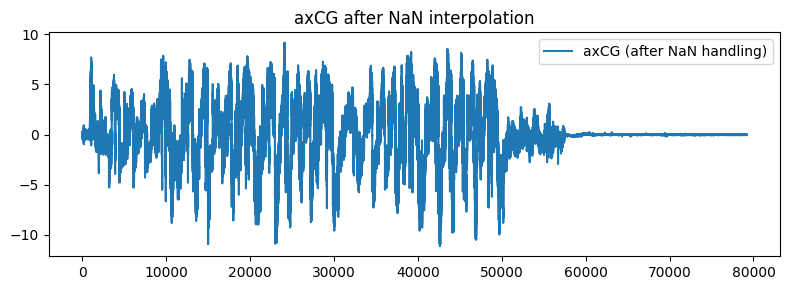

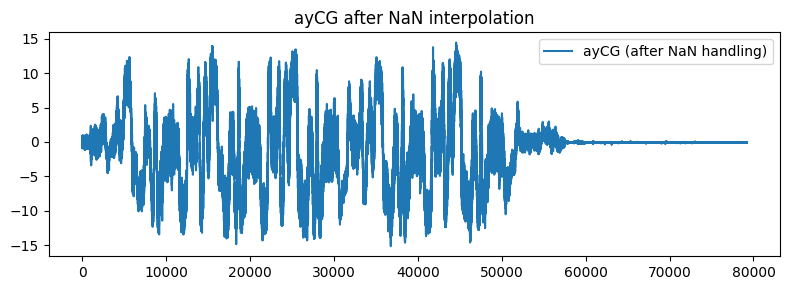

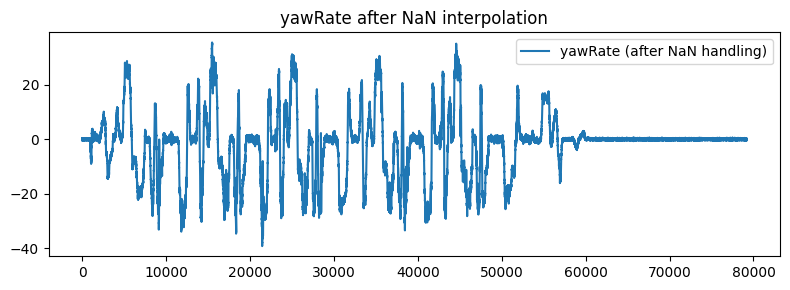

In [16]:

# Plotting After NAN Handling

cols_to_plot = ['vxCG', 'vyCG', 'axCG', 'ayCG', 'yawRate']
for col in cols_to_plot:
    plt.figure(figsize=(8, 3))
    plt.plot(train_data[col].values, label=f'{col} (after NaN handling)')
    plt.title(f'{col} after NaN interpolation')
    plt.legend()
    plt.tight_layout()
    plt.show()


## Signal Smoothing Using Savitzky–Golay Filter

To reduce measurement noise in the vehicle dynamics signals, a Savitzky–Golay filter is applied.

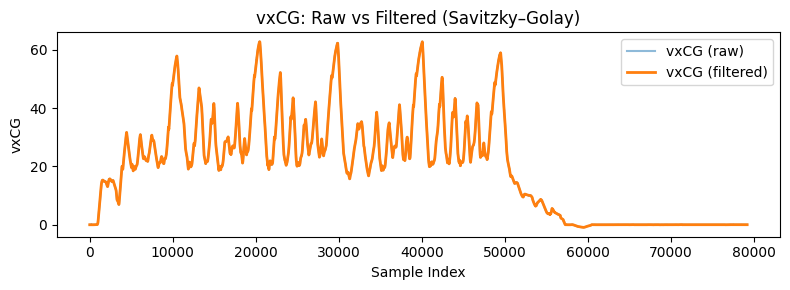

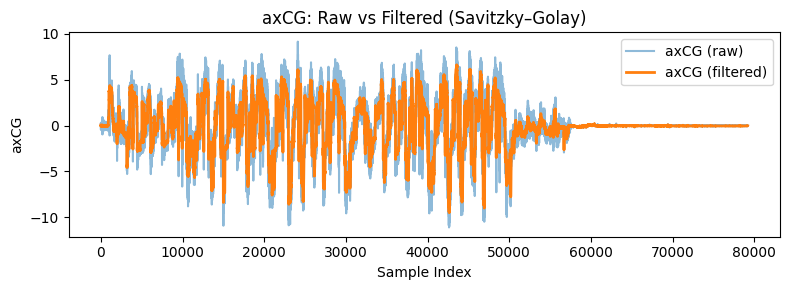

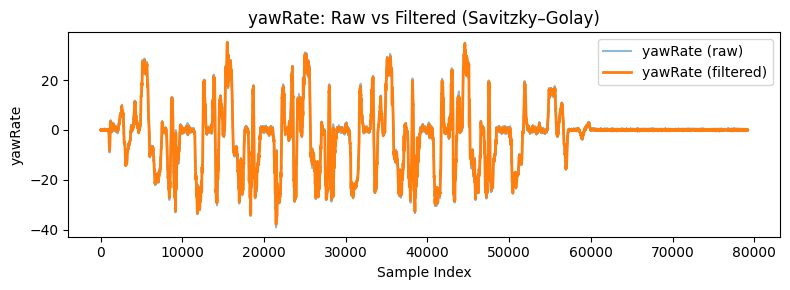

In [7]:
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

def smooth_signal(sig, window=31, poly=2):
    """
    Apply Savitzky–Golay filtering to smooth a one-dimensional signal.

    Parameters
    ----------
    sig : array-like
        Input signal to be smoothed.
    window : int, optional
        Window length for the filter. Must be a positive odd integer.
        If the provided window is too large or even, it is adjusted automatically.
    poly : int, optional
        Polynomial order used by the filter.

    Returns
    -------
    ndarray
        Smoothed version of the input signal.
    """

    # Ensure the window size is valid relative to the signal length
    if window >= len(sig):
        window = len(sig) - 1 if len(sig) % 2 == 0 else len(sig)

    # Window length must be odd
    if window % 2 == 0:
        window += 1

    return savgol_filter(sig, window_length=window, polyorder=poly, mode='nearest')


# Core vehicle dynamics channels to smooth
cols_to_filter = ["vxCG", "vyCG", "axCG", "ayCG", "yawRate"]

# Apply smoothing and create new filtered columns
for col in cols_to_filter:
    train_data[col + "_filt"] = smooth_signal(
        train_data[col].values, window=31, poly=2
    )


# Plot comparison: raw vs filtered signals
for col in ["vxCG", "axCG", "yawRate"]:
    plt.figure(figsize=(8, 3))
    plt.plot(train_data[col].values, label=f"{col} (raw)", alpha=0.5)
    plt.plot(train_data[col + "_filt"].values, label=f"{col} (filtered)", linewidth=2)
    plt.title(f"{col}: Raw vs Filtered (Savitzky–Golay)")
    plt.xlabel("Sample Index")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [13]:

# Train data After filtering
print(train_data.head())

    latitude  longitude  sideSlip      vxCG      vyCG      axCG      ayCG  \
0  26.920794 -80.306057       0.0 -0.008763  0.004499  0.215831  0.571743   
1  26.920794 -80.306057       0.0 -0.008364  0.012522  0.009553 -0.654905   
2  26.920794 -80.306057       0.0 -0.007207  0.019551 -0.088390 -0.241379   
3  26.920794 -80.306057       0.0 -0.009070 -0.000904  0.063293  0.049130   
4  26.920794 -80.306057       0.0 -0.008928 -0.009824 -0.000731 -0.062028   

    yawRate  time  vxCG_filt  vyCG_filt  axCG_filt  ayCG_filt  yawRate_filt  
0 -0.064669  0.00  -0.009400   0.002455   0.061933   0.224746     -0.000639  
1  0.041858  0.01  -0.009507   0.001817   0.048313   0.195024     -0.013570  
2  0.076798  0.02  -0.009565   0.001258   0.025589   0.133943      0.013570  
3 -0.026415  0.03  -0.009590   0.001107   0.006740   0.128307      0.005980  
4  0.006813  0.04  -0.009600   0.000440  -0.014667   0.068254      0.004340  



## Data preparation and DataLoader setup

Traindata Split into Train (80%) and validation (20%).

In [8]:

# The code below prepares one-step-ahead training pairs
# kinematic vehicle model and constructs PyTorch DataLoaders.

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ---------------------------------------------------------------------
# Build input (X_k) and target (X_{k+1}) arrays from filtered signals
# ---------------------------------------------------------------------
vx = train_data["vxCG_filt"].values
vy = train_data["vyCG_filt"].values
r  = train_data["yawRate_filt"].values
ax = train_data["axCG_filt"].values
ay = train_data["ayCG_filt"].values

# Input at time k:  [vx, vy, r, ax, ay]
# Target at time k+1: [vx_next, vy_next]
X = np.column_stack([vx[:-1], vy[:-1], r[:-1], ax[:-1], ay[:-1]])
Y = np.column_stack([vx[1:], vy[1:]])

print(f"Full dataset -> Inputs: {X.shape}, Targets: {Y.shape}")

# ---------------------------------------------------------------------
# Train/test split
# ---------------------------------------------------------------------
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

# ---------------------------------------------------------------------
# Feature-wise scalers
# - Use MinMax for vx (non-negative, bounded) and StandardScaler for
#   the signals that can take positive and negative values.
# - Fit scalers on training data only to avoid data leakage.
# ---------------------------------------------------------------------
scaler_vx = MinMaxScaler(feature_range=(0.0, 1.0))
scaler_vy = StandardScaler()
scaler_r  = StandardScaler()
scaler_ax = StandardScaler()
scaler_ay = StandardScaler()
scaler_Y  = StandardScaler()  # targets: vx_next, vy_next

# Fit scalers to training partitions (column slices keep 2D shape)
scaler_vx.fit(X_train[:, [0]])
scaler_vy.fit(X_train[:, [1]])
scaler_r.fit(X_train[:, [2]])
scaler_ax.fit(X_train[:, [3]])
scaler_ay.fit(X_train[:, [4]])
scaler_Y.fit(Y_train)

# Transform train and test sets
X_train_scaled = np.column_stack([
    scaler_vx.transform(X_train[:, [0]]),
    scaler_vy.transform(X_train[:, [1]]),
    scaler_r.transform(X_train[:, [2]]),
    scaler_ax.transform(X_train[:, [3]]),
    scaler_ay.transform(X_train[:, [4]]),
])
X_test_scaled = np.column_stack([
    scaler_vx.transform(X_test[:, [0]]),
    scaler_vy.transform(X_test[:, [1]]),
    scaler_r.transform(X_test[:, [2]]),
    scaler_ax.transform(X_test[:, [3]]),
    scaler_ay.transform(X_test[:, [4]]),
])

Y_train_scaled = scaler_Y.transform(Y_train)
Y_test_scaled  = scaler_Y.transform(Y_test)

print("Scaling complete.")
print("Scaled X_train sample:\n", np.round(X_train_scaled[:3], 3))
print("Scaled Y_train sample:\n", np.round(Y_train_scaled[:3], 3))

# ---------------------------------------------------------------------
# Utility transform functions (useful at inference/evaluation time)
# ---------------------------------------------------------------------
def transform_X(X):
    """
    Scale raw input features to the model input space.

    Parameters
    ----------
    X : ndarray, shape (n_samples, 5)
        Raw inputs in order [vx, vy, r, ax, ay].

    Returns
    -------
    ndarray, shape (n_samples, 5)
        Scaled inputs using the feature-wise scalers fitted on training data.
    """
    return np.column_stack([
        scaler_vx.transform(X[:, [0]]),
        scaler_vy.transform(X[:, [1]]),
        scaler_r.transform(X[:, [2]]),
        scaler_ax.transform(X[:, [3]]),
        scaler_ay.transform(X[:, [4]]),
    ])


def inverse_transform_Y(Y_scaled):
    """
    Convert scaled model outputs back to physical units.

    Parameters
    ----------
    Y_scaled : ndarray or tensor-like, shape (n_samples, 2)
        Scaled outputs from the model.

    Returns
    -------
    ndarray, shape (n_samples, 2)
        Outputs in original physical units corresponding to [vx_next, vy_next].
    """
    return scaler_Y.inverse_transform(Y_scaled)

# ---------------------------------------------------------------------
# PyTorch Dataset and DataLoader
# ---------------------------------------------------------------------
class VehicleDataset(Dataset):
    """
    Simple Dataset for vehicle one-step-ahead training pairs.

    Each item is a tuple (X_scaled, Y_scaled) where:
      - X_scaled : torch.float32 tensor of shape (5,)
      - Y_scaled : torch.float32 tensor of shape (2,)
    """
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


train_dataset = VehicleDataset(X_train_scaled, Y_train_scaled)
test_dataset  = VehicleDataset(X_test_scaled,  Y_test_scaled)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
Val_Data_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

print("Train/test split and scaled DataLoaders ready.")


Full dataset -> Inputs: (79199, 5), Targets: (79199, 2)
Training samples: 63359 | Testing samples: 15840
Scaling complete.
Scaled X_train sample:
 [[ 0.304 -0.323 -1.684  0.671 -1.314]
 [ 0.419  1.026 -0.868  1.267 -1.068]
 [ 0.594 -1.499  0.758  1.794  1.163]]
Scaled Y_train sample:
 [[-0.078 -0.32 ]
 [ 0.354  1.018]
 [ 1.016 -1.496]]
Train/test split and scaled DataLoaders ready.


C:\Users\msbka\AppData\Local\Temp\ipykernel_29836\2615630808.py:7: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


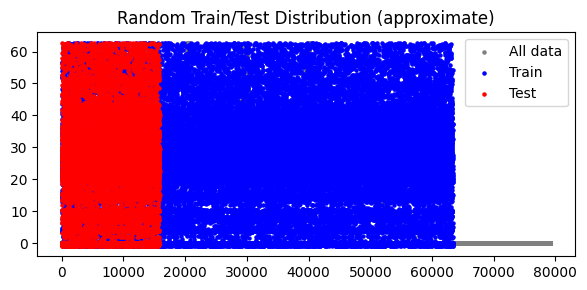

In [9]:
plt.figure(figsize=(6,3))
plt.scatter(range(len(vx)-1), vx[:-1], c='gray', s=5, label='All data')
plt.scatter(range(len(X_train)), X_train[:,0], c='blue', s=5, label='Train')
plt.scatter(range(len(X_test)), X_test[:,0], c='red', s=5, label='Test')
plt.title("Random Train/Test Distribution (approximate)")
plt.legend()
plt.tight_layout()
plt.show()

# External Test Dataset

For evaluating the trained PINN model, an independent dataset from the Revs Vehicle Dynamics Database is used.
This dataset corresponds to the 2014 Targa Sixty-Six event.

MAT File: 20140221_04_01_03_250lm.mat

it is denoted as Car B

In [ ]:
test_file_path = r"C:\Users\msbka\PINNS\Dataset\20140221_04_01_03_250lm.mat"
test_data_carB = mat_to_pandas(test_file_path, features)
# Display the first few rows of the test DataFrame
print(test_data_carB.head())

   latitude  longitude  sideSlip  vxCG  vyCG      axCG      ayCG   yawRate  \
0       NaN        NaN       0.0   0.0   0.0  0.054183  0.042289  0.037534   
1       NaN        NaN       0.0   0.0   0.0  0.147014 -0.058505  0.388898   
2       NaN        NaN       0.0   0.0   0.0 -0.291975  0.730036 -0.142416   
3       NaN        NaN       0.0   0.0   0.0  0.111661 -0.086679  0.120025   
4       NaN        NaN       0.0   0.0   0.0  0.001944  0.053631  0.184540   

   time  
0  0.00  
1  0.01  
2  0.02  
3  0.03  
4  0.04  


In [11]:

# Load  car (Car B) dataset

vx_b = test_data_carB['vxCG'].values
vy_b = test_data_carB['vyCG'].values
r_b  = test_data_carB['yawRate'].values
ax_b = test_data_carB['axCG'].values
ay_b = test_data_carB['ayCG'].values

# Prepare input/output just like before
X_B = np.column_stack([vx_b[:-1], vy_b[:-1], r_b[:-1], ax_b[:-1], ay_b[:-1]])
Y_B = np.column_stack([vx_b[1:], vy_b[1:]])

print(f"External dataset (Car B) -> Inputs: {X_B.shape}, Targets: {Y_B.shape}")

External dataset (Car B) -> Inputs: (88799, 5), Targets: (88799, 2)


In [12]:
# Scale Car B using scalers from Car A
X_B_scaled = np.column_stack([
    scaler_vx.transform(X_B[:, [0]]),
    scaler_vy.transform(X_B[:, [1]]),
    scaler_r.transform(X_B[:, [2]]),
    scaler_ax.transform(X_B[:, [3]]),
    scaler_ay.transform(X_B[:, [4]]),
])
Y_B_scaled = scaler_Y.transform(Y_B)

# Create PyTorch dataset and DataLoader
test_dataset_carB = VehicleDataset(X_B_scaled, Y_B_scaled)
test_loader_carB  = DataLoader(test_dataset_carB, batch_size=128, shuffle=False)

save_to_file(test_data_carB, 'processed_test_data_carB.csv')    



print(" External Car B DataLoader ready.")


NameError: name 'save_to_file' is not defined

# RMSE LOSS FUNCTION

In [14]:
import torch.nn as nn

class RMSELoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.mse = nn.MSELoss()
        self.eps = eps

    def forward(self, y_pred, y_true):
        return torch.sqrt(self.mse(y_pred, y_true) + self.eps)

criterion = RMSELoss()


# Baseline Neural Network Model

This baseline model is a purely data-driven feed-forward neural network trained to predict one-step-ahead vehicle states.


**Model Configuration**

Activation Function: ReLU

Number of Epochs: 50

Loss Function: RMSE (Root Mean Squared Error)`
```



VehicleNN(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
Epoch [1/50] | Train Loss: 0.133022 | Test Loss: 0.024972
Epoch [2/50] | Train Loss: 0.020018 | Test Loss: 0.017496
Epoch [3/50] | Train Loss: 0.016238 | Test Loss: 0.013702
Epoch [4/50] | Train Loss: 0.014112 | Test Loss: 0.015650
Epoch [5/50] | Train Loss: 0.012886 | Test Loss: 0.014980
Epoch [6/50] | Train Loss: 0.012496 | Test Loss: 0.011219
Epoch [7/50] | Train Loss: 0.011255 | Test Loss: 0.011434
Epoch [8/50] | Train Loss: 0.011257 | Test Loss: 0.009999
Epoch [9/50] | Train Loss: 0.010940 | Test Loss: 0.009888
Epoch [10/50] | Train Loss: 0.010289 | Test Loss: 0.010835
Epoch [11/50] | Train Loss: 0.010523 | Test Loss: 0.009357
Epoch [12/50] | Train Loss: 0.009838 | Test Loss: 0.010577
Epoch [13/50] | Train Loss: 0.009593 | Test Loss: 0.0

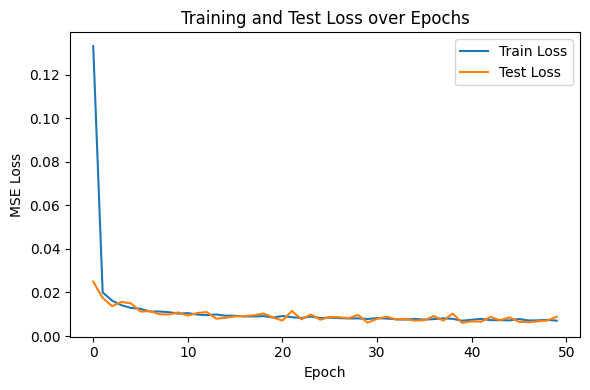

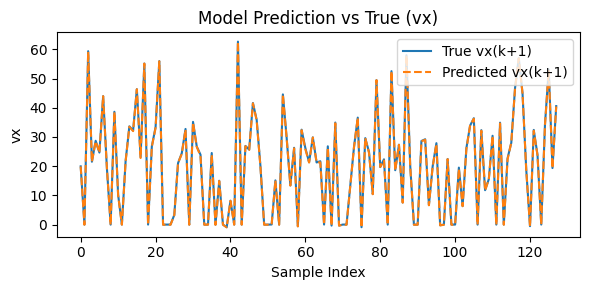

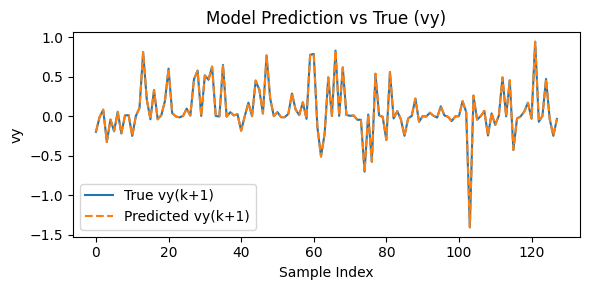

In [15]:
# Baseline data-driven neural network model
# The code below defines a simple feed-forward neural network, 
# trains it to predict one-step-ahead vehicle states, 
# and visualizes prediction performance on the scaled and real-unit test data.

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Neural Network Architecture
# ---------------------------------------------------------------------
class VehicleNN(nn.Module):
    """
    Feed-forward neural network for one-step-ahead vehicle state prediction.

    Parameters
    ----------
    input_dim : int
        Number of input features per time step.
    hidden_dim : int
        Number of neurons in the hidden layers.
    output_dim : int
        Dimension of the output vector (vx_{k+1}, vy_{k+1}).
    """
    def __init__(self, input_dim=5, hidden_dim=64, output_dim=2):
        super(VehicleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        """Forward pass through the network."""
        return self.net(x)


# Instantiate model
model = VehicleNN()
print(model)

# ---------------------------------------------------------------------
# Loss function and optimizer
# ---------------------------------------------------------------------
criterion = RMSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ---------------------------------------------------------------------
# Training loop
# ---------------------------------------------------------------------
num_epochs = 50
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # Training step
    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluation step
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, Y_batch in Val_Data_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, Y_batch)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(Val_Data_loader)
    test_losses.append(avg_test_loss)

    print(f"Epoch [{epoch + 1}/{num_epochs}] | "
          f"Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")

print("Training complete.")

# ---------------------------------------------------------------------
# Plot training and test loss curves
# ---------------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Training and Test Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Evaluate model on a batch of test samples (real unit comparison)
# ---------------------------------------------------------------------
model.eval()
with torch.no_grad():
    X_test_sample, Y_test_sample = next(iter(Val_Data_loader))
    Y_pred_scaled = model(X_test_sample).cpu().numpy()
    Y_true_scaled = Y_test_sample.cpu().numpy()

# Inverse scaling to obtain real physical units
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled)
Y_true = scaler_Y.inverse_transform(Y_true_scaled)

# ---------------------------------------------------------------------
# Plot vx prediction comparison
# ---------------------------------------------------------------------
plt.figure(figsize=(6, 3))
plt.plot(Y_true[:200, 0], label="True vx(k+1)")
plt.plot(Y_pred[:200, 0], label="Predicted vx(k+1)", linestyle="--")
plt.title("Model Prediction vs True (vx)")
plt.xlabel("Sample Index")
plt.ylabel("vx")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Plot vy prediction comparison
# ---------------------------------------------------------------------
plt.figure(figsize=(6, 3))
plt.plot(Y_true[:200, 1], label="True vy(k+1)")
plt.plot(Y_pred[:200, 1], label="Predicted vy(k+1)", linestyle="--")
plt.title("Model Prediction vs True (vy)")
plt.xlabel("Sample Index")
plt.ylabel("vy")
plt.legend()
plt.tight_layout()
plt.show()


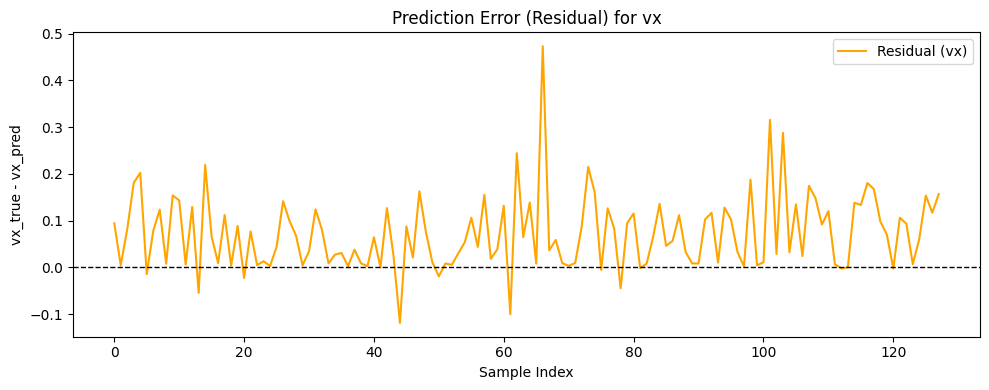

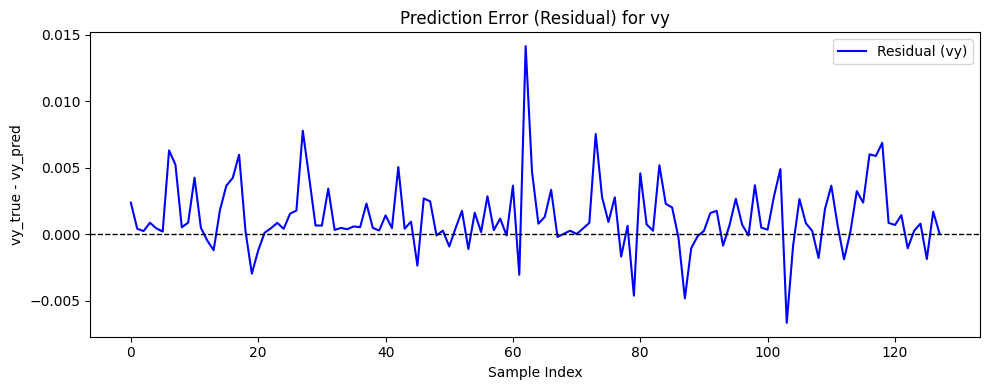

vx Residuals → Mean: 0.072247, Std: 0.080997, RMSE: 0.108536
vy Residuals → Mean: 0.001277, Std: 0.002583, RMSE: 0.002881


In [25]:

import matplotlib.pyplot as plt
import numpy as np

# Compute residuals (difference between true and predicted)
residual_vx = Y_true[:, 0] - Y_pred[:, 0]
residual_vy = Y_true[:, 1] - Y_pred[:, 1]

# Plot residuals over sample index
plt.figure(figsize=(10, 4))
plt.plot(residual_vx, label='Residual (vx)', color='orange')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Prediction Error (Residual) for vx")
plt.xlabel("Sample Index")
plt.ylabel("vx_true - vx_pred")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(residual_vy, label='Residual (vy)', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Prediction Error (Residual) for vy")
plt.xlabel("Sample Index")
plt.ylabel("vy_true - vy_pred")
plt.legend()
plt.tight_layout()
plt.show()


def residual_stats(name, residuals):
    mean_err = np.mean(residuals)
    std_err = np.std(residuals)
    rmse = np.sqrt(np.mean(residuals**2))
    print(f"{name} Residuals → Mean: {mean_err:.6f}, Std: {std_err:.6f}, RMSE: {rmse:.6f}")

residual_stats("vx", residual_vx)
residual_stats("vy", residual_vy)


# Kinematic Vehicle Model (KVM) Solver

Computes the next-step velocities using a first-order kinematic update.


In [16]:
# Kinematic Vehicle Model (KVM) Solver
# Computes the next-step velocities using a first-order kinematic update.

import torch

def physics_next_state(vx, vy, r, ax, ay, dt=0.01):
    """
    Compute the next-step longitudinal and lateral velocities using the
    discrete-time Kinematic Vehicle Model (KVM).

    Parameters
    ----------
    vx : tensor
        Longitudinal velocity at time step k.
    vy : tensor
        Lateral velocity at time step k.
    r : tensor
        Yaw rate at time step k.
    ax : tensor
        Longitudinal acceleration at time step k.
    ay : tensor
        Lateral acceleration at time step k.
    dt : float, optional
        Sampling time step for integration.

    Returns
    -------
    vx_next : tensor
        Predicted longitudinal velocity at time step k+1.
    vy_next : tensor
        Predicted lateral velocity at time step k+1.
    """

    # Kinematic update equations
    vx_next = vx + dt * (ax - r * vy)
    vy_next = vy + dt * (ay + r * vx)

    return vx_next, vy_next


# Quick sanity check
vx0 = torch.tensor([20.0])
vy0 = torch.tensor([0.5])
r0  = torch.tensor([0.1])
ax0 = torch.tensor([2.0])
ay0 = torch.tensor([-0.5])

vx_next, vy_next = physics_next_state(vx0, vy0, r0, ax0, ay0)
print(f"vx_next: {vx_next.item():.3f}, vy_next: {vy_next.item():.3f}")


vx_next: 20.020, vy_next: 0.515


# Latin Hypercube Sampling of Initial Conditions



In [17]:
from scipy.stats import qmc
import numpy as np

def generate_initial_conditions(N_phys=5):
    """
    Generate physically meaningful initial conditions for physics-based
    residual computation using Latin Hypercube Sampling (LHS).

    Variables sampled:
        vx, vy, r, ax, ay

    Parameters
    ----------
    N_phys : int
        Number of physics sample points to generate.

    Returns
    -------
    ndarray, shape (N_phys, 5)
        Sampled initial conditions.
    """

    sampler = qmc.LatinHypercube(d=5)
    sample = sampler.random(n=N_phys)

    # physical bounds for variables [vx, vy, r, ax, ay]
    lower_bounds = [0, -8, -20, -40, -50]
    upper_bounds = [70, 8, 20, 40, 50]

    initial_conditions = qmc.scale(sample, lower_bounds, upper_bounds)
    return initial_conditions


# Example generation test
X_phys_small = generate_initial_conditions(N_phys=4)
print("Random Physics Points Generated (small test set)")
print("Shape:", X_phys_small.shape)
print("Generated Points:\n", np.round(X_phys_small, 3))


Random Physics Points Generated (small test set)
Shape: (4, 5)
Generated Points:
 [[ 23.281   6.77   11.473 -38.177  47.439]
 [  6.424   1.403 -19.991 -16.313  -2.393]
 [ 63.327  -0.524   4.693  31.773   5.787]
 [ 47.567  -7.903  -3.71    6.731 -49.321]]


In [18]:

#  SCALE RANDOM POINTS

N_phys = 4  # or 5 for now (start small for testing)
X_phys_real = generate_initial_conditions(N_phys)

print(" Random Physics Points (Real Units):")
print(np.round(X_phys_real, 3))

# --- Scale them using the same feature-wise scalers ---
X_phys_scaled = transform_X(X_phys_real)

print("\n Random Physics Points (Scaled Units):")
print(np.round(X_phys_scaled, 3))

# --- Sanity check ---
print(f"\nShape of X_phys_real:   {X_phys_real.shape}")
print(f"Shape of X_phys_scaled: {X_phys_scaled.shape}")




 Random Physics Points (Real Units):
[[ 61.974   6.635 -19.606 -37.564  -9.871]
 [ 20.086   2.094   1.989  -6.418 -43.491]
 [ 13.173  -2.832  -4.424   2.74   23.309]
 [ 48.036  -5.314  15.509  23.818  44.69 ]]

 Random Physics Points (Scaled Units):
[[  0.987  21.334  -1.5   -14.8    -1.917]
 [  0.33    6.607   0.352  -2.542  -9.2  ]
 [  0.221  -9.365  -0.198   1.062   5.27 ]
 [  0.768 -17.413   1.511   9.358   9.902]]

Shape of X_phys_real:   (4, 5)
Shape of X_phys_scaled: (4, 5)


# Compute Physics Loss




In [27]:

# import torch
# import numpy as np
# import matplotlib.pyplot as plt

# def compute_physics_loss(model, X_phys_real, X_phys_scaled, dt=0.01, debug=False):
#     """
#     Parameters
#     ----------
#     model : torch.nn.Module
#         Trained neural network that maps scaled inputs -> scaled outputs.
#     X_phys_real : np.ndarray, shape (N_phys, 5)
#         Collocation points in real physical units arranged as columns:
#         [vx, vy, r, ax, ay].
#     X_phys_scaled : np.ndarray, shape (N_phys, 5)
#         The same collocation points transformed into the model's input (scaled) space.
#     dt : float, optional
#         Time-step for the discrete KVM (default 0.01).
#     device : torch.device or None, optional
#         Device to run inference on. If None, uses CPU.
#     debug : bool, optional
#         If True, print intermediate arrays for debugging.

#     Returns
#     -------
#     fx : np.ndarray, shape (N_phys,)
#         Residuals for vx: (NN_predicted_vx - physics_vx_next).
#     fy : np.ndarray, shape (N_phys,)
#         Residuals for vy: (NN_predicted_vy - physics_vy_next).
#     L_phys : float
#         Root Mean squared physics loss: sqrt (mean(fx**2 + fy**2)).
    

#     """

#     #  Convert to tensors
#     X_phys_scaled_t = torch.tensor(X_phys_scaled, dtype=torch.float32)
#     X_phys_real_t   = torch.tensor(X_phys_real, dtype=torch.float32)

#     # NN prediction (scaled → real physical units)
#     with torch.no_grad():
#         Y_pred_scaled = model(X_phys_scaled_t).numpy()
#     # inverse transform from scaled to real units (m/s)
#     Y_pred_real = inverse_transform_Y(Y_pred_scaled)

#     # Physics next state (using KVM solver) 
#     vx, vy, r, ax, ay = [X_phys_real_t[:, i] for i in range(5)]
#     vx_next_phys, vy_next_phys = physics_next_state(vx, vy, r, ax, ay, dt)
#     Y_phys_next = torch.stack([vx_next_phys, vy_next_phys], dim=1).numpy()

#     # ---  Compute residuals (NN - Physics) ---
#     fx = Y_pred_real[:, 0] - Y_phys_next[:, 0]  # vx residual
#     fy = Y_pred_real[:, 1] - Y_phys_next[:, 1]  # vy residual

#     # ---  Physics loss (Mean Squared Error) ---
#     L_phys = np.sqrt(np.mean(fx**2 + fy**2))

#     # debug output ---
#     if debug:
#         print("\n Debug Info:")
#         print("NN predictions (real units):\n", np.round(Y_pred_real, 3))
#         print("Physics next state (real units):\n", np.round(Y_phys_next, 3))
#         print("Residual fx (vx diff):", np.round(fx, 3))
#         print("Residual fy (vy diff):", np.round(fy, 3))

#     return fx, fy, L_phys


# # ---- Run it ----
# fx, fy, L_phys = compute_physics_loss(model, X_phys_real, X_phys_scaled, dt=0.01, debug=True)
# print(f"\n Physics-only loss computed (N={len(X_phys_real)}): {L_phys:.6f}")


In [ ]:
# # ============================================================
# # 🔹 STEP: PLOT PHYSICS RESIDUALS
# # ============================================================
# plt.figure(figsize=(10, 4))
# plt.plot(fx, 'o-', label='Residual (vx)', color='orange')
# plt.plot(fy, 's-', label='Residual (vy)', color='blue')
# plt.axhline(0, color='black', linestyle='--', linewidth=1)
# plt.title(f"Physics Residuals (N={len(fx)} random points)")
# plt.xlabel("Sample Index")
# plt.ylabel("Residual (Predicted - Physics) [m/s]")
# plt.legend()
# plt.tight_layout()
# plt.show()

# # --- Print summary stats ---
# def residual_stats(name, residuals):
#     mean_err = np.mean(residuals)
#     std_err  = np.std(residuals)
#     rmse     = np.sqrt(np.mean(residuals**2))
#     print(f"{name} Residuals → Mean: {mean_err:.6f}, Std: {std_err:.6f}, RMSE: {rmse:.6f}")

# residual_stats("vx", fx)
# residual_stats("vy", fy)


In [19]:
# ---------------------------------------------------------------------
# Setup: Device selection and Hyperparameter configuration
# ---------------------------------------------------------------------

import torch
import numpy as np
import math
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Device setup (GPU if available, otherwise CPU)
# ---------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Using device:", device)


# ---------------------------------------------------------------------
# Hyperparameter configuration function
# Returns a dictionary containing all key training parameters
# ---------------------------------------------------------------------
def get_hyperparams(num_epochs=50,
                    w_data=1.0,
                    w_phys_init=0.1,
                    decay_rate=0.03,
                    N_phys=64,
                    dt=0.01,
                    lr=1e-3):
    """
    Returns a dictionary of hyperparameters used for PINN training.

    Parameters
    ----------
    num_epochs : int
        Number of training epochs.
    w_data : float
        Weight for data loss.
    w_phys_init : float
        Initial weight for physics loss.
    decay_rate : float
        Exponential decay rate for physics loss weight.
    N_phys : int
        Number of physics-based samples per batch.
    dt : float
        Time step for physics next-state computation.
    lr : float
        Learning rate for optimizer.

    Returns
    -------
    dict
        Hyperparameter configuration.
    """
    return {
        "num_epochs": num_epochs,
        "w_data": w_data,
        "w_phys_init": w_phys_init,
        "decay_rate": decay_rate,
        "N_phys": N_phys,
        "dt": dt,
        "lr": lr,
    }


print("Hyperparameter manager initialized.")


Using device: cpu
Hyperparameter manager initialized.


# Compute Physics Loss

## The function does the following:

1. Converts the provided collocation points to torch tensors.
2. Uses the model to predict the next-step outputs for the scaled inputs.
3. Converts model outputs from the scaled space back to real physical units using `inverse_transform_Y`
4. Computes the physics-predicted next state using the Kinematic Vehicle Model (KVM).
5. Returns the residuals (fx, fy) in real units and the Root mean-squared physics loss L_phys.

In [102]:

def compute_physics_loss_torch(model, N_phys, dt, device):

    """
    Computes the Physics-Informed Loss using Root Mean Squared Error (RMSE).

    Compares the model's predicted next state (real units) with the next state 
    computed by an analytical kinematic model.

    Args:
        model: The PyTorch neural network model.
        N_phys: The number of random samples (batch size).
        dt: The time step (delta time) used in the kinematic model.
        device: The device ('cuda' or 'cpu') where tensors should be placed.

    Returns:
        A scalar torch.Tensor representing the Root Mean Squared Error (RMSE) physics loss.
    """
   
   # 1. Generate Input Samples and Transform to Tensors
    # Generate random samples (real + scaled)
    X_phys_real = generate_initial_conditions(N_phys)
    X_phys_scaled = transform_X(X_phys_real)

    # Convert to PyTorch tensors and move to the specified device
    X_phys_scaled_t = torch.tensor(X_phys_scaled, dtype=torch.float32, device=device)
    X_phys_real_t   = torch.tensor(X_phys_real, dtype=torch.float32, device=device)

    # 2. Neural Network Prediction
    # NN prediction on scaled input
    Y_pred_scaled = model(X_phys_scaled_t)

   # 3. Inverse Scaling of Prediction
    # Convert scaled prediction back to real physical units
    # Assumes scaler_Y.scale_ and scaler_Y.mean_ are numpy arrays/lists
    scale_tensor = torch.tensor(scaler_Y.scale_, dtype=torch.float32, device=device)
    mean_tensor  = torch.tensor(scaler_Y.mean_, dtype=torch.float32, device=device)
    Y_pred_real  = Y_pred_scaled * scale_tensor + mean_tensor

    # 4. Compute Next State using Analytical Physics Model
    # the input X_phys_real_t is [vx, vy, r, ax, ay, ...]
    vx, vy, r, ax, ay = [X_phys_real_t[:, i] for i in range(5)]

    # Compute the next state (e.g., next velocity) using the analytical kinematic function
    vx_next_phys, vy_next_phys = physics_next_state(vx, vy, r, ax, ay, dt)

    # Stack the physical next-state variables into a single tensor [N_phys, 2]
    # The shape should match the output of the NN (Y_pred_real)
    Y_phys_next = torch.stack([vx_next_phys, vy_next_phys], dim=1)

   # 5. Compute Physics Loss (Root Mean Squared Error)
    loss_phys = torch.sqrt(torch.mean((Y_pred_real - Y_phys_next)**2))
    return loss_phys


## Model Training 





In [ ]:

import math

def train_pinn(model, params, train_loader, device):

    """
    Train a Physics-Informed Neural Network (PINN) with combined data and physics loss.

    Parameters
    ----------
    model : torch.nn.Module
        Neural network model to be trained.
    params : dict
        Dictionary of hyperparameters with the following keys:
            - "lr"         : float, learning rate for Adam optimizer
            - "num_epochs" : int, number of training epochs
            - "w_data"     : float, weight for the data loss term
            - "w_phys_init": float, initial weight for the physics loss term
            - "decay_rate" : float, exponential decay rate for the physics weight
            - "N_phys"     : int, number of physics collocation points per step
            - "dt"         : float, time step used in the KVM model
    train_loader : torch.utils.data.DataLoader
        DataLoader that yields (X_batch, Y_batch) pairs for training.
    device : torch.device
        Device on which to run the training (e.g. torch.device("cuda") or "cpu").

    Returns
    -------
    data_losses : list of float
        Epoch-wise mean data loss values.
    phys_losses : list of float
        Epoch-wise mean physics loss values.
    total_losses : list of float
        Epoch-wise mean total (weighted) loss values.
    """
   
# 1. Setup and Initialization

    # Move model to the selected device
    model = model.to(device)

     # Optimizer and loss function for the data term
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])
    criterion = RMSELoss()


  # Unpack training hyperparameters
    num_epochs = params["num_epochs"]
    w_data = params["w_data"]
    w_phys_init = params["w_phys_init"]
    decay_rate = params["decay_rate"]
    N_phys = params["N_phys"]
    dt = params["dt"]

     # Lists to store epoch-wise losses
    data_losses, phys_losses, total_losses = [], [], []

    # ------------------------------------------------------------------
    # PHYSICS WEIGHT SCHEDULING PARAMETERS
    # ------------------------------------------------------------------
    switch_epoch = 60    # first half: no decay, second half: decay


# 2. Main Training Loop

    for epoch in range(num_epochs):
        model.train()
        running_data_loss = 0.0
        running_phys_loss = 0.0
        running_total_loss = 0.0


    
     # --------------------------------------------------------------
        # ★ Piecewise scheduling for w_phys
        # --------------------------------------------------------------
        if epoch < switch_epoch:
            # FIRST HALF → NO DECAY
            w_phys = 0
        else:

            #w_phys = w_phys_init
            # SECOND HALF → APPLY DECAY
            effective_epoch = epoch - switch_epoch
            w_phys = w_phys_init * math.exp(-decay_rate * effective_epoch)

        # Iterate over mini-batches
        for X_batch, Y_batch in train_loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)

            # Reset gradients
            optimizer.zero_grad()

            # -----------------------------
            # Data loss term
            # -----------------------------
            Y_pred = model(X_batch)
            loss_data = criterion(Y_pred, Y_batch)

           # -----------------------------
            # Physics loss term
            # -----------------------------

            loss_phys = compute_physics_loss_torch(model, N_phys, dt, device)

             # -----------------------------
            # Total combined loss
            # -----------------------------

            loss_total = w_data * loss_data + w_phys * loss_phys

            # Backpropagation and optimizer step
            loss_total.backward()
            optimizer.step()


             # Accumulate batch losses (for epoch averages)
            running_data_loss += loss_data.item()
            running_phys_loss += loss_phys.item()
            running_total_loss += loss_total.item()


# 3. Epoch Summary and Logging

         # Mean losses over all batches in this epoch
        avg_data_loss  = running_data_loss / len(train_loader)
        avg_phys_loss  = running_phys_loss / len(train_loader)
        avg_total_loss = running_total_loss / len(train_loader)

        data_losses.append(avg_data_loss)
        phys_losses.append(avg_phys_loss)
        total_losses.append(avg_total_loss)

         # Training progress summary

        print(f"Epoch [{epoch+1:02d}/{num_epochs}] | "
              f"Data: {avg_data_loss:.6f} | "
              f"Physics: {avg_phys_loss:.6f} | "
              f"Total: {avg_total_loss:.6f} | "
              f"w_phys={w_phys:.4f} | N_phys={N_phys}")

    print(" Training complete.")
    return data_losses, phys_losses, total_losses



## Generate Initial Conditions For Test Data 

This function generates random physics samples specifically for External dataset (denoted as Car B), based on its actual dynamic range

In [104]:
import numpy as np

def generate_initial_conditions_carB(N_phys):
    """
    Generate N_phys random physical samples (x_k, u_k)
    for Car B domain using its data range.
    
    Returns: numpy array shape (N_phys, 5)
             [vx, vy, r, ax, ay]
    """
   
    # Compute realistic min and max
    bounds = {
        'vx': (np.min(vx_b), np.max(vx_b)),
        'vy': (np.min(vy_b), np.max(vy_b)),
        'r':  (np.min(r_b),  np.max(r_b)),
        'ax': (np.min(ax_b), np.max(ax_b)),
        'ay': (np.min(ay_b), np.max(ay_b)),
    }

    # Uniform sampling within Car B’s physical range
    vx_rand = np.random.uniform(*bounds['vx'], size=N_phys)
    vy_rand = np.random.uniform(*bounds['vy'], size=N_phys)
    r_rand  = np.random.uniform(*bounds['r'],  size=N_phys)
    ax_rand = np.random.uniform(*bounds['ax'], size=N_phys)
    ay_rand = np.random.uniform(*bounds['ay'], size=N_phys)

    
    X_phys_real = np.column_stack([vx_rand, vy_rand, r_rand, ax_rand, ay_rand])
    
    return X_phys_real


In [106]:
print ((np.min(vy_b), np.max(vy_b)))
print ((np.min(vy), np.max(vy)))



(-2.270031484044969, 2.6135475845672556)
(-1.4569039015063086, 2.0945770800164007)


## Model Evaluation Using Test data

In [23]:
import torch
import torch.nn.functional as F
import numpy as np
import math

def evaluate_pinn_on_test(model, test_loader, device, dt=0.01, N_phys=128,
                          w_data=0.1, w_phys_init=0.1,epoch_idx=None,decay_rate=0):
    """
    Evaluate the trained PINN model on Car B (test data).
    Computes:
      - Data loss (RMSE) between NN predictions and measured next-state.
      - Physics loss (RMSE) between NN predictions and KVM-predicted next-state.
      - Total loss:  w_data * L_data + w_phys * L_phys
    """

    if epoch_idx is None:
        epoch_idx = num_epochs - 1

        # Physics weight with exponential decay
    #w_phys = w_phys_init * math.exp(-decay_rate * epoch_idx)
    w_phys = w_phys_init


    model.eval()
    total_data_loss, total_phys_loss = 0.0, 0.0
    n_batches = 0

    Y_true_real = []
    Y_pred_real = []

    with torch.no_grad():
        for Xb, Yb in test_loader:
            Xb, Yb = Xb.to(device), Yb.to(device)

            # -------------------------------------------------------------
            # Data loss (RMSE) on samples
            # -------------------------------------------------------------

            Y_pred = model(Xb)
            loss_data = F.mse_loss(Y_pred, Yb)

             # -------------------------------------------------------------
            # Physics loss (RMSE) using KVM on synthetic collocation points
            
            # -------------------------------------------------------------

            # --- Generate random samples (from range) for physics consistency ---
            if test_loader == test_loader_carB:
              X_phys_real = generate_initial_conditions_carB(N_phys)
              
            else:
               X_phys_real = generate_initial_conditions(N_phys)
               

            X_phys_scaled = transform_X(X_phys_real)
            X_phys_scaled_t = torch.tensor(X_phys_scaled, dtype=torch.float32, device=device)

             # NN prediction for physics inputs (scaled → real units)
            Y_pred_phys_scaled = model(X_phys_scaled_t)
            Y_pred_phys_real = scaler_Y.inverse_transform(Y_pred_phys_scaled.cpu().numpy())
            Y_pred_phys_real_t = torch.tensor(Y_pred_phys_real, dtype=torch.float32, device=device)

            # --- Compute next state using KVM model ---
            X_phys_real_t = torch.tensor(X_phys_real, dtype=torch.float32, device=device)
            vx, vy, r, ax, ay = [X_phys_real_t[:, i] for i in range(5)]
            vx_next_phys, vy_next_phys = physics_next_state(vx, vy, r, ax, ay, dt)
            Y_phys_next = torch.stack([vx_next_phys, vy_next_phys], dim=1)

            # --- Physics loss (RMSE) ---
            loss_phys = torch.sqrt((F.mse_loss(Y_pred_phys_real_t, Y_phys_next)) + 1e-8)
            
             # Accumulate losses
            total_data_loss += loss_data.item()
            total_phys_loss += loss_phys.item()
            n_batches += 1

             # ------------------------------
            # 3️⃣ Store FULL Real Values
            # ------------------------------
            Y_true_real_batch = scaler_Y.inverse_transform(Yb.cpu().numpy())
            Y_pred_real_batch = scaler_Y.inverse_transform(Y_pred.cpu().numpy())

            Y_true_real.append(Y_true_real_batch)
            Y_pred_real.append(Y_pred_real_batch)

    # Combine all batches into full dataset
    Y_true_real = np.vstack(Y_true_real)
    Y_pred_real = np.vstack(Y_pred_real)




    # Average losses across all batches
    avg_data_loss = total_data_loss / n_batches
    avg_phys_loss = total_phys_loss / n_batches
    avg_total_loss = w_data * avg_data_loss + w_phys * avg_phys_loss

    
    print("\n Evaluation on :")
    print(f"   NN (data) loss:   {avg_data_loss:.6f}")
    print(f"   Physics loss:     {avg_phys_loss:.6f}")
    print(f"   Total loss:       {avg_total_loss:.6f}  "
          f" (w_data={w_data}, w_phys={w_phys})")

    return avg_data_loss, avg_phys_loss, avg_total_loss,Y_true_real, Y_pred_real


In [30]:
# ---------------------------------------------------------------------
# Experiment: Effect of N_phys (Physics Sampling Size) on Model Performance
# ---------------------------------------------------------------------


N_phys_values = [64, 512]   # number of physics points to test
results = {}

for n_phys in N_phys_values:
    print(f"\n Training with N_phys = {n_phys}")

    # Set hyperparameters for this experiment
    params = get_hyperparams(
        num_epochs=5,
        w_data=1.0,
        w_phys_init=0.1,
        decay_rate=0.03,
        N_phys=n_phys,
        dt=0.01,
        lr=1e-2
    )

   # Reinitialize model to ensure independent training for each run
    model_exp = VehicleNN().to(device)

    # === Train on Car A ===
    data_l, phys_l, total_l = train_pinn(model_exp, params, train_loader, device)

    # === Evaluate on Car B (Unseen test dataset) ===
    data_b, phys_b, total_b,y_true_v,y_pred_v = evaluate_pinn_on_test(
        model_exp,
        Val_Data_loader,   # <-- Car B loader
        device,
        dt=params["dt"],
        N_phys=params["N_phys"],
        decay_rate=0.1,
        epoch_idx=params["num_epochs"]-1
    )

    # Store both training and test results
    results[n_phys] = {
        "train": {"data": data_l, "phys": phys_l, "total": total_l},
        "test":  {"data": data_b, "phys": phys_b, "total": total_b}
    }

    print(f" Car B evaluation complete → "
          f"Data: {data_b:.6f} | Phys: {phys_b:.6f} | Total: {total_b:.6f}")





 Training with N_phys = 64
Epoch [01/5] | Data: 0.092047 | Physics: 4.457440 | Total: 0.537791 | w_phys=0.1000 | N_phys=64
Epoch [02/5] | Data: 0.035690 | Physics: 1.794150 | Total: 0.209803 | w_phys=0.0970 | N_phys=64
Epoch [03/5] | Data: 0.031429 | Physics: 1.284431 | Total: 0.152392 | w_phys=0.0942 | N_phys=64
Epoch [04/5] | Data: 0.029869 | Physics: 1.220404 | Total: 0.141405 | w_phys=0.0914 | N_phys=64
Epoch [05/5] | Data: 0.028708 | Physics: 1.042023 | Total: 0.121127 | w_phys=0.0887 | N_phys=64
 Training complete.

 Evaluation on :
   NN (data) loss:   0.001479
   Physics loss:     1.110152
   Total loss:       0.111163   (w_data=0.1, w_phys=0.1)
 Car B evaluation complete → Data: 0.001479 | Phys: 1.110152 | Total: 0.111163

 Training with N_phys = 512
Epoch [01/5] | Data: 0.090685 | Physics: 4.318876 | Total: 0.522572 | w_phys=0.1000 | N_phys=512
Epoch [02/5] | Data: 0.030843 | Physics: 1.407011 | Total: 0.167386 | w_phys=0.0970 | N_phys=512
Epoch [03/5] | Data: 0.028399 | Phy

___

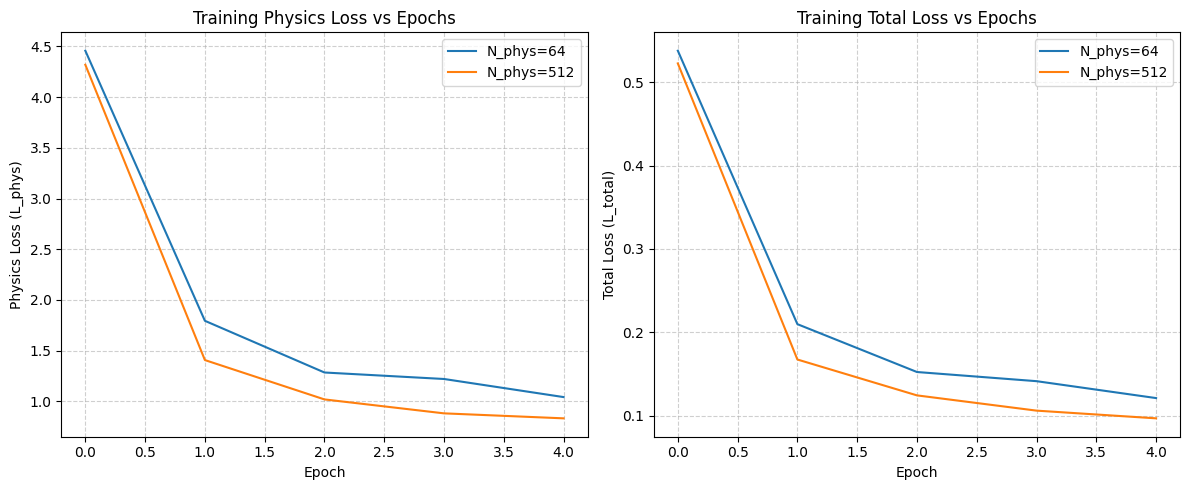

In [31]:
# Plot Physics Loss and Total Loss vs Epochs

plt.figure(figsize=(12, 5))

# Physics Loss over epochs (training)
plt.subplot(1, 2, 1)
for n, res in results.items():
    plt.plot(res["train"]["phys"], label=f"N_phys={n}")
plt.title("Training Physics Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Physics Loss (L_phys)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# Total Loss over epochs (training)
plt.subplot(1, 2, 2)
for n, res in results.items():
    plt.plot(res["train"]["total"], label=f"N_phys={n}")
plt.title("Training Total Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Total Loss (L_total)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [35]:

# ---------------------------------------------------------------------
# Experiment: Effect of Decay Rate on Model Performance
# ---------------------------------------------------------------------

decay_values = [0.0,  0.03, 0.1]   #  decay rates
results_decay = {}

for decay in decay_values:
    print(f"\n🚀 Training with decay_rate = {decay}")
    params = get_hyperparams(num_epochs=50,
                             w_data=1.0,
                             w_phys_init=0.1,
                             decay_rate=decay,
                             N_phys=64,       # keep this fixed for fairness
                             dt=0.01,
                             lr=1e-2)

    # Reinitialize a new model each run
    model_exp = VehicleNN().to(device)
    data_l, phys_l, total_l = train_pinn(model_exp, params, train_loader, device)
    results_decay[decay] = {"data": data_l, "phys": phys_l, "total": total_l}



🚀 Training with decay_rate = 0.0
Epoch [01/50] | Data: 0.122345 | Physics: 4.992992 | Total: 0.621645 | w_phys=0.1000 | N_phys=64
Epoch [02/50] | Data: 0.034020 | Physics: 1.780064 | Total: 0.212026 | w_phys=0.1000 | N_phys=64
Epoch [03/50] | Data: 0.032087 | Physics: 1.272294 | Total: 0.159316 | w_phys=0.1000 | N_phys=64
Epoch [04/50] | Data: 0.031321 | Physics: 1.011498 | Total: 0.132470 | w_phys=0.1000 | N_phys=64
Epoch [05/50] | Data: 0.027466 | Physics: 0.933564 | Total: 0.120823 | w_phys=0.1000 | N_phys=64
Epoch [06/50] | Data: 0.030693 | Physics: 0.913937 | Total: 0.122087 | w_phys=0.1000 | N_phys=64
Epoch [07/50] | Data: 0.032265 | Physics: 0.843947 | Total: 0.116659 | w_phys=0.1000 | N_phys=64
Epoch [08/50] | Data: 0.026587 | Physics: 0.887758 | Total: 0.115363 | w_phys=0.1000 | N_phys=64
Epoch [09/50] | Data: 0.028388 | Physics: 0.761681 | Total: 0.104556 | w_phys=0.1000 | N_phys=64
Epoch [10/50] | Data: 0.029865 | Physics: 0.770423 | Total: 0.106908 | w_phys=0.1000 | N_phys

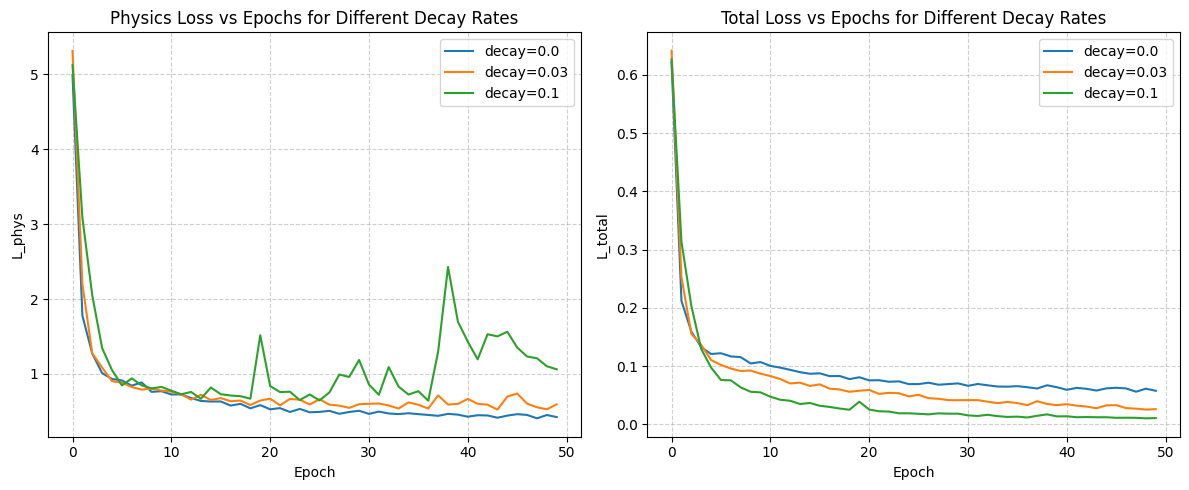

In [36]:
#Decay rate visulaization
plt.figure(figsize=(12,5))

# --- Physics Loss ---
plt.subplot(1,2,1)
for decay, res in results_decay.items():
    plt.plot(res["phys"], label=f"decay={decay}")
plt.title("Physics Loss vs Epochs for Different Decay Rates")
plt.xlabel("Epoch")
plt.ylabel("L_phys")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- Total Loss ---
plt.subplot(1,2,2)
for decay, res in results_decay.items():
    plt.plot(res["total"], label=f"decay={decay}")
plt.title("Total Loss vs Epochs for Different Decay Rates")
plt.xlabel("Epoch")
plt.ylabel("L_total")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [32]:
 # mse erorr and r2 score evaution for Validation data(20%)


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    Y_test_t = torch.tensor(Y_test_scaled, dtype=torch.float32).to(device)

    # NN prediction (scaled output)
    Y_pred_scaled = model(X_test_t)

    #  Convert predictions to real physical units (m/s)
    scale_tensor = torch.tensor(scaler_Y.scale_, dtype=torch.float32, device=device)
    mean_tensor  = torch.tensor(scaler_Y.mean_, dtype=torch.float32, device=device)
    Y_pred_real = (Y_pred_scaled * scale_tensor + mean_tensor).cpu().numpy()


    Y_true_real = scaler_Y.inverse_transform(Y_test_scaled)

# Compute metrics
mse_vx = mean_squared_error(Y_true_real[:,0], Y_pred_real[:,0])
mse_vy = mean_squared_error(Y_true_real[:,1], Y_pred_real[:,1])
r2_vx  = r2_score(Y_true_real[:,0], Y_pred_real[:,0])
r2_vy  = r2_score(Y_true_real[:,1], Y_pred_real[:,1])

print(" Validation Data Evaluation Results:")
print(f"MSE(vx): {mse_vx:.6f} | R²(vx): {r2_vx:.4f}")
print(f"MSE(vy): {mse_vy:.6f} | R²(vy): {r2_vy:.4f}")


 Validation Data Evaluation Results:
MSE(vx): 0.005942 | R²(vx): 1.0000
MSE(vy): 0.000007 | R²(vy): 0.9999


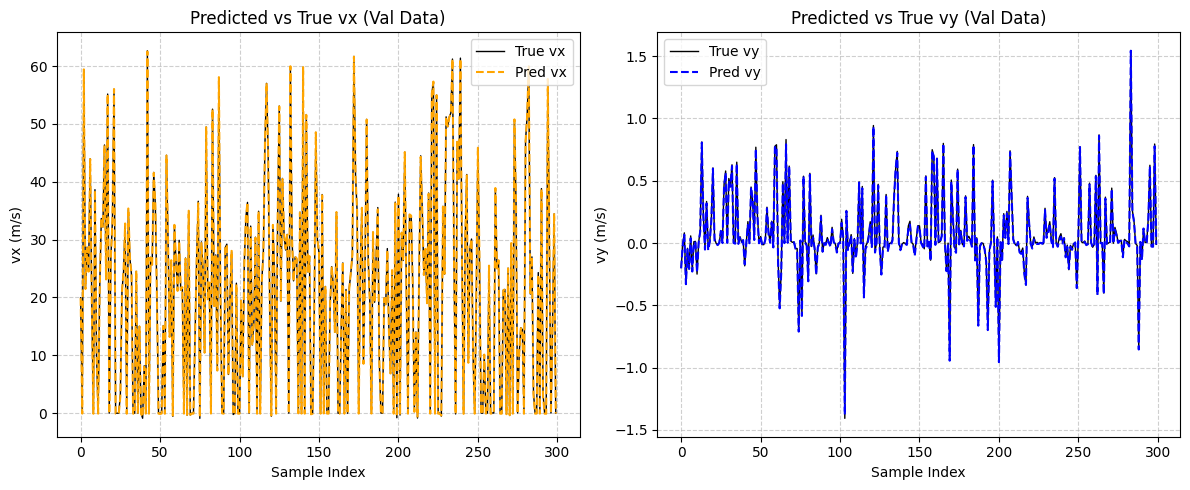

In [33]:

# Prediction vs True Vx,Vy COmparison Plot for Validation data


plt.figure(figsize=(12,5))

#  vx
plt.subplot(1,2,1)
plt.plot(y_true_v[:300,0], label='True vx', color='black', linewidth=1)
plt.plot(y_pred_v[:300,0], '--', label='Pred vx', color='orange')
plt.title("Predicted vs True vx (Val Data)")
plt.xlabel("Sample Index")
plt.ylabel("vx (m/s)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

#  vy 
plt.subplot(1,2,2)
plt.plot(y_true_v[:300,1], label='True vy', color='black', linewidth=1)
plt.plot(y_pred_v[:300,1], '--', label='Pred vy', color='blue')
plt.title("Predicted vs True vy (Val Data)")
plt.xlabel("Sample Index")
plt.ylabel("vy (m/s)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


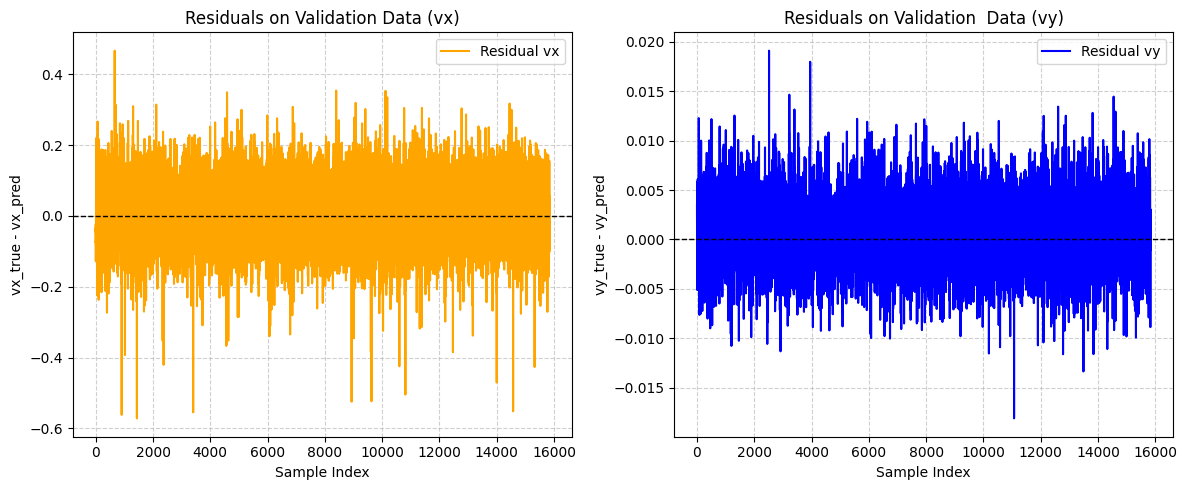

Residual stats (Validation Data):
vx → mean: -0.0125, std: 0.0761, RMSE: 0.0771
vy → mean: 0.0007, std: 0.0026, RMSE: 0.0027


In [34]:
# Residual Plot for validation data

res_vx = Y_true_real[:,0] - Y_pred_real[:,0]
res_vy = Y_true_real[:,1] - Y_pred_real[:,1]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(res_vx, label='Residual vx', color='orange')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Residuals on Validation Data (vx)")
plt.xlabel("Sample Index")
plt.ylabel("vx_true - vx_pred")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1,2,2)
plt.plot(res_vy, label='Residual vy', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Residuals on Validation  Data (vy)")
plt.xlabel("Sample Index")
plt.ylabel("vy_true - vy_pred")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#  Residual stats 
print("Residual stats (Validation Data):")
print(f"vx → mean: {np.mean(res_vx):.4f}, std: {np.std(res_vx):.4f}, RMSE: {np.sqrt(np.mean(res_vx**2)):.4f}")
print(f"vy → mean: {np.mean(res_vy):.4f}, std: {np.std(res_vy):.4f}, RMSE: {np.sqrt(np.mean(res_vy**2)):.4f}")


# Hyper Parameter Tuning Using Raytune



In [24]:

## Import ray and MLFLOW lib

from ray import tune
from ray.tune.search.bayesopt import BayesOptSearch
from ray.tune.schedulers import ASHAScheduler
from ray.air.integrations.mlflow import MLflowLoggerCallback
from ray.air import session
import mlflow, ray, numpy as np
from ray.tune.search.hyperopt import HyperOptSearch
from ray.tune.search.optuna import OptunaSearch
from ray.tune.search.basic_variant import BasicVariantGenerator

## Initialize Ray

In [41]:
# Initialize Ray

ray.shutdown()
ray.init(ignore_reinit_error=True, log_to_driver=False)

2025-12-06 11:35:08,197	INFO worker.py:2012 -- Started a local Ray instance.
c:\Users\msbka\anaconda3\envs\oopEnv\lib\site-packages\ray\_private\worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Python version:,3.10.16
Ray version:,2.51.1


In [42]:
# MLflow tracking director and new Experiment for Hyperopt algorithm

mlflow.set_tracking_uri("http://127.0.0.1:5000")        
mlflow.set_experiment("PINN_Tuning_HyperOpt_V2")

<Experiment: artifact_location='file:///C:/Users/msbka/mlruns/8', creation_time=1764889247208, experiment_id='8', last_update_time=1764889247208, lifecycle_stage='active', name='PINN_Tuning_HyperOpt_V2', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [ ]:
# MLflow tracking director and new Experiment for Optuna algorithm

mlflow.set_tracking_uri("http://127.0.0.1:5000")        
mlflow.set_experiment("PINN_Tuning_Optuna_ASHA")

<Experiment: artifact_location='file:///C:/Users/msbka/mlruns/3', creation_time=1763634981953, experiment_id='3', last_update_time=1763634981953, lifecycle_stage='active', name='PINN_Tuning_Optuna_ASHA', tags={}>

In [ ]:
# MLflow tracking director and new Experiment for Random Search algorithm

mlflow.set_tracking_uri("http://127.0.0.1:5000")        
mlflow.set_experiment("PINN_Tuning_Random_ASHA")

<Experiment: artifact_location='file:///C:/Users/msbka/mlruns/5', creation_time=1763675647245, experiment_id='5', last_update_time=1763675647245, lifecycle_stage='active', name='PINN_Tuning_Random_ASHA', tags={'mlflow.experimentKind': 'custom_model_development'}>

## Hyperparameter Search space and Algorithm Intialization (RayTune)

In [ ]:

# ---------------------------------------------------------------------
# Hyperparameter search space
# ---------------------------------------------------------------------


search_space = {
    "lr":          tune.loguniform(1e-3, 5e-3),
    "w_phys_init": tune.uniform(0.1, 0.5),
    "decay_rate":  tune.uniform(0.03, 0.12),
    "N_phys":      tune.choice(["128","256","384","512"]), #3000-5000
    "hidden_dim": tune.choice(["64","128","256"])
    
}


# ---------------------------------------------------------------------
# Common scheduler (ASHA)
# ---------------------------------------------------------------------
asha_scheduler = ASHAScheduler(
    max_t=50,
    grace_period=10,
    reduction_factor=2,
)



# ---------------------------------------------------------------------
# 1) Bayesian Optimization (BayesOpt + ASHA + MLflow)
# ---------------------------------------------------------------------


bayes = BayesOptSearch(metric="val_total", mode="min", random_search_steps=6)
mlf_cb = MLflowLoggerCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    experiment_name="PINN_Tuning_BayesOpt_ASHA"
)


# ---------------------------------------------------------------------
# 2) HyperOpt (TPE) + ASHA + MLflow
# ---------------------------------------------------------------------

hyperopt=HyperOptSearch(metric="val_total",mode="min")
mlf_2 = MLflowLoggerCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    experiment_name="PINN_Tuning_HyperOpt_V2"
)


# ---------------------------------------------------------------------
# 3) Optuna + ASHA + MLflow
# ---------------------------------------------------------------------

Optuna=OptunaSearch(metric="val_total",mode="min")
mlf_3 = MLflowLoggerCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    experiment_name="PINN_Tuning_Optuna_ASHA"
)

# ---------------------------------------------------------------------
# 3) RandomSearch + ASHA + MLflow
# ---------------------------------------------------------------------
random_search = BasicVariantGenerator()
mlf_r = MLflowLoggerCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    experiment_name="PINN_Tuning_Random_ASHA"
)



## Model Training and MLflow Tracking

Ray Tune trainable for the Physics-Informed Neural Network (PINN).

Workflow:
1. Build a hyperparameter dictionary from Ray's `config`.
2. Initialize a fresh VehicleNN model for this trial.
3. Train on Car A data (train_loader) for `num_epochs`.
         - Compute data loss (MSE) on batches.
         - Compute physics loss using random collocation points.
         - Combine them with a decayed physics weight w_phys.
4. After training, evaluate on Car B (test_loader_carB) using
         `evaluate_pinn_on_test`.
5. Report final metrics to Ray Tune (and MLflow via callback).
6. Log the trained model to MLflow as an artifact.

Ray / MLflow:
- Hyperparameters are taken from `config` and can be logged by
    MLflowLoggerCallback automatically.
- Metrics are reported via `session.report(metrics)`.
- The trained model is stored using `mlflow.pytorch.log_model`.



In [45]:
def trainable_pinn_ray(config):
   
    # ------------------------------------------------------------------
    # 1. Construct hyperparameter dictionary from Ray's config
    # ------------------------------------------------------------------

    params = get_hyperparams(
        num_epochs   = 50,                             # fixed in this experiment
        w_data       = 1.0,
        w_phys_init  = float(config["w_phys_init"]),
        decay_rate   = float(config["decay_rate"]),
        N_phys       = int(config["N_phys"]),
        dt           = 0.01,
        lr           = float(config["lr"])
    )

     # ------------------------------------------------------------------
    # 2. Initialize a new model for this Ray trial
    # ------------------------------------------------------------------

    model_trial = VehicleNN(hidden_dim=int(config["hidden_dim"])).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])
    criterion = RMSELoss()



    # ------------------------------------------------------------------
    # 3. Training loop on Car A (train_loader)
    # ------------------------------------------------------------------

    for epoch in range(params["num_epochs"]):
        model.train()
        total_loss_data, total_loss_phys, total_loss = 0.0, 0.0, 0.0

        # Exponential decay for physics weight
        w_phys = params["w_phys_init"] * math.exp(-params["decay_rate"] * epoch)

        for Xb, Yb in train_loader:   # <--- Car A
            Xb, Yb = Xb.to(device), Yb.to(device)
            optimizer.zero_grad()

            # NN data loss 
            Y_pred = model(Xb)
            loss_data = criterion(Y_pred, Yb)

            # Physics loss (random points)
            loss_phys = compute_physics_loss_torch(model, params["N_phys"], params["dt"], device)

            loss_total = params["w_data"] * loss_data + w_phys * loss_phys

            loss_total.backward()
            optimizer.step()

            total_loss_data += loss_data.item()
            total_loss_phys += loss_phys.item()
            total_loss += loss_total.item()

        # Average over batches
        avg_data_loss = total_loss_data / len(train_loader)
        avg_phys_loss = total_loss_phys / len(train_loader)
        avg_total_loss = total_loss / len(train_loader)

        # ------------------------------------------------------------------
        # 4. Evaluate on Car a Val data after this epoch
        # ------------------------------------------------------------------

        model.eval()
        with torch.no_grad():
            data_loss_b, phys_loss_b, total_loss_b,y_true_v,y_pred_v = evaluate_pinn_on_test(
                model, Val_Data_loader, device, dt=params["dt"], N_phys=params["N_phys"],w_data=params["w_data"],w_phys_init=params["w_phys_init"],decay_rate=params["decay_rate"],
        epoch_idx=params["num_epochs"]-1
            )

        # ------------------------------------------------------------------
        # 5. Report metrics to Ray / MLflow
        # ------------------------------------------------------------------

    metrics = {
            "epoch": epoch + 1,
            "train_data": avg_data_loss,
            "train_phys": avg_phys_loss,
            "train_total": avg_total_loss,
            "val_data": data_loss_b,        
            "val_phys": phys_loss_b,        
            "val_total": total_loss_b       
    }


    # This sends metrics to Ray Tune. The MLflowLoggerCallback records
    # them automatically in MLflow as a "trace" per trial.
    session.report(metrics)

    # ----------------------------------------------------------------------
    # 6. Log the final trained model for this trial as an MLflow artifact
    # ----------------------------------------------------------------------
   
    # log params, metrics, model, artifacts
        
    mlflow.log_params({
        "lr": params["lr"],
        "N_phys": params["N_phys"],
        "decay_rate": params["decay_rate"],
        "w_data": params["w_data"],
        "w_phys_init": params["w_phys_init"]
    })

    for epoch in range(num_epochs):
        ...
        mlflow.log_metric("train_total_loss", avg_total_loss, step=epoch)
        mlflow.log_metric("train_data_loss", avg_data_loss, step=epoch)
        mlflow.log_metric("train_phys_loss", avg_phys_loss, step=epoch)

    
    mlflow.pytorch.log_model(model_trial, artifact_path="model")



In [ ]:
# # Hyperparameter Optimization using Ray Tune with BaysianOpt + ASHA + MLflow


# ## commented this because of bayesian not taking catagorical Data ( Tune.choice or tune.randint) error. and using Other optimizers.


# tuner = tune.Tuner(
# tune.with_resources(trainable_pinn_ray, {"cpu": 2, "gpu": 0}),
# tune_config=tune.TuneConfig(
#     metric="val_total",
#     mode="min",
#     num_samples=2,
#     search_alg=bayes,
#     scheduler=asha_scheduler
# ),
# run_config=ray.air.RunConfig(
#     name="PINN_Tuning_Bayesian_ASHA",
#     callbacks=[mlf_cb]
# ),
# param_space=search_space
# )

# results = tuner.fit()

# best = results.get_best_result(metric="val_total", mode="min")
# print("\n Best configuration found:")
# print(best.config)
# print(f"Best Total Loss: {best.metrics['val_total']:.6f}")


In [ ]:

# Hyperparameter Optimization using Ray Tune with HyperOpt + ASHA + MLflow

tuner = tune.Tuner(
    tune.with_resources(trainable_pinn_ray, {"cpu": 2, "gpu": 0}),
    tune_config=tune.TuneConfig(
        metric="val_total",
        mode="min",
        num_samples=300,
        search_alg=hyperopt,
        scheduler=asha_scheduler
    ),
    run_config=ray.air.RunConfig(
        name="PINN_Tuning_HyperOpt_V2",
        callbacks=[mlf_2]
    ),
    param_space=search_space
)

results = tuner.fit()


# Retrieve best result
best = results.get_best_result(metric="val_total", mode="min")
print("\n Best configuration found from hyperopt:")
print(best.config)
print(f"Best Total Loss: {best.metrics['val_total']:.6f}")

In [ ]:

# Hyperparameter Optimization using Ray Tune with Optuna + ASHA + MLflow


tuner = tune.Tuner(
    tune.with_resources(trainable_pinn_ray, {"cpu": 2, "gpu": 0}),
    tune_config=tune.TuneConfig(
        metric="val_total",
        mode="min",
        num_samples=300,
        search_alg=Optuna,
        scheduler=asha_scheduler
    ),
    run_config=ray.air.RunConfig(
        name="PINN_Tuning_Optuna_ASHA",
        callbacks=[mlf_3]
    ),
    param_space=search_space
)

results = tuner.fit()

best = results.get_best_result(metric="val_total", mode="min")
print("\n Best configuration found from optuna:")
print(best.config)
print(f"Best Total Loss: {best.metrics['val_total']:.6f}")

In [ ]:

# Hyperparameter Optimization using Ray Tune with Optuna + ASHA + MLflow


tuner = tune.Tuner(
    tune.with_resources(trainable_pinn_ray, {"cpu": 2, "gpu": 0}),
    tune_config=tune.TuneConfig(
        metric="val_total",
        mode="min",
        num_samples=300,
        search_alg=random_search,
        scheduler=asha_scheduler
    ),
    run_config=ray.air.RunConfig(
        name="PINN_Tuning_Random_ASHA",
        callbacks=[mlf_r]
    ),
    param_space=search_space
)

results = tuner.fit()

best = results.get_best_result(metric="val_total", mode="min")
print("\n Best configuration found from optuna:")
print(best.config)
print(f"Best Total Loss: {best.metrics['val_total']:.6f}")

# SHapley Additive exPlanations.

How much that feature's value contributed to the difference between the actual prediction and the average prediction of the dataset.

Feature Importance Plot
Provides a clear, aggregated rank of feature influence, without showing the direction (positive/negative) of the impact.

SHAP Summary Plot

Indicates the feature's contribution for a single data point. The grey vertical line is the base value (average model output). Dots to the right increase the model output (e.g., higher loss); dots to the left decrease the output (e.g., lower loss).

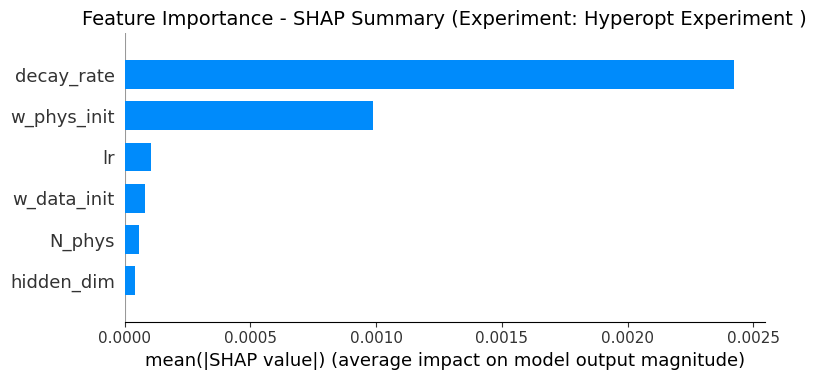

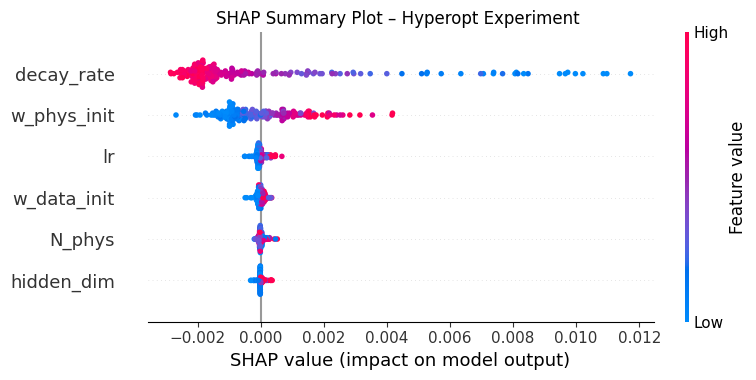

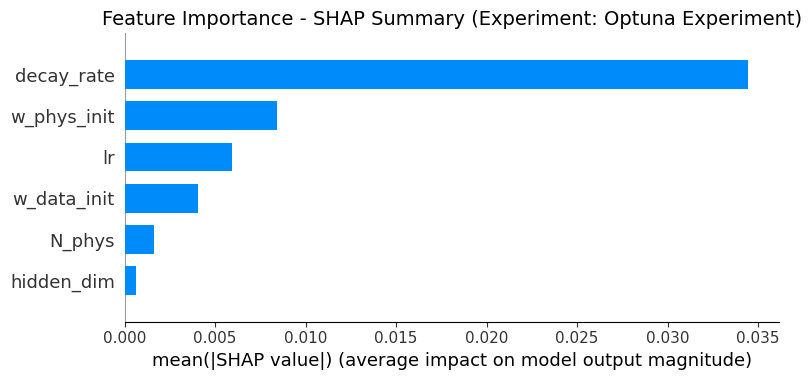

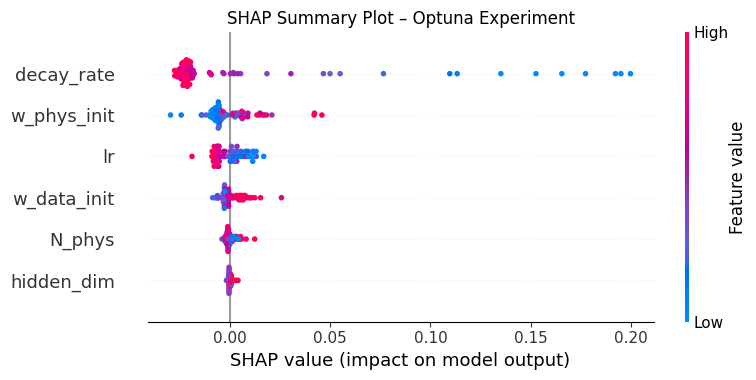

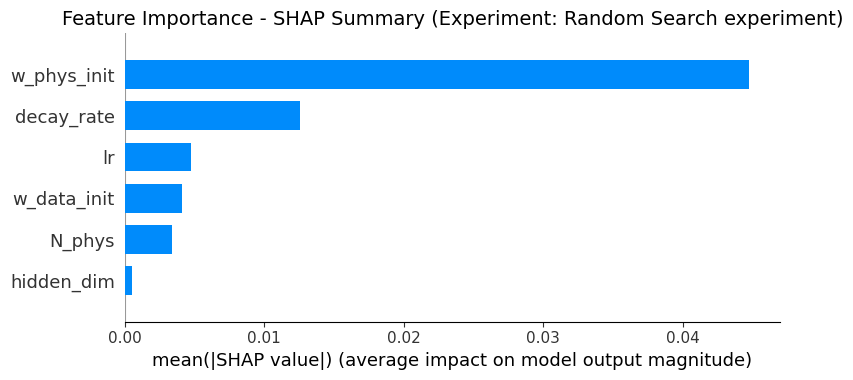

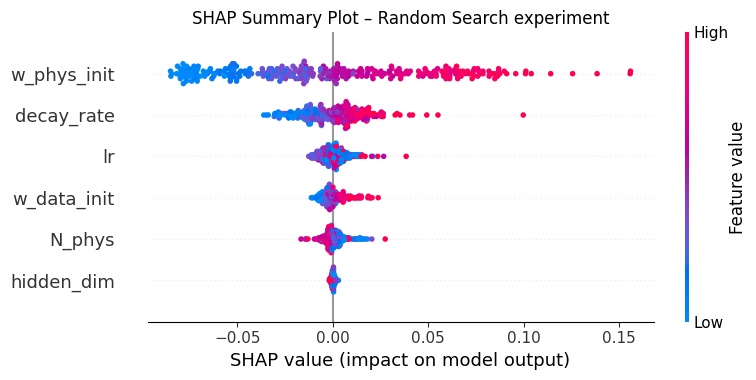

In [ ]:
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# ============= Step 1: Load your 3 experiment datasets =============
# Load your experiment results
df_exp1 = pd.read_csv(r"C:\Users\msbka\PINNS\Hypertuning_results\Hyperopt_result_Used_Validationdata.csv")
df_exp2 = pd.read_csv(r"C:\Users\msbka\PINNS\Hypertuning_results\OptunaResults.csv")
df_exp3 = pd.read_csv(r"C:\Users\msbka\PINNS\Hypertuning_results\RandomSearchResults_Used_Validationdata.csv")

datasets = [
    ("Experiment 1", df_exp1),
    ("Experiment 2", df_exp2),
    ("Experiment 3", df_exp3)
]

# ============= Step 2: Define reusable cleaning + SHAP function =============
def shap_plot_for_experiment(df, exp_name):
    """
    Generate SHAP feature importance visualization for a given experiment.
    """
    # Select only hyperparameter columns
    config_cols = [c for c in df.columns if c.startswith("config/")]
    
    # Prepare features and target
    X = df[config_cols].copy()
    X.columns = [c.replace("config/", "") for c in config_cols]
    X = X.apply(pd.to_numeric, errors="coerce")

    y = pd.to_numeric(df["val_total"], errors="coerce")

    # Drop NaN or infinite values
    mask = (~X.isna().any(axis=1)) & (~y.isna())
    X = X[mask]
    y = y[mask]

    if len(X) < 5:
        print(f"⚠ Not enough valid samples for SHAP in {exp_name} (only {len(X)} rows)")
        return

    # Train surrogate model
    model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    model.fit(X, y)

    # Compute SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    # 🔹 Plot Setup: Larger, properly aligned, titled
    plt.figure(figsize=(10, 5))
    plt.title(f"Feature Importance - SHAP Summary (Experiment: {exp_name})", fontsize=14)
    shap.summary_plot(shap_values, X, plot_type="bar", show=False)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: SHAP Beeswarm Summary Plot ---
    plt.figure(figsize=(8, 4))
    shap.summary_plot(shap_values, X, show=False)
    plt.title(f"SHAP Summary Plot – {exp_name}")
    plt.tight_layout()
    plt.show()


# ============= Step 5: Run for all datasets =============
# Run SHAP plots for each experiment

shap_plot_for_experiment(df_exp1, "Hyperopt Experiment ")
shap_plot_for_experiment(df_exp2, "Optuna Experiment")
shap_plot_for_experiment(df_exp3, "Random Search experiment")


# Validating Final loss with Test data Using Best Parameter

In [24]:
def as_float(value):
    return value[0] if isinstance(value, list) else value


In [ ]:

## COmmented remaining two optimizer results because we used test data for hyperparameter tuning . 
# Retuned tuning with hyperopt parameter using validatation data

import pandas as pd
import torch

csv_files = {
    #"Random Search": (r"C:\Users\msbka\PINNS\Hypertuning_results\RandomSearchResults_Used_Validationdata.csv"),
    "HyperOpt": (r"C:\Users\msbka\Downloads\runs (3).csv"),
    #"Optuna":  (r"C:\Users\msbka\Downloads\OptunaResults.csv")
}

results_summary = {}

def extract_best_params(df):
    best_row = df.loc[df["val_total"].idxmin()]
    params = {
        "num_epochs": 100,
        "lr": float(best_row["config/lr"]),
        "hidden_dim": int(best_row["config/hidden_dim"]),
        "N_phys": int(best_row["config/N_phys"]),
        "w_data": 1.0,
        "w_phys_init": float(best_row["config/w_phys_init"]),
        "decay_rate":float(best_row["config/decay_rate"] ),
        "dt": 0.01
    }
    return params

for exp_name, file in csv_files.items():

    print(f"\n Processing {exp_name} results...")
    df = pd.read_csv(file)

    best_params = extract_best_params(df)
    print("Best Parameters:", best_params)

# Initialize model with best hidden_dim
    model = VehicleNN(hidden_dim=best_params["hidden_dim"]).to(device)

    data_l, phys_l, total_l = train_pinn(
    model,
    best_params,
    train_loader,
    device
)   
    
    
    
# ========================================
    # SAVE THE TRAINED MODEL
    # ========================================
    model_filename = f"best_model_{exp_name}.pth"
    torch.save(model.state_dict(), model_filename)
    print(f" Model saved: {model_filename}")
    
    

   


 Processing HyperOpt results...
Best Parameters: {'num_epochs': 100, 'lr': 0.0004411, 'hidden_dim': 143, 'N_phys': 2008, 'w_data': 1.0, 'w_phys_init': 0.09, 'decay_rate': 0.015, 'dt': 0.01}
Epoch [01/100] | Data: 0.283493 | Physics: 8.629438 | Total: 1.060142 | w_phys=0.0900 | N_phys=2008
Epoch [02/100] | Data: 0.174768 | Physics: 7.165267 | Total: 0.810041 | w_phys=0.0887 | N_phys=2008
Epoch [03/100] | Data: 0.174745 | Physics: 7.164897 | Total: 0.800528 | w_phys=0.0873 | N_phys=2008
Epoch [04/100] | Data: 0.174781 | Physics: 7.168157 | Total: 0.791528 | w_phys=0.0860 | N_phys=2008
Epoch [05/100] | Data: 0.174746 | Physics: 7.165436 | Total: 0.782080 | w_phys=0.0848 | N_phys=2008
Epoch [06/100] | Data: 0.174708 | Physics: 7.164312 | Total: 0.772906 | w_phys=0.0835 | N_phys=2008
Epoch [07/100] | Data: 0.174744 | Physics: 7.167140 | Total: 0.764269 | w_phys=0.0823 | N_phys=2008
Epoch [08/100] | Data: 0.174769 | Physics: 7.168025 | Total: 0.755589 | w_phys=0.0810 | N_phys=2008
Epoch [09

In [145]:
 # Evaluate on test data
data_test, phys_test, total_test ,Y_true_real, Y_pred_real = evaluate_pinn_on_test(
        model,
        test_loader_carB,
        device,
        dt=best_params["dt"],
        N_phys=best_params["N_phys"],
        w_data=1.0,
        w_phys_init=best_params["w_phys_init"],
        decay_rate=best_params["decay_rate"],
        epoch_idx=best_params["num_epochs"] - 1
    )

    # Store results
results_summary[exp_name] = {
        
        "test_loss": total_test,
        "data_loss": data_test,
        "phys_loss": phys_test,
        "params": best_params,
        "Y_true": Y_true_real,
        "Y_pred": Y_pred_real
    }

print("\n=====  Final Comparison Across Optimizers =====")
for exp, res in results_summary.items():
    print(f"\n🔹 {exp}")
    print(f"  Best Params: {res['params']}")
    print(f"  Test Total Loss:  {as_float(res['test_loss']):.6f}")
    print(f"  Data Loss:        {as_float(res['data_loss']):.6f}")
    print(f"  Physics Loss:     {as_float(res['phys_loss']):.6f}")


 Evaluation on :
   NN (data) loss:   0.067126
   Physics loss:     7.055720
   Total loss:       0.702141   (w_data=1.0, w_phys=0.09)

=====  Final Comparison Across Optimizers =====

🔹 HyperOpt
  Best Params: {'num_epochs': 100, 'lr': 0.0004411, 'hidden_dim': 143, 'N_phys': 2008, 'w_data': 1.0, 'w_phys_init': 0.09, 'decay_rate': 0.015, 'dt': 0.01}
  Test Total Loss:  0.702141
  Data Loss:        0.067126
  Physics Loss:     7.055720


In [33]:
# Final: Print clean results for each experiment
print("\n" + "="*80)
print(" FINAL EVALUATION SUMMARY")
print("="*80)

for exp, res in results_summary.items():  # make sure all_results is your final results dict
    print(f"\n🔹 Experiment: {exp}")

    print(" Best Parameters:")
    for k, v in res['params'].items():
        print(f"   {k}: {v}")

    print("\nEvaluation Metrics:")
    print(f"   Test Total Loss:  {as_float(res['test_loss']):.6f}")
    print(f"   Data Loss:        {as_float(res['data_loss']):.6f}")
    print(f"   Physics Loss:     {as_float(res['phys_loss']):.6f}")

    if 'rmse_vx' in res:
        print(f"   RMSE vx:          {res['rmse_vx']:.6f}")
        print(f"   RMSE vy:          {res['rmse_vy']:.6f}")

print("\n" + "="*80)
print("✔ End of Evaluation Summary")
print("="*80)



 FINAL EVALUATION SUMMARY

🔹 Experiment: HyperOpt
 Best Parameters:
   num_epochs: 100
   lr: 0.002138995402828
   hidden_dim: 128
   N_phys: 256
   w_data: 1.0
   w_phys_init: 0.1061215011164736
   decay_rate: 0.0437547740663414
   dt: 0.01

Evaluation Metrics:
   Test Total Loss:  0.214972
   Data Loss:        0.054018
   Physics Loss:     1.516696

✔ End of Evaluation Summary


In [ ]:
import pandas as pd
import os

output_folder = r"C:\Users\msbka\Documents\PINN_Results"   # Change path if needed
os.makedirs(output_folder, exist_ok=True)  # Create folder if not exists

for exp, res in results_summary.items():
    print(f"\n🔹 {exp} – Saving Complete Actual vs Predicted values to CSV...")

    # Extract arrays
    Y_true = res["Y_true"]
    Y_pred = res["Y_pred"]

    # Create Full DataFrame
    df_full = pd.DataFrame({
        "True_Vx": Y_true[:, 0],
        "Pred_Vx": Y_pred[:, 0],
        "True_Vy": Y_true[:, 1],
        "Pred_Vy": Y_pred[:, 1]
    })

    # Save CSV using experiment name
    file_path = os.path.join(output_folder, f"{exp}_Actual_vs_Predicted.csv")
    df_full.to_csv(file_path, index=False, encoding='utf-8-sig')

    print(f"✔ Saved: {file_path}")
    print(df_full.head())  # Show first rows for confirmation



🔹 HyperOpt – Saving Complete Actual vs Predicted values to CSV...
✔ Saved: C:\Users\msbka\Documents\PINN_Results\HyperOpt_Actual_vs_Predicted.csv
        True_Vx   Pred_Vx       True_Vy   Pred_Vy
0  3.894135e-08  0.000858  6.829287e-10 -0.001148
1  3.894135e-08  0.024525  6.829287e-10 -0.001456
2  3.894135e-08 -0.096003  6.829287e-10  0.002347
3  3.894135e-08  0.022783  6.829287e-10 -0.001565
4  3.894135e-08 -0.006262  6.829287e-10 -0.001176


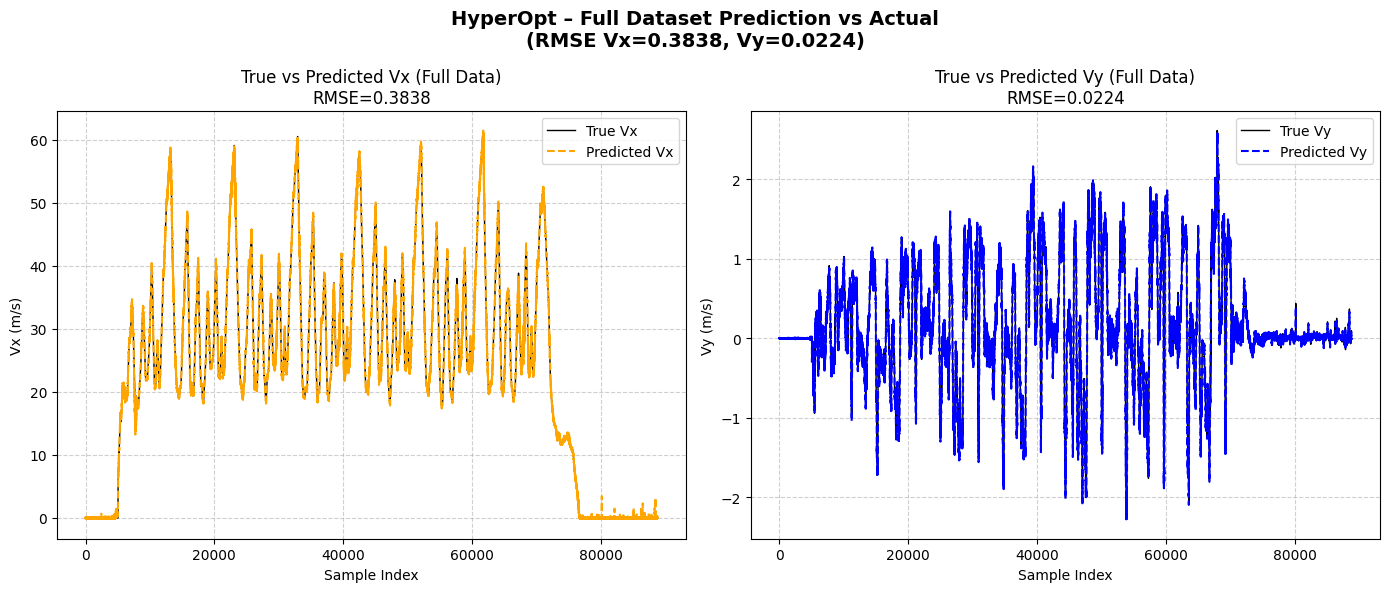

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

for exp, res in results_summary.items():
    Y_true = res["Y_true"]
    Y_pred = res["Y_pred"]

    # === Calculate RMSE ===
    rmse_vx = np.sqrt(mean_squared_error(Y_true[:, 0], Y_pred[:, 0]))
    rmse_vy = np.sqrt(mean_squared_error(Y_true[:, 1], Y_pred[:, 1]))

    # === Plot True vs Predicted for full dataset ===
    plt.figure(figsize=(14,6))
    plt.suptitle(f"{exp} – Full Dataset Prediction vs Actual\n(RMSE Vx={rmse_vx:.4f}, Vy={rmse_vy:.4f})",
                 fontsize=14, fontweight='bold')

    # ---- Vx Plot ----
    plt.subplot(1,2,1)
    plt.plot(Y_true[:,0], label='True Vx', color='black', linewidth=1)
    plt.plot(Y_pred[:,0], '--', label='Predicted Vx', color='orange')
    plt.title(f"True vs Predicted Vx (Full Data)\nRMSE={rmse_vx:.4f}")
    plt.xlabel("Sample Index")
    plt.ylabel("Vx (m/s)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # ---- Vy Plot ----
    plt.subplot(1,2,2)
    plt.plot(Y_true[:,1], label='True Vy', color='black', linewidth=1)
    plt.plot(Y_pred[:,1], '--', label='Predicted Vy', color='blue')
    plt.title(f"True vs Predicted Vy (Full Data)\nRMSE={rmse_vy:.4f}")
    plt.xlabel("Sample Index")
    plt.ylabel("Vy (m/s)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()


# STATE ESTIMATION

Vy- Unmeaseurable

## Self loop

In [47]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

#==============================================================================
# SELF-LOOP PINN - PREDICTS BOTH vx(k+1) AND vy(k+1)
#==============================================================================

class SelfLoop_PINN(nn.Module):
    """
    Self-Loop PINN that predicts COMPLETE next state [vx(k+1), vy(k+1)]
    
    Inputs:
    - x_k = [vx(k), vy(k)]: current state (vy estimated from previous step)
    - u_k = [r(k), ax(k), ay(k)]: current control/measurements
    
    Output:
    - x_{k+1} = [vx(k+1), vy(k+1)]: complete next state
    
    Key: At test time, vy(k) comes from previous prediction (self-loop)
    """
    def __init__(self, input_dim=4, hidden_dims=[64, 64, 32], output_dim=2):
        super(SelfLoop_PINN, self).__init__()
        
        # input_dim = 2 (state) + 3 (control) = 5
        # output_dim = 2 (vx_next, vy_next)
        
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.Tanh())
            prev_dim = hidden_dim
        
        # Output layer: predicts [vx(k+1), vy(k+1)]
        layers.append(nn.Linear(prev_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, vx_k, r_k, ax_k, ay_k):
        """
        Predict complete next state
        
        Args:
            vx_k: longitudinal velocity at k (batch, 1)
            vy_k: lateral velocity at k (batch, 1) - ESTIMATED in test!
            r_k: yaw rate at k (batch, 1)
            ax_k: longitudinal acceleration at k (batch, 1)
            ay_k: lateral acceleration at k (batch, 1)
        
        Returns:
            next_state: [vx(k+1), vy(k+1)] (batch, 2)
        """
        # Concatenate: x_k = [vx, vy], u_k = [r, ax, ay]
        x = torch.cat([vx_k, r_k, ax_k, ay_k], dim=1)
        
        # Predict next state
        next_state = self.network(x)
        
        return next_state  # [vx_next, vy_next]



In [48]:
class SelfLoop_PINN_Trainer:
    """
    Trainer for Self-Loop PINN (NO true vy(k) is used)

    X = [vx(k), r(k), ax(k), ay(k)]
    Y = [vx(k+1), vy(k+1)]
    """
    def __init__(self, selfloop_model, device='cpu'):
        self.model = selfloop_model.to(device)
        self.device = device

    # ---------- DATA LOSS ----------
    def compute_data_loss(self, vx_pred, vy_pred, vx_true, vy_true):
        loss_vx = torch.mean((vx_pred - vx_true)**2)
        loss_vy = torch.mean((vy_pred - vy_true)**2)
        return torch.sqrt(loss_vx + loss_vy)   # RMSE

    # ---------- PHYSICS LOSS ----------
    def compute_physics_loss(self, vx_k, r_k, ax_k, ay_k,
                             vx_next_pred, vy_next_pred, dt=0.01):
        """
        Simple lateral acceleration consistency:
        ay ≈ r * vx
        """
        ay_model = r_k * vx_k
        lat_loss = torch.mean((ay_model - ay_k)**2)
        return lat_loss

    # ---------- TRAIN LOOP ----------
    def train_selfloop(self, train_loader, val_loader=None,
                       epochs=50, lr=1e-3,
                       w_data=1.0, w_physics=0.1,
                       verbose=True):

        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=10
        )

        history = {
            "train_loss": [],
            "train_data_loss": [],
            "train_physics_loss": [],
            "val_loss": []
        }

        best_val_loss = float('inf')

        for epoch in range(epochs):
            self.model.train()
            total_loss = 0.0
            total_data = 0.0
            total_phys = 0.0

            for X, Y in train_loader:
                X = X.to(self.device)
                Y = Y.to(self.device)

                # X = [vx, r, ax, ay]
                vx_k = X[:, 0:1]
                r_k  = X[:, 1:2]
                ax_k = X[:, 2:3]
                ay_k = X[:, 3:4]

                vx_next_true = Y[:, 0:1]
                vy_next_true = Y[:, 1:2]

                optimizer.zero_grad()

                pred_next = self.model(vx_k, r_k, ax_k, ay_k)
                vx_next_pred = pred_next[:, 0:1]
                vy_next_pred = pred_next[:, 1:2]

                loss_data = self.compute_data_loss(
                    vx_next_pred, vy_next_pred,
                    vx_next_true, vy_next_true
                )

                loss_phys = self.compute_physics_loss(
                    vx_k, r_k, ax_k, ay_k,
                    vx_next_pred, vy_next_pred
                )

                loss = w_data * loss_data + w_physics * loss_phys
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()

                total_loss += loss.item()
                total_data += loss_data.item()
                total_phys += loss_phys.item()

            n_batches = len(train_loader)
            history["train_loss"].append(total_loss / n_batches)
            history["train_data_loss"].append(total_data / n_batches)
            history["train_physics_loss"].append(total_phys / n_batches)

            # ---------- VALIDATION ----------
            if val_loader is not None:
                val_loss = self.validate(val_loader, w_data, w_physics)
                history["val_loss"].append(val_loss)
                scheduler.step(val_loss)

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    torch.save(self.model.state_dict(), "best_selfloop_pinn.pth")
                    if verbose:
                        print(f"  → Best model saved (Val Loss: {val_loss:.6f})")
            else:
                val_loss = None

            if verbose and (epoch + 1) % 10 == 0:
                if val_loader is not None:
                    print(
                        f"Epoch {epoch+1}/{epochs} | "
                        f"Train: {history['train_loss'][-1]:.6f} | "
                        f"Data: {history['train_data_loss'][-1]:.6f} | "
                        f"Phys: {history['train_physics_loss'][-1]:.6f} | "
                        f"Val: {val_loss:.6f}"
                    )
                else:
                    print(
                        f"Epoch {epoch+1}/{epochs} | "
                        f"Train: {history['train_loss'][-1]:.6f} | "
                        f"Data: {history['train_data_loss'][-1]:.6f} | "
                        f"Phys: {history['train_physics_loss'][-1]:.6f}"
                    )

        return history

    # ---------- VALIDATE ----------
    def validate(self, val_loader, w_data, w_physics):
        self.model.eval()
        total = 0.0

        with torch.no_grad():
            for X, Y in val_loader:
                X = X.to(self.device)
                Y = Y.to(self.device)

                vx_k = X[:, 0:1]
                r_k  = X[:, 1:2]
                ax_k = X[:, 2:3]
                ay_k = X[:, 3:4]

                vx_next_true = Y[:, 0:1]
                vy_next_true = Y[:, 1:2]

                pred = self.model(vx_k, r_k, ax_k, ay_k)
                vx_next_pred = pred[:, 0:1]
                vy_next_pred = pred[:, 1:2]

                data_loss = self.compute_data_loss(
                    vx_next_pred, vy_next_pred,
                    vx_next_true, vy_next_true
                )

                phys_loss = self.compute_physics_loss(
                    vx_k, r_k, ax_k, ay_k,
                    vx_next_pred, vy_next_pred
                )

                total += (w_data * data_loss + w_physics * phys_loss).item()

        return total / len(val_loader)


In [ ]:

#==============================================================================
# EXTENSION RNN - REFINES ONLY vy(k+1)
#==============================================================================

class ExtensionNetwork_RNN(nn.Module):
    """
    Extension Network that refines ONLY vy(k+1)
    
    Inputs:
    - v_y(k+1): from Self-Loop PINN
    - v_x(k+1): from Self-Loop PINN
    - u_{k+1} = [r(k+1), ax(k+1), ay(k+1)]: new measurements
    
    Output:
    - v_y(k+1) refined: improved lateral velocity only
    """
    def __init__(self, input_dim=5, hidden_dim=32, num_layers=2, output_dim=1):
        super(ExtensionNetwork_RNN, self).__init__()
        
        # input_dim = vy(k+1) + vx(k+1) + r(k+1) + ax(k+1) + ay(k+1) = 5
        
        self.rnn = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, vy_pinn, vx_pinn, r_next, ax_next, ay_next, hidden=None):
        """
        Refine vy(k+1) prediction
        
        Args:
            vy_pinn: vy(k+1) from Self-Loop PINN (batch, 1)
            vx_pinn: vx(k+1) from Self-Loop PINN (batch, 1)
            r_next: r(k+1) measurement (batch, 1)
            ax_next: ax(k+1) measurement (batch, 1)
            ay_next: ay(k+1) measurement (batch, 1)
            hidden: RNN hidden state
        
        Returns:
            vy_refined: refined vy(k+1) (batch, 1)
            hidden: updated hidden state
        """
        # Concatenate all inputs
        x = torch.cat([vy_pinn, vx_pinn, r_next, ax_next, ay_next], dim=1)
        
        # Add sequence dimension for RNN
        x = x.unsqueeze(1)  # (batch, seq_len=1, features)
        
        # RNN forward
        if hidden is not None:
            out, hidden = self.rnn(x, hidden)
        else:
            out, hidden = self.rnn(x)
        
        # Remove sequence dimension
        out = out.squeeze(1)
        
        # Predict refined vy
        vy_refined = self.fc(out)
        
        return vy_refined, hidden



In [49]:

#==============================================================================
# COMPLETE SYSTEM - SELF-LOOP PINN + EXTENSION RNN
#==============================================================================

class CompleteSelfLoopSystem(nn.Module):
    """
    Complete system: Self-Loop PINN + Extension RNN
    
    Flow:
    1. Self-Loop PINN predicts [vx(k+1), vy(k+1)]
    2. Extension RNN refines vy(k+1) only
    3. Output: [vx(k+1), vy_refined(k+1)]
    """
    def __init__(self, selfloop_pinn, extension_rnn):
        super(CompleteSelfLoopSystem, self).__init__()
        self.selfloop = selfloop_pinn
        self.extension = extension_rnn
        
        # Freeze self-loop during extension training
        for param in self.selfloop.parameters():
            param.requires_grad = False
        self.selfloop.eval()
    
    def forward(self, vx_k, vy_k, r_k, ax_k, ay_k, r_next, ax_next, ay_next, hidden=None):
        """
        Complete forward pass
        
        Args:
            vx_k, vy_k: state at time k
            r_k, ax_k, ay_k: control at time k
            r_next, ax_next, ay_next: control at time k+1
            hidden: RNN hidden state
        
        Returns:
            vx_next: predicted vx(k+1) from Self-Loop
            vy_refined: refined vy(k+1) from Extension
            hidden: updated hidden state
        """
        # Step 1: Self-Loop PINN predicts next state
        with torch.no_grad():
            next_state = self.selfloop(vx_k, r_k, ax_k, ay_k)
            vx_next = next_state[:, 0:1]
            vy_next = next_state[:, 1:2]
        
        # Step 2: Extension RNN refines vy(k+1)
        vy_refined, hidden = self.extension(vy_next, vx_next, r_next, ax_next, ay_next, hidden)
        
        return vx_next, vy_refined, hidden



In [ ]:

#==============================================================================
# EXTENSION RNN TRAINER
#==============================================================================

class ExtensionRNN_Trainer:
    """
    Trainer for Extension RNN
    """
    def __init__(self, complete_system, device='cpu'):
        self.system = complete_system.to(device)
        self.device = device
    
    def compute_loss(self, vx_next_pred, vy_refined, vx_next_true, vy_next_true):
        """
        Loss: Compare refined predictions with ground truth
        """
        loss_vx = torch.mean((vx_next_pred - vx_next_true) ** 2)
        loss_vy = torch.mean((vy_refined - vy_next_true) ** 2)
        
        loss = torch.sqrt(loss_vx + loss_vy)
        return loss
    
    def train_extension(self, train_loader, val_loader=None, epochs=50, 
                        lr=0.001, verbose=True):
        """
        Train Extension RNN to refine vy(k+1)
        """
        optimizer = torch.optim.Adam(self.system.extension.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=10
        )
        
        history = {'train_loss': [], 'val_loss': []}
        best_val_loss = float('inf')
        
        for epoch in range(epochs):
            self.system.train()
            self.system.extension.train()
            train_loss_epoch = 0
            
            for batch in train_loader:
                X, Y = batch
                X = X.to(self.device)
                Y = Y.to(self.device)
                
                # Current state
                vx_k = X[:, 0:1]
                vy_k = X[:, 1:2]
                r_k = X[:, 2:3]
                ax_k = X[:, 3:4]
                ay_k = X[:, 4:5]
                
                # Next state (true)
                vx_next_true = Y[:, 0:1]
                vy_next_true = Y[:, 1:2]
                
                # For Extension RNN, we need measurements at k+1
                # In training, we can use the next sample's measurements
                # For simplicity, use current measurements (can be improved)
                r_next = r_k
                ax_next = ax_k
                ay_next = ay_k
                
                optimizer.zero_grad()
                
                # Forward pass
                vx_next_pred, vy_refined, _ = self.system(
                    vx_k, vy_k, r_k, ax_k, ay_k, r_next, ax_next, ay_next
                )
                
                # Compute loss
                loss = self.compute_loss(
                    vx_next_pred, vy_refined, vx_next_true, vy_next_true
                )
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    self.system.extension.parameters(), max_norm=1.0
                )
                optimizer.step()
                
                train_loss_epoch += loss.item()
            
            train_loss_epoch /= len(train_loader)
            history['train_loss'].append(train_loss_epoch)
            
            # Validation
            if val_loader is not None:
                val_loss = self.validate(val_loader)
                history['val_loss'].append(val_loss)
                scheduler.step(val_loss)
                
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    torch.save(
                        self.system.extension.state_dict(),
                        'best_extension_rnn.pth'
                    )
                    if verbose:
                        print(f"  → Best model saved (Val Loss: {val_loss:.6f})")
            
            if verbose and (epoch + 1) % 10 == 0:
                if val_loader is not None:
                    print(f"Epoch {epoch+1}/{epochs} | "
                          f"Train Loss: {train_loss_epoch:.6f} | "
                          f"Val Loss: {val_loss:.6f}")
                else:
                    print(f"Epoch {epoch+1}/{epochs} | "
                          f"Train Loss: {train_loss_epoch:.6f}")
        
        if verbose:
            print("\n Extension RNN training complete!")
            if val_loader is not None:
                print(f"Best validation loss: {best_val_loss:.6f}")
        
        return history
    
    def validate(self, val_loader):
        """Validation step"""
        self.system.eval()
        val_loss = 0
        
        with torch.no_grad():
            for batch in val_loader:
                X, Y = batch
                X = X.to(self.device)
                Y = Y.to(self.device)
                
                vx_k = X[:, 0:1]
                vy_k = X[:, 1:2]
                r_k = X[:, 2:3]
                ax_k = X[:, 3:4]
                ay_k = X[:, 4:5]
                
                vx_next_true = Y[:, 0:1]
                vy_next_true = Y[:, 1:2]
                
                r_next = r_k
                ax_next = ax_k
                ay_next = ay_k
                
                vx_next_pred, vy_refined, _ = self.system(
                    vx_k, vy_k, r_k, ax_k, ay_k, r_next, ax_next, ay_next
                )
                
                loss = self.compute_loss(
                    vx_next_pred, vy_refined, vx_next_true, vy_next_true
                )
                val_loss += loss.item()
        
        return val_loss / len(val_loader)



'\n# Step 1: Train Self-Loop PINN\ndevice = \'cuda\' if torch.cuda.is_available() else \'cpu\'\n\nselfloop_pinn = SelfLoop_PINN(\n    input_dim=5,\n    hidden_dims=[64, 64, 32],\n    output_dim=2\n).to(device)\n\ntrainer_selfloop = SelfLoop_PINN_Trainer(selfloop_pinn, device)\n\nhistory_selfloop = trainer_selfloop.train_selfloop(\n    train_loader=train_loader,\n    val_loader=Val_Data_loader,\n    epochs=50,\n    lr=0.001,\n    w_data=1.0,\n    w_physics=0.1\n)\n\n# Step 2: Train Extension RNN\nextension_rnn = ExtensionNetwork_RNN(\n    input_dim=5,\n    hidden_dim=32,\n    num_layers=2,\n    output_dim=1\n).to(device)\n\ncomplete_system = CompleteSelfLoopSystem(selfloop_pinn, extension_rnn).to(device)\n\ntrainer_extension = ExtensionRNN_Trainer(complete_system, device)\n\nhistory_extension = trainer_extension.train_extension(\n    train_loader=train_loader,\n    val_loader=Val_Data_loader,\n    epochs=50,\n    lr=0.001\n)\n\n# Step 3: Test with self-loop (NO vy sensor!)\ntest_data_di

In [ ]:

#==============================================================================
# SELF-LOOP PREDICTION (TEST TIME - NO vy SENSOR!)
#==============================================================================

def selfloop_prediction_test(complete_system, test_data, num_steps, device):
    """
    Self-loop prediction at test time WITHOUT vy sensor
    
    This implements the feedback loop from your diagram!
    
    Args:
        complete_system: Trained CompleteSelfLoopSystem
        test_data: Dictionary with sensor measurements
        num_steps: Number of timesteps to predict
        device: 'cuda' or 'cpu'
    
    Returns:
        results: Dictionary with predictions and true values
    """
    complete_system.eval()
    
    # Extract measured data (vx, r, ax, ay are measurable)
    vx_measured = test_data['vx']
    r_measured = test_data['r']
    ax_measured = test_data['ax']
    ay_measured = test_data['ay']
    vy_true = test_data['vy_true']  # Ground truth (for comparison)
    
    # Storage
    vx_predictions = []
    vy_predictions = []
    
    # Initialize: vy(0) = 0 (as per your slide)
    vy_current = 0.0
    
    # RNN hidden state
    hidden = None
    
    with torch.no_grad():
        for k in range(num_steps - 1):
            # Current state
            vx_k = torch.tensor([[vx_measured[k]]], dtype=torch.float32, device=device)
            vy_k = torch.tensor([[vy_current]], dtype=torch.float32, device=device)
            r_k = torch.tensor([[r_measured[k]]], dtype=torch.float32, device=device)
            ax_k = torch.tensor([[ax_measured[k]]], dtype=torch.float32, device=device)
            ay_k = torch.tensor([[ay_measured[k]]], dtype=torch.float32, device=device)
            
            # Next measurements (k+1)
            if k + 1 < len(r_measured):
                r_next = torch.tensor([[r_measured[k+1]]], dtype=torch.float32, device=device)
                ax_next = torch.tensor([[ax_measured[k+1]]], dtype=torch.float32, device=device)
                ay_next = torch.tensor([[ay_measured[k+1]]], dtype=torch.float32, device=device)
            else:
                r_next = r_k
                ax_next = ax_k
                ay_next = ay_k
            
            # Predict next state
            vx_next, vy_next, hidden = complete_system(
                vx_k, vy_k, r_k, ax_k, ay_k, r_next, ax_next, ay_next, hidden
            )
            
            # Store predictions
            vx_predictions.append(vx_next.item())
            vy_predictions.append(vy_next.item())
            
            # FEEDBACK LOOP: Use predicted vy for next iteration
            vy_current = vy_next.item()
    
    results = {
        'vx_pred': np.array(vx_predictions),
        'vy_pred': np.array(vy_predictions),
        'vx_true': vx_measured[1:num_steps],
        'vy_true': vy_true[1:num_steps],
        'timesteps': np.arange(num_steps - 1)
    }
    
    # Calculate metrics
    results['vx_rmse'] = np.sqrt(mean_squared_error(results['vx_true'], results['vx_pred']))
    results['vy_rmse'] = np.sqrt(mean_squared_error(results['vy_true'], results['vy_pred']))
    results['vx_mae'] = mean_absolute_error(results['vx_true'], results['vx_pred'])
    results['vy_mae'] = mean_absolute_error(results['vy_true'], results['vy_pred'])
    
    return results




'\n# Step 1: Train Self-Loop PINN\ndevice = \'cuda\' if torch.cuda.is_available() else \'cpu\'\n\nselfloop_pinn = SelfLoop_PINN(\n    input_dim=5,\n    hidden_dims=[64, 64, 32],\n    output_dim=2\n).to(device)\n\ntrainer_selfloop = SelfLoop_PINN_Trainer(selfloop_pinn, device)\n\nhistory_selfloop = trainer_selfloop.train_selfloop(\n    train_loader=train_loader,\n    val_loader=Val_Data_loader,\n    epochs=50,\n    lr=0.001,\n    w_data=1.0,\n    w_physics=0.1\n)\n\n# Step 2: Train Extension RNN\nextension_rnn = ExtensionNetwork_RNN(\n    input_dim=5,\n    hidden_dim=32,\n    num_layers=2,\n    output_dim=1\n).to(device)\n\ncomplete_system = CompleteSelfLoopSystem(selfloop_pinn, extension_rnn).to(device)\n\ntrainer_extension = ExtensionRNN_Trainer(complete_system, device)\n\nhistory_extension = trainer_extension.train_extension(\n    train_loader=train_loader,\n    val_loader=Val_Data_loader,\n    epochs=50,\n    lr=0.001\n)\n\n# Step 3: Test with self-loop (NO vy sensor!)\ntest_data_di

In [44]:

#==============================================================================
# COMPLETE SYSTEM - SELF-LOOP PINN + EXTENSION RNN
#==============================================================================

class CompleteSelfLoopSystem(nn.Module):
    """
    Complete system: Self-Loop PINN + Extension RNN
    
    Flow:
    1. Self-Loop PINN predicts [vx(k+1), vy(k+1)]
    2. Extension RNN refines vy(k+1) only
    3. Output: [vx(k+1), vy_refined(k+1)]
    """
    def __init__(self, selfloop_pinn, extension_rnn):
        super(CompleteSelfLoopSystem, self).__init__()
        self.selfloop = selfloop_pinn
        self.extension = extension_rnn
        
        # Freeze self-loop during extension training
        for param in self.selfloop.parameters():
            param.requires_grad = False
        self.selfloop.eval()
    
    def forward(self, vx_k, r_k, ax_k, ay_k, r_next, ax_next, ay_next, hidden=None):
        """
        Complete forward pass
        
        Args:
            vx_k, vy_k: state at time k
            r_k, ax_k, ay_k: control at time k
            r_next, ax_next, ay_next: control at time k+1
            hidden: RNN hidden state
        
        Returns:
            vx_next: predicted vx(k+1) from Self-Loop
            vy_refined: refined vy(k+1) from Extension
            hidden: updated hidden state
        """
        # Step 1: Self-Loop PINN predicts next state
        with torch.no_grad():
            next_state = self.selfloop(vx_k, r_k, ax_k, ay_k)
            vx_next = next_state[:, 0:1]
            vy_next = next_state[:, 1:2]
        
        # Step 2: Extension RNN refines vy(k+1)
        vy_refined, hidden = self.extension(vy_next, vx_next, r_next, ax_next, ay_next, hidden)
        
        return vx_next, vy_refined, hidden



In [45]:

#==============================================================================
# EXTENSION RNN TRAINER
#==============================================================================

class ExtensionRNN_Trainer:
    """
    Trainer for Extension RNN
    """
    def __init__(self, complete_system, device='cpu'):
        self.system = complete_system.to(device)
        self.device = device
    
    def compute_loss(self, vx_next_pred, vy_refined, vx_next_true, vy_next_true):
        """
        Loss: Compare refined predictions with ground truth
        """
        loss_vx = torch.mean((vx_next_pred - vx_next_true) ** 2)
        loss_vy = torch.mean((vy_refined - vy_next_true) ** 2)
        
        loss = torch.sqrt(loss_vx + loss_vy)
        return loss
    
    def train_extension(self, train_loader, val_loader=None, epochs=50, 
                        lr=0.001, verbose=True):
        """
        Train Extension RNN to refine vy(k+1)
        """
        optimizer = torch.optim.Adam(self.system.extension.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=10
        )
        
        history = {'train_loss': [], 'val_loss': []}
        best_val_loss = float('inf')
        
        for epoch in range(epochs):
            self.system.train()
            self.system.extension.train()
            train_loss_epoch = 0
            
            for batch in train_loader:
                X, Y = batch
                X = X.to(self.device)
                Y = Y.to(self.device)
                
                # Current state
                vx_k = X[:, 0:1]
                vy_k = X[:, 1:2]
                r_k = X[:, 2:3]
                ax_k = X[:, 3:4]
                ay_k = X[:, 4:5]
                
                # Next state (true)
                vx_next_true = Y[:, 0:1]
                vy_next_true = Y[:, 1:2]
                
                # For Extension RNN, we need measurements at k+1
                # In training, we can use the next sample's measurements
                # For simplicity, use current measurements (can be improved)
                r_next = r_k
                ax_next = ax_k
                ay_next = ay_k
                
                optimizer.zero_grad()
                
                # Forward pass
                vx_next_pred, vy_refined, _ = self.system(
                    vx_k, vy_k, r_k, ax_k, ay_k, r_next, ax_next, ay_next
                )
                
                # Compute loss
                loss = self.compute_loss(
                    vx_next_pred, vy_refined, vx_next_true, vy_next_true
                )
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    self.system.extension.parameters(), max_norm=1.0
                )
                optimizer.step()
                
                train_loss_epoch += loss.item()
            
            train_loss_epoch /= len(train_loader)
            history['train_loss'].append(train_loss_epoch)
            
            # Validation
            if val_loader is not None:
                val_loss = self.validate(val_loader)
                history['val_loss'].append(val_loss)
                scheduler.step(val_loss)
                
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    torch.save(
                        self.system.extension.state_dict(),
                        'best_extension_rnn.pth'
                    )
                    if verbose:
                        print(f"  → Best model saved (Val Loss: {val_loss:.6f})")
            
            if verbose and (epoch + 1) % 10 == 0:
                if val_loader is not None:
                    print(f"Epoch {epoch+1}/{epochs} | "
                          f"Train Loss: {train_loss_epoch:.6f} | "
                          f"Val Loss: {val_loss:.6f}")
                else:
                    print(f"Epoch {epoch+1}/{epochs} | "
                          f"Train Loss: {train_loss_epoch:.6f}")
        
        if verbose:
            print("\n Extension RNN training complete!")
            if val_loader is not None:
                print(f"Best validation loss: {best_val_loss:.6f}")
        
        return history
    
    def validate(self, val_loader):
        """Validation step"""
        self.system.eval()
        val_loss = 0
        
        with torch.no_grad():
            for batch in val_loader:

                 # Reset hidden per batch (IMPORTANT!)
                hidden = None
                
                X, Y = batch
                X = X.to(self.device)
                Y = Y.to(self.device)
                
                vx_k = X[:, 0:1]
                vy_k = X[:, 1:2]
                r_k = X[:, 2:3]
                ax_k = X[:, 3:4]
                ay_k = X[:, 4:5]
                
                vx_next_true = Y[:, 0:1]
                vy_next_true = Y[:, 1:2]
                
                r_next = r_k
                ax_next = ax_k
                ay_next = ay_k
                
                vx_next_pred, vy_refined, _ = self.system(
                    vx_k, vy_k, r_k, ax_k, ay_k, r_next, ax_next, ay_next
                )
                
                loss = self.compute_loss(
                    vx_next_pred, vy_refined, vx_next_true, vy_next_true
                )
                val_loss += loss.item()
        
        return val_loss / len(val_loader)



In [ ]:
#==============================================================================
# SELF-LOOP PREDICTION (TEST TIME - NO vy SENSOR!)
#==============================================================================

def selfloop_prediction_test(complete_system, test_loader, device):
    """
    Self-loop prediction at test time WITHOUT vy sensor
    
    Predicts next state for ALL samples in test dataset
    Each prediction is ONE-STEP-AHEAD
    
    Args:
        complete_system: Trained CompleteSelfLoopSystem
        test_loader: DataLoader with test data
        device: 'cuda' or 'cpu'
    
    Returns:
        results: Dictionary with predictions and true values for all test samples
    """
 

    complete_system.eval()

    vx_predictions = []
    vy_predictions = []
    vx_true_all = []
    vy_true_all = []

    with torch.no_grad():
        for batch in test_loader:

            # Reset hidden state for each batch (IMPORTANT!)
            hidden = None

            # Unpack
            X, Y = batch
            X = X.to(device)
            Y = Y.to(device)

            # Current state
            vx_k = X[:, 0:1]
            vy_k = X[:, 1:2]
            r_k  = X[:, 2:3]
            ax_k = X[:, 3:4]
            ay_k = X[:, 4:5]

            # True next state
            vx_next_true = Y[:, 0:1]
            vy_next_true = Y[:, 1:2]

            # For extension RNN → we use same measurements as approximation
            r_next  = r_k
            ax_next = ax_k
            ay_next = ay_k

            # Predict next state - DO NOT pass previous hidden
            vx_next_pred, vy_next_pred, _ = complete_system(
                vx_k, r_k, ax_k, ay_k,
                r_next, ax_next, ay_next,
                hidden=None
            )

            # Store
            vx_predictions.extend(vx_next_pred.cpu().numpy().flatten())
            vy_predictions.extend(vy_next_pred.cpu().numpy().flatten())
            vx_true_all.extend(vx_next_true.cpu().numpy().flatten())
            vy_true_all.extend(vy_next_true.cpu().numpy().flatten())

    return {
        'vx_pred': np.array(vx_predictions),
        'vy_pred': np.array(vy_predictions),
        'vx_true': np.array(vx_true_all),
        'vy_true': np.array(vy_true_all),
        'vx_rmse': np.sqrt(mean_squared_error(vx_true_all, vx_predictions)),
        'vy_rmse': np.sqrt(mean_squared_error(vy_true_all, vy_predictions)),
        'vx_mae':  mean_absolute_error(vx_true_all, vx_predictions),
        'vy_mae':  mean_absolute_error(vy_true_all, vy_predictions),
        'num_samples': len(vx_predictions)
    }




In [ ]:
def selfloop_prediction_test_no_vy(complete_system, test_data_dict, device):
    """
    ALTERNATIVE: Self-loop prediction when vy(k) is COMPLETELY unavailable
    
    This uses the FEEDBACK LOOP: predicted vy(k+1) becomes vy(k) for next step
    Use this when simulating real deployment (no vy sensor at all)
    
    Args:
        complete_system: Trained CompleteSelfLoopSystem
        test_data_dict: Dictionary with arrays [vx, r, ax, ay, vy_true]
        device: 'cuda' or 'cpu'
    
    Returns:
        results: Dictionary with predictions using feedback loop
    """
    complete_system.eval()
    
    # Extract measured data (only vx, r, ax, ay are available in real test)
    vx_measured = test_data_dict['vx']
    r_measured = test_data_dict['r']
    ax_measured = test_data_dict['ax']
    ay_measured = test_data_dict['ay']
    vy_true = test_data_dict['vy_true']  # Ground truth (for comparison only)
    
    num_samples = len(vx_measured) - 1
    
    # Storage
    vx_predictions = []
    vy_predictions = []
    
    # Initialize: vy(0) = 0 
    vy_current = 0.0
    
    # RNN hidden state
    hidden = None
    
    with torch.no_grad():
        for k in range(num_samples):
            # Current state
            vx_k = torch.tensor([[vx_measured[k]]], dtype=torch.float32, device=device)
            vy_k = torch.tensor([[vy_current]], dtype=torch.float32, device=device)  # From previous prediction!
            r_k = torch.tensor([[r_measured[k]]], dtype=torch.float32, device=device)
            ax_k = torch.tensor([[ax_measured[k]]], dtype=torch.float32, device=device)
            ay_k = torch.tensor([[ay_measured[k]]], dtype=torch.float32, device=device)
            
            # Next measurements (k+1)
            if k + 1 < len(r_measured):
                r_next = torch.tensor([[r_measured[k+1]]], dtype=torch.float32, device=device)
                ax_next = torch.tensor([[ax_measured[k+1]]], dtype=torch.float32, device=device)
                ay_next = torch.tensor([[ay_measured[k+1]]], dtype=torch.float32, device=device)
            else:
                r_next = r_k
                ax_next = ax_k
                ay_next = ay_k
            
            # Predict next state
            vx_next, vy_next, hidden = complete_system(
                vx_k, vy_k, r_k, ax_k, ay_k, r_next, ax_next, ay_next, hidden
            )
            
            # Store predictions
            vx_predictions.append(vx_next.item())
            vy_predictions.append(vy_next.item())
            
            # FEEDBACK LOOP: Use predicted vy(k+1) as vy(k) for next iteration
            vy_current = vy_next.item()
    
    vx_pred = np.array(vx_predictions)
    vy_pred = np.array(vy_predictions)
    vx_true = vx_measured[1:num_samples+1]
    vy_true_arr = vy_true[1:num_samples+1]
    
    results = {
        'vx_pred': vx_pred,
        'vy_pred': vy_pred,
        'vx_true': vx_true,
        'vy_true': vy_true_arr,
        'vx_rmse': np.sqrt(mean_squared_error(vx_true, vx_pred)),
        'vy_rmse': np.sqrt(mean_squared_error(vy_true_arr, vy_pred)),
        'vx_mae': mean_absolute_error(vx_true, vx_pred),
        'vy_mae': mean_absolute_error(vy_true_arr, vy_pred),
        'num_samples': len(vx_pred)
    }
    
    return results

In [52]:

#==============================================================================
# USAGE EXAMPLE
#==============================================================================


# Step 1: Train Self-Loop PINN
device = 'cuda' if torch.cuda.is_available() else 'cpu'

selfloop_pinn = SelfLoop_PINN(
    input_dim=4,
    hidden_dims=[64, 64, 32],
    output_dim=2
).to(device)

trainer_selfloop = SelfLoop_PINN_Trainer(selfloop_pinn, device)

history_selfloop = trainer_selfloop.train_selfloop(
    train_loader=train_loader,
    val_loader=Val_Data_loader,
    epochs=50,
    lr=0.001,
    w_data=1.0,
    w_physics=0.1
)


  → Best model saved (Val Loss: 0.155395)
  → Best model saved (Val Loss: 0.139002)
  → Best model saved (Val Loss: 0.132294)
  → Best model saved (Val Loss: 0.132157)
  → Best model saved (Val Loss: 0.131986)
  → Best model saved (Val Loss: 0.129441)
  → Best model saved (Val Loss: 0.129270)
Epoch 10/50 | Train: 0.127469 | Data: 0.019247 | Phys: 1.082223 | Val: 0.133645
  → Best model saved (Val Loss: 0.127103)
  → Best model saved (Val Loss: 0.126738)
  → Best model saved (Val Loss: 0.124394)
Epoch 20/50 | Train: 0.124472 | Data: 0.016249 | Phys: 1.082229 | Val: 0.125803
  → Best model saved (Val Loss: 0.123371)
Epoch 30/50 | Train: 0.125659 | Data: 0.017437 | Phys: 1.082225 | Val: 0.128149
  → Best model saved (Val Loss: 0.122217)
Epoch 40/50 | Train: 0.120183 | Data: 0.011961 | Phys: 1.082222 | Val: 0.123302
  → Best model saved (Val Loss: 0.121993)
  → Best model saved (Val Loss: 0.121888)
  → Best model saved (Val Loss: 0.121594)
  → Best model saved (Val Loss: 0.121515)
  → Best

In [53]:

# Step 2: Train Extension RNN
extension_rnn = ExtensionNetwork_RNN(
    input_dim=5,
    hidden_dim=32,
    num_layers=2,
    output_dim=1
).to(device)

complete_system = CompleteSelfLoopSystem(selfloop_pinn, extension_rnn).to(device)

trainer_extension = ExtensionRNN_Trainer(complete_system, device)

history_extension = trainer_extension.train_extension(
    train_loader=train_loader,
    val_loader=Val_Data_loader,
    epochs=50,
    lr=0.001
)


  → Best model saved (Val Loss: 0.361567)
  → Best model saved (Val Loss: 0.310826)
  → Best model saved (Val Loss: 0.294960)
  → Best model saved (Val Loss: 0.275103)
  → Best model saved (Val Loss: 0.263057)
  → Best model saved (Val Loss: 0.255125)
  → Best model saved (Val Loss: 0.254145)
  → Best model saved (Val Loss: 0.250923)
  → Best model saved (Val Loss: 0.248439)
Epoch 10/50 | Train Loss: 0.282269 | Val Loss: 0.248439
  → Best model saved (Val Loss: 0.247731)
  → Best model saved (Val Loss: 0.245737)
  → Best model saved (Val Loss: 0.241843)
  → Best model saved (Val Loss: 0.240028)
  → Best model saved (Val Loss: 0.237635)
Epoch 20/50 | Train Loss: 0.268784 | Val Loss: 0.240025
  → Best model saved (Val Loss: 0.237377)
  → Best model saved (Val Loss: 0.234862)
  → Best model saved (Val Loss: 0.233545)
Epoch 30/50 | Train Loss: 0.259970 | Val Loss: 0.236086
  → Best model saved (Val Loss: 0.232542)
  → Best model saved (Val Loss: 0.231814)
  → Best model saved (Val Loss: 0.


SCENARIO 1: Standard Test (with vy available for comparison)

Results on 88799 test samples:
Vx RMSE: 0.011431 m/s
Vy RMSE: 1.446481 m/s
Vx MAE:  0.008149 m/s
Vy MAE:  1.036350 m/s


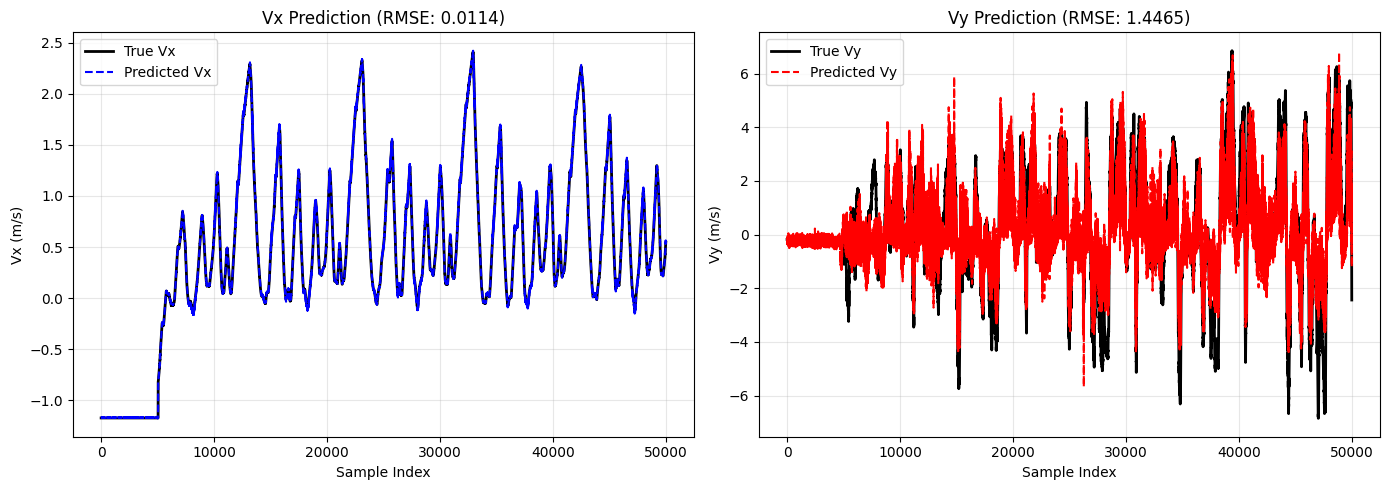

In [42]:
# Step 3: Test - Predict ALL test samples
print("\n" + "="*70)
print("SCENARIO 1: Standard Test (with vy available for comparison)")
print("="*70)

results = selfloop_prediction_test(
    complete_system=complete_system,
    test_loader=test_loader_carB, 
    device=device
)

print(f"\nResults on {results['num_samples']} test samples:")
print(f"Vx RMSE: {results['vx_rmse']:.6f} m/s")
print(f"Vy RMSE: {results['vy_rmse']:.6f} m/s")
print(f"Vx MAE:  {results['vx_mae']:.6f} m/s")
print(f"Vy MAE:  {results['vy_mae']:.6f} m/s")

# Plot results
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(results['vx_true'][:50000], label='True Vx', color='black', linewidth=2)
plt.plot(results['vx_pred'][:50000], '--', label='Predicted Vx', color='blue')
plt.title(f'Vx Prediction (RMSE: {results["vx_rmse"]:.4f})')
plt.xlabel('Sample Index')
plt.ylabel('Vx (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(results['vy_true'][:50000], label='True Vy', color='black', linewidth=2)
plt.plot(results['vy_pred'][:50000], '--', label='Predicted Vy', color='red')
plt.title(f'Vy Prediction (RMSE: {results["vy_rmse"]:.4f})')
plt.xlabel('Sample Index')
plt.ylabel('Vy (m/s)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [58]:

# ────────────────────────────────────────────────────────────────────────────
# FINAL: Save predictions to CSV
# ────────────────────────────────────────────────────────────────────────────
import pandas as pd

# Save Scenario 1 results
df_results = pd.DataFrame({
    'vx_true': results['vx_true'],
    'vx_pred': results['vx_pred'],
    'vy_true': results['vy_true'],
    'vy_pred': results['vy_pred']
})

df_results.to_csv('selfloop_predictions_standard.csv', index=False)
print("\n Predictions saved to 'selfloop_predictions_standard.csv'")


 Predictions saved to 'selfloop_predictions_standard.csv'


## Self loop V2

In [58]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ============================================================================
# PINN SELF-LOOP MODEL - FOR VY ESTIMATION
# ============================================================================

class PINN_SelfLoop(nn.Module):
    """
    PINN Self-Loop: Estimates unmeasurable vy (lateral velocity)
    
    Inputs: vx (longitudinal velocity), ax, ay (accelerations), r (yaw rate)
    Output: vy_estimated (lateral velocity)
    
    This network learns to estimate vy using physics constraints from vehicle dynamics
    """
    def __init__(self, input_dim=4, hidden_dims=[64, 32, 16], output_dim=1):
        super(PINN_SelfLoop, self).__init__()
        
        # Build network layers
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.Tanh())  # Tanh works well for physics-based problems
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, vx, ax, ay, r):
        """
        Forward pass to estimate vy
        
        Args:
            vx: longitudinal velocity (batch_size, 1)
            ax: longitudinal acceleration (batch_size, 1)
            ay: lateral acceleration (batch_size, 1)
            r: yaw rate (batch_size, 1)
        
        Returns:
            vy_estimated: estimated lateral velocity (batch_size, 1)
        """
        # Concatenate all inputs
        x = torch.cat([vx, ax, ay, r], dim=1)
        
        # Estimate vy
        vy_estimated = self.network(x)
        
        return vy_estimated


In [ ]:

# ============================================================================
# PINN TRAINER WITH PHYSICS-INFORMED LOSS
# ============================================================================

class PINN_SelfLoop_Trainer:
    """
    Trainer for PINN Self-Loop with physics-informed loss
    """
    def __init__(self, pinn_model, base_nn, device='cpu'):
        """
        Args:
            pinn_model: PINN_SelfLoop model
            base_nn: Your pre-trained base NN model
            device: 'cpu' or 'cuda'
        """
        self.pinn = pinn_model.to(device)
        self.base_nn = base_nn.to(device)
        self.device = device
        
        # Freeze base_nn (we don't want to retrain it)
        for param in self.base_nn.parameters():
            param.requires_grad = False
        self.base_nn.eval()
    
    def compute_physics_loss(self, vx, vy_estimated, ax, ay, r, dt=0.01):
        """
        Physics-informed loss based on vehicle dynamics
        
        Vehicle kinematic equations:
        1. Side slip angle: beta = arctan(vy/vx)
        2. Lateral dynamics: ay ≈ r * vx (centripetal effect)
        3. Velocity magnitude consistency
        
        Args:
            vx: longitudinal velocity
            vy_estimated: estimated lateral velocity from PINN
            ax, ay: accelerations
            r: yaw rate
            dt: time step
        
        Returns:
            physics_loss: scalar loss value
        """
        # Loss 1: Lateral acceleration consistency
        # In vehicle dynamics: ay is related to lateral velocity change
        # Simplified: ay ≈ r * vx (centripetal effect)
        lateral_dynamics_loss = torch.mean((ay - r * vx) ** 2)
        
        # Loss 2: Side slip angle should be reasonable (typically small)
        # beta = arctan(vy/vx) should be within physical limits
        beta = torch.atan2(vy_estimated, vx + 1e-6)
        # Penalize if beta is too large (> 15 degrees = 0.26 rad)
        beta_constraint_loss = torch.mean(torch.relu(torch.abs(beta) - 0.26) ** 2)
        
        # Loss 3: Velocity magnitude consistency
        # Total velocity should be smooth and consistent
        v_total = torch.sqrt(vx**2 + vy_estimated**2)
        v_change = torch.sqrt(ax**2 + ay**2) * dt
        velocity_consistency_loss = torch.mean((v_total[1:] - v_total[:-1] - v_change[:-1]) ** 2)
        
        # Combine physics losses
        physics_loss = (lateral_dynamics_loss + 
                       0.5 * beta_constraint_loss + 
                       0.3 * velocity_consistency_loss)
        
        return physics_loss
    
    def compute_data_loss(self, vx, vy_estimated, ax, ay, r, vx_next_true, vy_next_true):
        """
        Data loss: Use base_nn to check if estimated vy produces correct next state
        
        Logic:
        1. Use estimated vy with other inputs to predict next state via base_nn
        2. Compare predicted next state with actual next state
        3. This ensures vy estimate is consistent with the learned dynamics
        
        Args:
            vx, vy_estimated, ax, ay, r: current state
            vx_next_true, vy_next_true: true next state
        
        Returns:
            data_loss: RMSE between predicted and true next state
        """
        # Create input for base_nn: [vx, vy, ax, ay, r] or [vx, vy, r, ax, ay]
        # ADJUST THIS ORDER based on your base_nn's expected input order!
        base_nn_input = torch.cat([vx, vy_estimated, r, ax, ay], dim=1)
        
        # Predict next state using base_nn
        next_state_pred = self.base_nn(base_nn_input)
        vx_next_pred = next_state_pred[:, 0:1]
        vy_next_pred = next_state_pred[:, 1:2]
        
        # Compute RMSE loss
        loss_vx = torch.mean((vx_next_pred - vx_next_true) ** 2)
        loss_vy = torch.mean((vy_next_pred - vy_next_true) ** 2)
        
        data_loss = torch.sqrt(loss_vx + loss_vy)
        
        return data_loss
    
    def train_selfloop(self, train_loader, val_loader=None, 
                      epochs=100, lr=0.001, 
                      w_data=1.0, w_physics=0.5,
                      verbose=True):
        """
        Train PINN self-loop model
        
        Args:
            train_loader: DataLoader with (vx, vy, ax, ay, r, vx_next, vy_next)
            val_loader: Optional validation DataLoader
            epochs: number of training epochs
            lr: learning rate
            w_data: weight for data loss
            w_physics: weight for physics loss
            verbose: print training progress
        
        Returns:
            history: dict with training history
        """
        optimizer = torch.optim.Adam(self.pinn.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=10
        )
        
        history = {
            'train_loss': [],
            'train_data_loss': [],
            'train_physics_loss': [],
            'val_loss': []
        }
        
        best_val_loss = float('inf')
        
        for epoch in range(epochs):
            # Training phase
            self.pinn.train()
            train_loss_epoch = 0
            train_data_loss_epoch = 0
            train_physics_loss_epoch = 0
            
            for batch in train_loader:
                # Unpack batch - expecting (vx, vy, ax, ay, r, vx_next, vy_next)
                # But your loader might have (X, Y) format
                if len(batch) == 2:
                    # Format: (X, Y) where X = [vx, vy, r, ax, ay], Y = [vx_next, vy_next]
                    X, Y = batch
                    X = X.to(self.device)
                    Y = Y.to(self.device)
                    
                    vx = X[:, 0:1]
                    vy_true = X[:, 1:2]
                    r = X[:, 2:3]
                    ax = X[:, 3:4]
                    ay = X[:, 4:5]
                    vx_next = Y[:, 0:1]
                    vy_next = Y[:, 1:2]
                else:
                    # Format: separate tensors
                    vx, vy_true, ax, ay, r, vx_next, vy_next = batch
                    vx = vx.to(self.device)
                    vy_true = vy_true.to(self.device)
                    ax = ax.to(self.device)
                    ay = ay.to(self.device)
                    r = r.to(self.device)
                    vx_next = vx_next.to(self.device)
                    vy_next = vy_next.to(self.device)
                
                optimizer.zero_grad()
                
                # Estimate vy using PINN self-loop
                vy_estimated = self.pinn(vx, ax, ay, r)
                
                # Compute data loss (using base_nn)
                loss_data = self.compute_data_loss(
                    vx, vy_estimated, ax, ay, r, vx_next, vy_next
                )
                
                # Compute physics loss
                loss_physics = self.compute_physics_loss(
                    vx, vy_estimated, ax, ay, r
                )
                
                # Combined loss
                total_loss = w_data * loss_data + w_physics * loss_physics
                
                # Backward pass
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(self.pinn.parameters(), max_norm=1.0)
                optimizer.step()
                
                train_loss_epoch += total_loss.item()
                train_data_loss_epoch += loss_data.item()
                train_physics_loss_epoch += loss_physics.item()
            
            # Average losses
            train_loss_epoch /= len(train_loader)
            train_data_loss_epoch /= len(train_loader)
            train_physics_loss_epoch /= len(train_loader)
            
            history['train_loss'].append(train_loss_epoch)
            history['train_data_loss'].append(train_data_loss_epoch)
            history['train_physics_loss'].append(train_physics_loss_epoch)
            
            # Validation phase
            if val_loader is not None:
                val_loss = self.validate(val_loader, w_data, w_physics)
                history['val_loss'].append(val_loss)
                scheduler.step(val_loss)
                
                # Save best model
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    torch.save(self.pinn.state_dict(), 'best_pinn_selfloop.pth')
                    if verbose:
                        print(f"  → Best model saved (Val Loss: {val_loss:.6f})")
                
                if verbose and (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch+1}/{epochs} | "
                          f"Train Loss: {train_loss_epoch:.6f} | "
                          f"Data: {train_data_loss_epoch:.6f} | "
                          f"Physics: {train_physics_loss_epoch:.6f} | "
                          f"Val: {val_loss:.6f}")
            else:
                if verbose and (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch+1}/{epochs} | "
                          f"Train Loss: {train_loss_epoch:.6f} | "
                          f"Data: {train_data_loss_epoch:.6f} | "
                          f"Physics: {train_physics_loss_epoch:.6f}")
        
        if verbose:
            print("\nTraining complete!")
            if val_loader is not None:
                print(f"Best validation loss: {best_val_loss:.6f}")
        
        return history
    
    def validate(self, val_loader, w_data, w_physics):
        """Validation step"""
        self.pinn.eval()
        val_loss = 0
        
        with torch.no_grad():
            for batch in val_loader:
                # Handle both data formats
                if len(batch) == 2:
                    X, Y = batch
                    X = X.to(self.device)
                    Y = Y.to(self.device)
                    
                    vx = X[:, 0:1]
                    vy_true = X[:, 1:2]
                    r = X[:, 2:3]
                    ax = X[:, 3:4]
                    ay = X[:, 4:5]
                    vx_next = Y[:, 0:1]
                    vy_next = Y[:, 1:2]
                else:
                    vx, vy_true, ax, ay, r, vx_next, vy_next = batch
                    vx = vx.to(self.device)
                    ax = ax.to(self.device)
                    ay = ay.to(self.device)
                    r = r.to(self.device)
                    vx_next = vx_next.to(self.device)
                    vy_next = vy_next.to(self.device)
                
                vy_estimated = self.pinn(vx, ax, ay, r)
                
                loss_data = self.compute_data_loss(
                    vx, vy_estimated, ax, ay, r, vx_next, vy_next
                )
                loss_physics = self.compute_physics_loss(
                    vx, vy_estimated, ax, ay, r
                )
                
                total_loss = w_data * loss_data + w_physics * loss_physics
                val_loss += total_loss.item()
        
        return val_loss / len(val_loader)


In [56]:
# ============================================================================
# PREDICTION FUNCTION - SELF-LOOP WITH PINN
# ============================================================================

def self_loop_prediction_with_pinn(base_model, pinn_selfloop, test_loader, device):
    """
    Self-loop prediction using PINN for vy estimation
    
    This is the CORRECT way to do self-loop prediction where vy is unmeasurable
    
    Args:
        base_model: Your trained base NN
        pinn_selfloop: Trained PINN self-loop model for vy estimation
        test_loader: Test data loader
        device: 'cuda' or 'cpu'
    
    Returns:
        vx_true, vy_true, vx_pred, vy_pred: numpy arrays
    """
    base_model.eval()
    pinn_selfloop.eval()

    vx_true_all, vy_true_all = [], []
    vx_pred_all, vy_pred_all = [], []

    with torch.no_grad():
        for Xb, Yb in test_loader:
            Xb = Xb.to(device)
            Yb = Yb.to(device)

            for i in range(len(Xb)):
                # Extract ONLY measurable variables (NO vy!)
                vx = Xb[i, 0].unsqueeze(0).unsqueeze(0)      # (1, 1)
                vy_true = Xb[i, 1].unsqueeze(0)              # only for comparison
                r = Xb[i, 2].unsqueeze(0).unsqueeze(0)       # (1, 1)
                ax = Xb[i, 3].unsqueeze(0).unsqueeze(0)      # (1, 1)
                ay = Xb[i, 4].unsqueeze(0).unsqueeze(0)      # (1, 1)

                # STEP 1: Use PINN self-loop to ESTIMATE vy (state estimation!)
                vy_estimated = pinn_selfloop(vx, ax, ay, r)

                # STEP 2: Use estimated vy with base model to predict next state
                # ADJUST THIS ORDER based on your base_nn's expected input!
                model_input = torch.cat([vx, vy_estimated, r, ax, ay], dim=1)
                Y_pred = base_model(model_input)

                # Store results
                vx_pred_all.append(Y_pred[:, 0].item())
                vy_pred_all.append(Y_pred[:, 1].item())
                vx_true_all.append(Yb[i, 0].item())
                vy_true_all.append(Yb[i, 1].item())

    return (
        np.array(vx_true_all),
        np.array(vy_true_all),
        np.array(vx_pred_all),
        np.array(vy_pred_all)
    )



In [57]:
# ============================================================================
# EVALUATION FUNCTIONS
# ============================================================================

def evaluate_selfloop(pinn_model, base_nn, test_loader, device='cpu'):
    """
    Evaluate PINN self-loop on test data
    
    Returns:
        results: dict with vy estimates and errors
    """
    pinn_model.eval()
    base_nn.eval()
    
    all_vy_true = []
    all_vy_estimated = []
    all_errors = []
    
    with torch.no_grad():
        for batch in test_loader:
            # Your data loader returns (X, Y) format
            X, Y = batch
            X = X.to(device)
            
            # Extract features from X: [vx, vy, r, ax, ay]
            vx = X[:, 0:1]
            vy_true = X[:, 1:2]
            r = X[:, 2:3]
            ax = X[:, 3:4]
            ay = X[:, 4:5]
            
            # Estimate vy using PINN (only uses vx, ax, ay, r - NOT vy!)
            vy_estimated = pinn_model(vx, ax, ay, r)
            
            # Calculate error
            error = torch.abs(vy_estimated - vy_true)
            
            all_vy_true.extend(vy_true.cpu().numpy().flatten())
            all_vy_estimated.extend(vy_estimated.cpu().numpy().flatten())
            all_errors.extend(error.cpu().numpy().flatten())
    
    results = {
        'vy_true': np.array(all_vy_true),
        'vy_estimated': np.array(all_vy_estimated),
        'errors': np.array(all_errors),
        'mae': np.mean(all_errors),
        'rmse': np.sqrt(np.mean(np.array(all_errors)**2))
    }
    
    return results


def plot_selfloop_results(results, save_path=None):
    """
    Plot self-loop estimation results
    
    Args:
        results: dict from evaluate_selfloop()
        save_path: optional path to save figure
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: True vs Estimated vy
    axes[0, 0].scatter(results['vy_true'], results['vy_estimated'], 
                       alpha=0.5, s=10)
    axes[0, 0].plot([results['vy_true'].min(), results['vy_true'].max()],
                    [results['vy_true'].min(), results['vy_true'].max()], 
                    'r--', lw=2, label='Perfect estimation')
    axes[0, 0].set_xlabel('True Vy (m/s)', fontsize=12)
    axes[0, 0].set_ylabel('Estimated Vy (m/s)', fontsize=12)
    axes[0, 0].set_title('True vs Estimated Lateral Velocity', fontsize=14)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Time series comparison
    sample_range = min(50000, len(results['vy_true']))
    axes[0, 1].plot(results['vy_true'][:sample_range], 
                    label='True Vy', linewidth=2)
    axes[0, 1].plot(results['vy_estimated'][:sample_range], 
                    label='Estimated Vy', linewidth=2, alpha=0.7)
    axes[0, 1].set_xlabel('Time Step', fontsize=12)
    axes[0, 1].set_ylabel('Vy (m/s)', fontsize=12)
    axes[0, 1].set_title('Time Series Comparison', fontsize=14)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Error distribution
    axes[1, 0].hist(results['errors'], bins=50, alpha=0.7, edgecolor='black')
    axes[1, 0].axvline(results['mae'], color='r', linestyle='--', 
                       linewidth=2, label=f'MAE: {results["mae"]:.4f}')
    axes[1, 0].set_xlabel('Absolute Error (m/s)', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)
    axes[1, 0].set_title('Error Distribution', fontsize=14)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Error over time
    axes[1, 1].plot(results['errors'][:sample_range], linewidth=1)
    axes[1, 1].axhline(results['mae'], color='r', linestyle='--', 
                       linewidth=2, label=f'Mean Error: {results["mae"]:.4f}')
    axes[1, 1].set_xlabel('Time Step', fontsize=12)
    axes[1, 1].set_ylabel('Absolute Error (m/s)', fontsize=12)
    axes[1, 1].set_title('Error Over Time', fontsize=14)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("PINN SELF-LOOP VY ESTIMATION RESULTS")
    print("="*60)
    print(f"Mean Absolute Error (MAE): {results['mae']:.6f} m/s")
    print(f"Root Mean Square Error (RMSE): {results['rmse']:.6f} m/s")
    print(f"Max Error: {results['errors'].max():.6f} m/s")
    print(f"Min Error: {results['errors'].min():.6f} m/s")
    print("="*60)




In [71]:
# ============================================================================
# COMPLETE USAGE EXAMPLE
# ============================================================================

# Setup
          
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1. Load your base model
base_nn = model
#base_nn.load_state_dict(torch.load('your_base_model.pth'))
base_nn = base_nn.to(device)

# 2. Create PINN self-loop
pinn_selfloop = PINN_SelfLoop(
    input_dim=4,              # vx, ax, ay, r
    hidden_dims=[64, 32, 16],
    output_dim=1              # vy
).to(device)

In [72]:
# 3. Train PINN
trainer = PINN_SelfLoop_Trainer(pinn_selfloop, base_nn, device)
history = trainer.train_selfloop(
    train_loader=train_loader,
    val_loader=Val_Data_loader,
    epochs=50,
    lr=0.001,
    w_data=1.0,
    w_physics=0.5
)

  → Best model saved (Val Loss: 0.881090)


KeyboardInterrupt: 

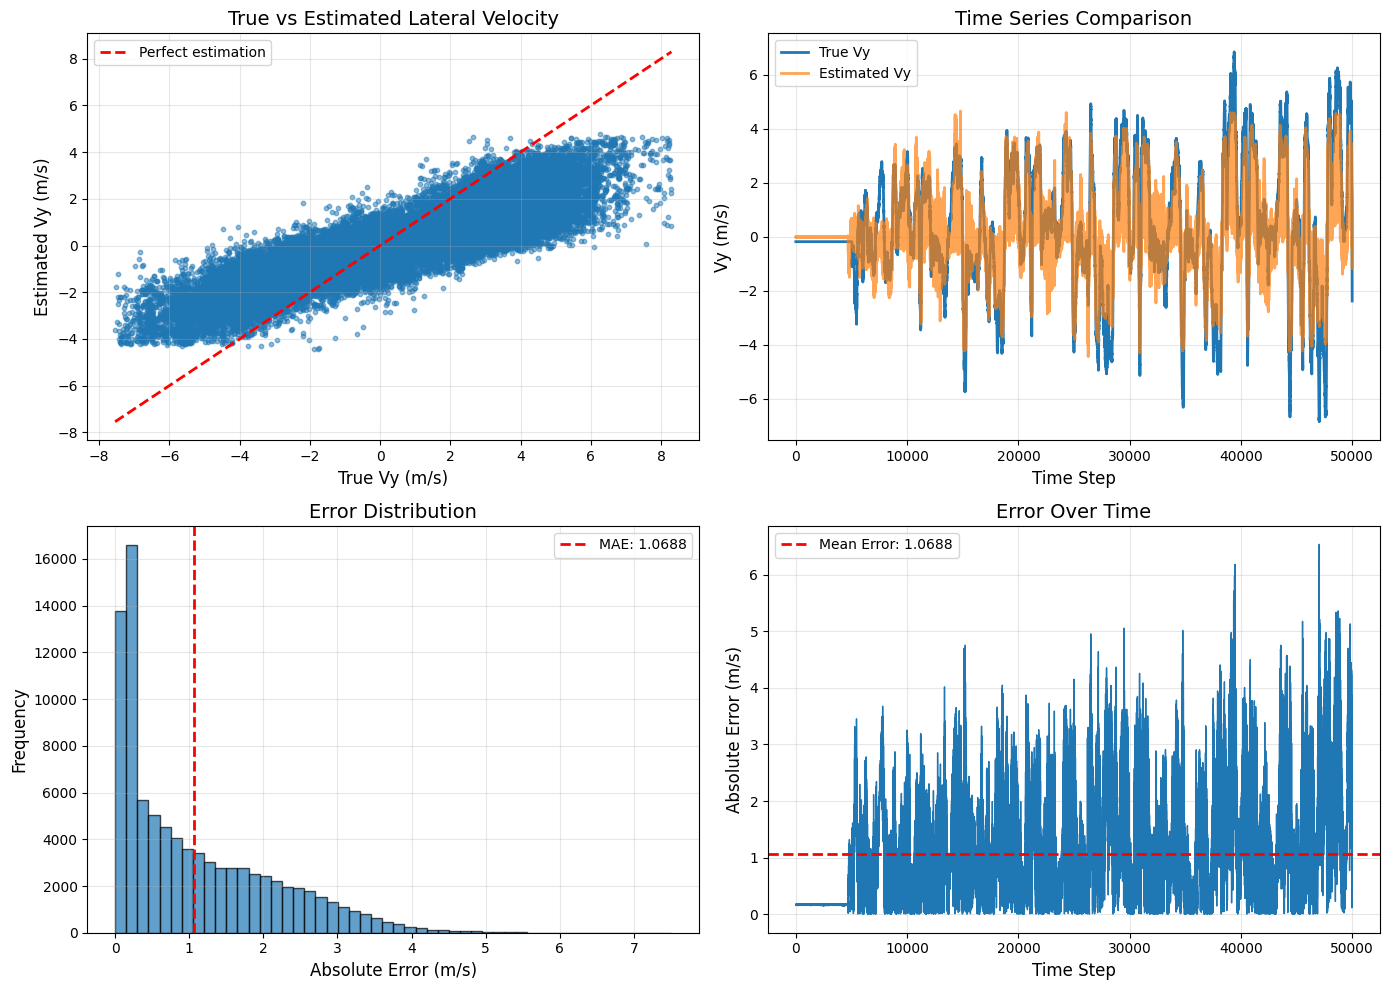


PINN SELF-LOOP VY ESTIMATION RESULTS
Mean Absolute Error (MAE): 1.068825 m/s
Root Mean Square Error (RMSE): 1.485599 m/s
Max Error: 7.504858 m/s
Min Error: 0.000003 m/s


In [60]:
# 4. Evaluate vy estimation
results = evaluate_selfloop(pinn_selfloop, base_nn, test_loader_carB, device)
plot_selfloop_results(results)

In [61]:
# 5. Run self-loop prediction
vx_true, vy_true, vx_pred, vy_pred = self_loop_prediction_with_pinn(
    base_nn, pinn_selfloop, test_loader_carB  , device
)


In [62]:
# 6. Calculate final metrics
vx_rmse = np.sqrt(mean_squared_error(vx_true, vx_pred))
vy_rmse = np.sqrt(mean_squared_error(vy_true, vy_pred))
print(f"Vx RMSE: {vx_rmse:.6f}")
print(f"Vy RMSE: {vy_rmse:.6f}")


# 7. Save model
torch.save(pinn_selfloop.state_dict(), 'pinn_selfloop.pth')

Vx RMSE: 0.014827
Vy RMSE: 1.473448


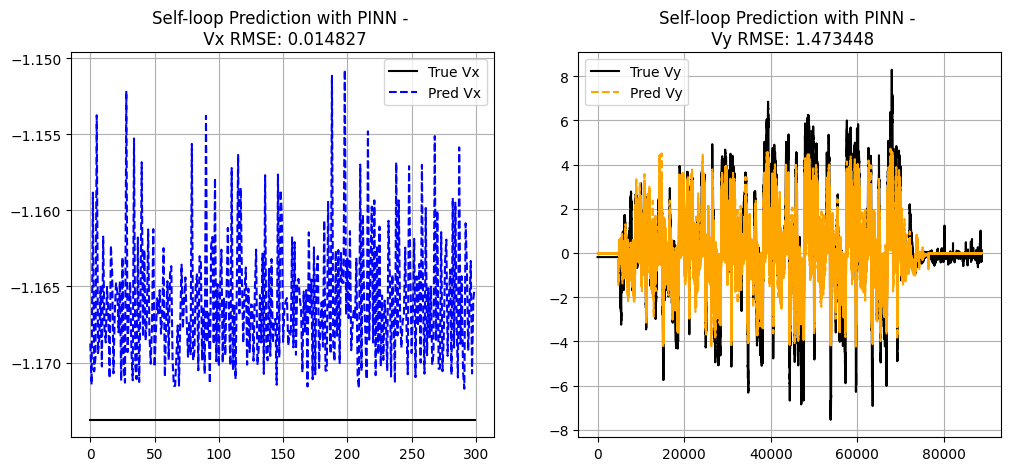

In [63]:
#create prediction vs actual plots for vx and vy using the self-loop prediction results
import matplotlib.pyplot as plt     
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(vx_true[:300], label='True Vx', color='black')
plt.plot(vx_pred[:300], '--', label='Pred Vx', color='blue')
plt.title(f"Self-loop Prediction with PINN - \n Vx RMSE: {vx_rmse:.6f}") # mention RMSE in title
plt.legend()        
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(vy_true[:], label='True Vy', color='black')
plt.plot(vy_pred[:], '--', label='Pred Vy', color='orange')
plt.title(f"Self-loop Prediction with PINN - \n Vy RMSE: {vy_rmse:.6f}") # mention RMSE in title
plt.legend()
plt.grid(True)
plt.show()


# RNN BASED STATE ESTIMATOR for V2

## Define RNN model for Vy Estimation

In [73]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ============================================================================
# TASK 2: EXTENSION NETWORK - REFINE VY ESTIMATES
# ============================================================================

class ExtensionNetwork_NN(nn.Module):
    """
    Extension Network (Feedforward NN version)
    
    Takes PINN's vy estimate and refines it using additional context
    
    Inputs:
        - vy(k+1) from PINN self-loop
        - vx(k+1) 
        - ax, ay (control inputs)
    
    Output:
        - Refined vy(k+1)
    """
    def __init__(self, input_dim=4, hidden_dims=[32, 16], output_dim=1):
        super(ExtensionNetwork_NN, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, vy_pred, vx_pred, ax, ay):
        """
        Refine vy estimate from PINN
        
        Args:
            vy_pinn: vy estimate from PINN self-loop (batch, 1)
            vx: longitudinal velocity (batch, 1)
            ax: longitudinal acceleration (batch, 1)
            ay: lateral acceleration (batch, 1)
        
        Returns:
            vy_refined: refined vy estimate (batch, 1)
        """
        # Concatenate all inputs
        x = torch.cat([vy_pred, vx_pred, ax, ay], dim=1)
        
        # Refine vy
        vy_refined = self.network(x)
        
        return vy_refined


class ExtensionNetwork_RNN(nn.Module):
    """
    Extension Network (RNN/GRU version)
    
    Uses temporal patterns to refine vy estimates
    Better for capturing sequential dependencies
    
    Inputs:
        - vy(k+1) from PINN self-loop
        - vx(k+1)
        - ax, ay (control inputs)
    
    Output:
        - Refined vy(k+1)
    """
    def __init__(self, input_dim=4, hidden_dim=32, num_layers=2, output_dim=1):
        super(ExtensionNetwork_RNN, self).__init__()
        
        # GRU layer
        self.rnn = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        
        # Output layer
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, vy_pred, vx_pred, ax, ay, hidden=None):
        """
        Refine vy estimate from PINN using temporal context
        
        Args:
            vy_pinn: vy estimate from PINN (batch, 1)
            vx: longitudinal velocity (batch, 1)
            ax: longitudinal acceleration (batch, 1)
            ay: lateral acceleration (batch, 1)
            hidden: previous hidden state (optional)
        
        Returns:
            vy_refined: refined vy estimate (batch, 1) - JUST THE TENSOR
            hidden: updated hidden state
        """
        # Concatenate inputs
        x = torch.cat([vy_pred, vx_pred, ax, ay], dim=1)
        
        # Add sequence dimension for RNN (batch, seq_len=1, features)
        x = x.unsqueeze(1)
        
        # Pass through RNN
        if hidden is not None:
            out, hidden = self.rnn(x, hidden)
        else:
            out, hidden = self.rnn(x)
        
        # Remove sequence dimension and pass through FC layer
        out = out.squeeze(1)
        vy_refined = self.fc(out)
        
        return vy_refined, hidden



In [65]:
class CompletePINNSystem(nn.Module):
    """
    Combines:
        1. Base NN (predicts vx(k+1), vy(k+1))
        2. Extension RNN (refines vy(k+1))
    """
    def __init__(self, base_model, extension_network, use_rnn=True):
        super().__init__()

        self.base = base_model
        self.extension = extension_network
        self.use_rnn = use_rnn

        # Freeze base model
        for param in self.base.parameters():
            param.requires_grad = False
        self.base.eval()

    def forward(self, vx_k, vy_est_k, r_k, ax_k, ay_k, hidden=None):
        """
        Inputs:
            vx_k: measured vx(k)
            vy_est_k: estimated/predicted vy(k) from previous step
            r_k, ax_k, ay_k: inputs at time k
        Returns:
            vy_refined(k+1), hidden
        """

        # STEP 1 — Base model predicts full next state
        base_input = torch.cat([vx_k, vy_est_k, r_k, ax_k, ay_k], dim=1)
        next_state = self.base(base_input)

        vx_pred = next_state[:, 0:1]  # vx(k+1)
        vy_pred = next_state[:, 1:2]  # vy(k+1)

        # STEP 2 — Extension refines vy(k+1)
        if self.use_rnn:
            vy_refined, hidden = self.extension(vy_pred, vx_pred, ax_k, ay_k, hidden)
        else:
            vy_refined = self.extension(vy_pred, vx_pred, ax_k, ay_k)
            hidden = None

        return vx_pred, vy_pred, vy_refined, hidden


In [66]:

# ============================================================================
# TRAINER FOR EXTENSION NETWORK
# ============================================================================

class ExtensionNetwork_Trainer:
    """
    Trainer for Extension Network (Task 2)
    """
    def __init__(self, complete_system, base_nn, device='cpu'):
        """
        Args:
            complete_system: CompletePINNSystem (PINN + Extension)
            base_nn: Your pre-trained base NN
            device: 'cpu' or 'cuda'
        """
        self.system = complete_system.to(device)
        self.base_nn = base_nn.to(device)
        self.device = device
        self.use_rnn = complete_system.use_rnn
        
        # Freeze base_nn
        for param in self.base_nn.parameters():
            param.requires_grad = False
        self.base_nn.eval()
    
    def compute_loss(self, vx, vy_refined, ax, ay, r, vx_next_true, vy_next_true):
        """
        Loss function: Check if refined vy works with base_nn
        
        Similar to Task 1, but now we're refining the estimate
        """
        # Create input for base_nn
        base_nn_input = torch.cat([vx, vy_refined, r, ax, ay], dim=1)
        
        # Predict next state
        next_state_pred = self.base_nn(base_nn_input)
        vx_next_pred = next_state_pred[:, 0:1]
        vy_next_pred = next_state_pred[:, 1:2]
        
        # MSE loss
        loss_vx = torch.mean((vx_next_pred - vx_next_true) ** 2)
        loss_vy = torch.mean((vy_next_pred - vy_next_true) ** 2)
        
        # RMSE
        loss = torch.sqrt(loss_vx + loss_vy)
        
        return loss
    
    def train_extension(self, train_loader, val_loader=None,
                       epochs=50, lr=0.001, verbose=True):
        """
        Train Extension Network
        
        Args:
            train_loader: Training data loader
            val_loader: Validation data loader
            epochs: Number of epochs
            lr: Learning rate
            verbose: Print progress
        
        Returns:
            history: Training history
        """
        # Only train extension network parameters
        optimizer = torch.optim.Adam(
            self.system.extension.parameters(), lr=lr
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=10
        )
        
        history = {
            'train_loss': [],
            'val_loss': []
        }
        
        best_val_loss = float('inf')
        
        for epoch in range(epochs):
            # Training
            self.system.train()
            self.system.extension.train()  # Only extension is trainable
            
            train_loss_epoch = 0
            
            for batch in train_loader:
                # Extract data
                X, Y = batch
                X = X.to(self.device)
                Y = Y.to(self.device)
                
                vx = X[:, 0:1]
                vy_true = X[:, 1:2]
                r = X[:, 2:3]
                ax = X[:, 3:4]
                ay = X[:, 4:5]
                vx_next = Y[:, 0:1]
                vy_next = Y[:, 1:2]
                
                optimizer.zero_grad()
                
                # Forward pass through complete system
                result = self.system(vx, ax, ay, r)
                
                # Recursively extract tensor from nested tuples
                vy_refined = result
                while isinstance(vy_refined, tuple):
                    vy_refined = vy_refined[0]
                
                # Ensure vy_refined is a tensor
                if not torch.is_tensor(vy_refined):
                    raise TypeError(f"vy_refined should be tensor, got {type(vy_refined)}")
                
                # Compute loss
                loss = self.compute_loss(
                    vx, vy_refined, ax, ay, r, vx_next, vy_next
                )
                
                # Backward pass
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    self.system.extension.parameters(), max_norm=1.0
                )
                optimizer.step()
                
                train_loss_epoch += loss.item()
            
            train_loss_epoch /= len(train_loader)
            history['train_loss'].append(train_loss_epoch)
            
            # Validation
            if val_loader is not None:
                val_loss = self.validate(val_loader)
                history['val_loss'].append(val_loss)
                scheduler.step(val_loss)
                
                # Save best model
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    torch.save(
                        self.system.extension.state_dict(),
                        'best_extension_network.pth'
                    )
                    if verbose:
                        print(f"  → Best model saved (Val Loss: {val_loss:.6f})")
                
                if verbose and (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch+1}/{epochs} | "
                          f"Train Loss: {train_loss_epoch:.6f} | "
                          f"Val Loss: {val_loss:.6f}")
            else:
                if verbose and (epoch + 1) % 10 == 0:
                    print(f"Epoch {epoch+1}/{epochs} | "
                          f"Train Loss: {train_loss_epoch:.6f}")
        
        if verbose:
            print("\nExtension Network training complete!")
            if val_loader is not None:
                print(f"Best validation loss: {best_val_loss:.6f}")
        
        return history
    
    def validate(self, val_loader):
        """Validation step"""
        self.system.eval()
        val_loss = 0
        
        with torch.no_grad():
            for batch in val_loader:
                X, Y = batch
                X = X.to(self.device)
                Y = Y.to(self.device)
                
                vx = X[:, 0:1]
                r = X[:, 2:3]
                ax = X[:, 3:4]
                ay = X[:, 4:5]
                vx_next = Y[:, 0:1]
                vy_next = Y[:, 1:2]
                
                # Forward pass (works for both NN and RNN)
                result = self.system(vx, ax, ay, r)
                
                # Recursively extract tensor from nested tuples
                vy_refined = result
                while isinstance(vy_refined, tuple):
                    vy_refined = vy_refined[0]
                
                loss = self.compute_loss(
                    vx, vy_refined, ax, ay, r, vx_next, vy_next
                )
                val_loss += loss.item()
        
        return val_loss / len(val_loader)



In [67]:
def evaluate_complete_system(complete_system, test_loader, device='cpu'):
    complete_system.eval()

    all_true, all_pred, all_refined = [], [], []

    with torch.no_grad():
        for X, Y in test_loader:
            X, Y = X.to(device), Y.to(device)

            vx = X[:, 0:1]
            vy_k = X[:, 1:2]
            r = X[:, 2:3]
            ax = X[:, 3:4]
            ay = X[:, 4:5]

            vx_pred, vy_pred, vy_refined, _ = complete_system(vx, vy_k, r, ax, ay)

            all_true.extend(Y[:, 1].cpu().numpy())
            all_pred.extend(vy_pred.cpu().numpy())
            all_refined.extend(vy_refined.cpu().numpy())

    return {
        'vy_true': np.array(all_true),
        'vy_pinn': np.array(all_pred),
        'vy_refined': np.array(all_refined)
    }


In [74]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ========================================
# STEP 1: Choose Extension Network Type
# ========================================

# # Option A: Simple NN (faster, simpler)
# extension_network = ExtensionNetwork_NN(
#     input_dim=4,              # vy_pinn, vx, ax, ay
#     hidden_dims=[32, 16],
#     output_dim=1              # refined vy
# ).to(device)


#Option B: RNN (better for temporal patterns)
extension_network = ExtensionNetwork_RNN(
    input_dim=4,
    hidden_dim=32,
    num_layers=2,
    output_dim=1
).to(device)


In [75]:

# ========================================
# STEP 2: Create Complete System
# ========================================
complete_system = CompletePINNSystem(
    pinn_selfloop=pinn_selfloop,      # Your trained PINN from Task 1
    extension_network=extension_network,
    use_rnn=False                      # Set True if using RNN
).to(device)


TypeError: CompletePINNSystem.__init__() got an unexpected keyword argument 'pinn_selfloop'

In [ ]:

# ========================================
# STEP 3: Train Extension Network
# ========================================
trainer = ExtensionNetwork_Trainer(
    complete_system=complete_system,
    base_nn=base_nn,                   # Your base model
    device=device
)

history = trainer.train_extension(
    train_loader=train_loader,
    val_loader=Val_Data_loader,
    epochs=50,
    lr=0.001,
    verbose=True
)

# ========================================
# STEP 4: Evaluate Complete System
# ========================================
results = evaluate_complete_system(
    complete_system, 
    test_loader_carB, 
    device
)

# ========================================
# STEP 5: View Results
# ========================================
print("\n" + "="*70)
print("COMPARISON: PINN vs PINN+Extension")
print("="*70)
print(f"PINN Only:")
print(f"  MAE:  {results['pinn_mae']:.6f} m/s")
print(f"  RMSE: {results['pinn_rmse']:.6f} m/s")
print(f"\nPINN + Extension:")
print(f"  MAE:  {results['refined_mae']:.6f} m/s")
print(f"  RMSE: {results['refined_rmse']:.6f} m/s")
print(f"\nImprovement:")
print(f"  MAE:  {results['improvement_mae']:.6f} m/s")
print(f"  RMSE: {results['improvement_rmse']:.6f} m/s")
print("="*70)

# APPROACH 3

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def run_self_loop_inference_robust(model, df_test, scalers, device='cpu'):
    model.eval()
    model.to(device)
    
    # 1. Extract Measurable Signals
    vx_meas = df_test["vxCG"].values
    r_meas  = df_test["yawRate"].values
    ax_meas = df_test["axCG"].values
    ay_meas = df_test["ayCG"].values
    
    # Ground truth for plotting later
    vy_ground_truth = df_test["vyCG"].values

    n_samples = len(df_test)
    vy_preds_full = np.zeros(n_samples) 
    vx_preds_full = np.zeros(n_samples)

    # --- SAFETY RAIL 1: Define Physical Limits ---
    
    # Clamp vy to reasonable limits (e.g., -10 to +10 m/s).
    MAX_VY = np.max(vy_b)
    MIN_VY = np.min(vy_b)
    
    # Initial Condition
    current_vy_est = 0.0 
    
    print(f"Starting Robust Inference on {n_samples} samples...")

    with torch.no_grad():
        for k in range(n_samples - 1):
            
            # --- SAFETY RAIL 2: NaN Check ---
            # If the model output becomes NaN (Not a Number), reset it to 0
            if np.isnan(current_vy_est) or np.isinf(current_vy_est):
                print(f"Warning: Instability detected at step {k}. Resetting vy to 0.")
                current_vy_est = 0.0

            # A. Construct Input (Using Measured Data + Previous Estimate)
            row_input = np.array([[
                vx_meas[k],      
                current_vy_est,  # Feedback
                r_meas[k],       
                ax_meas[k],      
                ay_meas[k]       
            ]])

            # B. Scale Inputs
            row_scaled = np.column_stack([
                scalers['vx'].transform(row_input[:, [0]]),
                scalers['vy'].transform(row_input[:, [1]]),
                scalers['r'].transform(row_input[:, [2]]),
                scalers['ax'].transform(row_input[:, [3]]),
                scalers['ay'].transform(row_input[:, [4]])
            ])
            
            # C. Predict
            input_tensor = torch.tensor(row_scaled, dtype=torch.float32).to(device)
            output_scaled = model(input_tensor)
            
            # D. Inverse Scale
            # (If the model predicted a huge number, this is where it would crash)
            output_real = scalers['Y'].inverse_transform(output_scaled.cpu().numpy())
            
            pred_vx_next = output_real[0, 0]
            pred_vy_next = output_real[0, 1]
            
            # --- SAFETY RAIL 3: Clamp the Prediction ---
            # Force the prediction to stay within physics limits before next step
            pred_vy_next = np.clip(pred_vy_next, MIN_VY, MAX_VY)

            # Store and Update
            vx_preds_full[k+1] = pred_vx_next
            vy_preds_full[k+1] = pred_vy_next
            current_vy_est = pred_vy_next 

    return vx_preds_full, vy_preds_full, vy_ground_truth


In [73]:
my_scalers = {
    'vx': scaler_vx,
    'vy': scaler_vy,
    'r':  scaler_r,
    'ax': scaler_ax,
    'ay': scaler_ay,
    'Y':  scaler_Y
}

In [77]:

# ---------------------------------------------------------
# EXECUTE CORRECTION
# ---------------------------------------------------------
vx_est, vy_est, vy_true = run_self_loop_inference_robust(model, test_data_carB, my_scalers)

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(vy_true, 'k-', label='Ground Truth', alpha=0.3)
plt.plot(vy_est, 'r--', label='Model Estimation (Robust)', linewidth=1.5)
plt.ylim([-5, 5]) # Zoom in to see normal driving range
plt.title("Task A Result: Robust Self-Loop Inference")
plt.xlabel("Time Step")
plt.ylabel("Lateral Velocity vy (m/s)")
plt.legend()
plt.grid(True)
plt.show()

Starting Robust Inference on 88800 samples...


KeyboardInterrupt: 

In [75]:
import numpy as np

def calculate_rmse(predictions, ground_truth):
    """
    Calculates the Root Mean Square Error (RMSE).

    Args:
        predictions (np.ndarray): The model's estimated values (e.g., vy_est).
        ground_truth (np.ndarray): The true target values (e.g., vy_true).

    Returns:
        float: The RMSE value.
    """
    # Ensure arrays have the same length (we ignore the first index k=0 
    # as the loop started at k=0, predicting k=1)
    
    # We only care about the indices where both arrays have data (k=1 onward)
    n_samples = len(predictions) - 1
    
    # Calculate the squared difference
    squared_error = (predictions[1:] - ground_truth[1:]) ** 2
    
    # Calculate the Mean Squared Error (MSE)
    mse = np.mean(squared_error)
    
    # Calculate the Root Mean Square Error (RMSE)
    rmse = np.sqrt(mse)
    
    return rmse

# ---------------------------------------------------------
# EXECUTION
# ---------------------------------------------------------

# Ensure vy_est and vy_true variables exist from the previous execution
try:
    # Calculate RMSE for the lateral velocity (vy) estimation
    rmse_vy = calculate_rmse(vy_est, vy_true)
    
    # Optionally, calculate RMSE for the longitudinal velocity (vx) prediction
    #rmse_vx = calculate_rmse(vx_est, vx_meas) # Need to use the original measured vx for this comparison
    
    print("\n--- State Estimation Performance (Self-Loop) ---")
    print(f"RMSE (Lateral Velocity, vy): {rmse_vy:.4f} m/s")
    #print(f"RMSE (Longitudinal Velocity, vx): {rmse_vx:.4f} m/s (Prediction)")
    print("---------------------------------------------")

except NameError:
    print("Error: The variables 'vy_est', 'vy_true', 'vx_est', or 'vx_meas' were not found.")
    print("Please ensure you have run the 'run_self_loop_inference_robust' function successfully first.")


--- State Estimation Performance (Self-Loop) ---
RMSE (Lateral Velocity, vy): 6.3692 m/s
---------------------------------------------


# New approach

In [79]:
if __name__ == '__main__':
    # 1. Configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  # params = {
  #       "num_epochs": 100,
  #       "lr": float(best_row["config/lr"]),
  #       "hidden_dim": int(best_row["config/hidden_dim"]),
  #       "N_phys": int(best_row["config/N_phys"]),
  #       "w_data": 1.0,
  #       "w_phys_init": float(best_row["config/w_phys_init"]),
  #       "decay_rate":float(best_row["config/decay_rate"] ),
  #       "dt": 0.01
  #   }

  #   # 2. Instantiate Model and Train
  #   model_pinn = VehicleNN(input_dim=5, output_dim=2,hidden_dim=hidden_dim=best_params["hidden_dim"]).to(device))
    
  
  #   trained_model_pinn, d_l, p_l, t_l = train_pinn(model_pinn, params, train_loader, device)
    
    # 3. Save the result for Phase 2
    torch.save(model.state_dict(), "frozen_pinn_model.pth")
    print("Frozen PINN Model Saved.")

Frozen PINN Model Saved.


In [80]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

class CorrectorRNN(nn.Module):
    """
    GRU-based model to predict the residual error (epsilon) of the PINN's vy prediction.
    """
    def __init__(self, input_size, hidden_size=32, num_layers=2):
        super(CorrectorRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # GRU layer processes the sequence data
        self.gru = nn.GRU(
            input_size, 
            hidden_size, 
            num_layers, 
            batch_first=True
        )
        
        # Output layer maps the final hidden state to the 1D correction (epsilon_vy)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_size)
        
        # Initialize hidden state (h0)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate GRU
        # out shape: (batch_size, seq_len, hidden_size)
        # hn shape: (num_layers, batch_size, hidden_size)
        out, _ = self.gru(x, h0)
        
        # Decode the hidden state of the LAST time step
        # We only care about the correction at the current step (k+1)
        # out[:, -1, :] selects the output features for the last step in the sequence
        out = self.fc(out[:, -1, :])
        
        # out shape: (batch_size, 1) -> The predicted epsilon_vy
        return out

In [81]:
# Assuming 'trained_model_pinn' (from Phase 1) and 'X_train_scaled' (from data prep) are available.
# Set the PINN to evaluation mode and move to device
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32, device=device)

with torch.no_grad():
    # Base Prediction: [vx_k+1_pred, vy_k+1_pred]
    Y_base_pred_scaled = model(X_train_tensor).cpu().numpy()

# Inverse transform the base prediction back to real units
Y_base_pred_real = scaler_Y.inverse_transform(Y_base_pred_scaled)

# True Target (Real Units)
Y_train_real = Y_train # This is the original non-scaled target data [vx_k+1, vy_k+1]

In [82]:
# The residual error epsilon for vy
epsilon_vy = Y_train_real[:, 1] - Y_base_pred_real[:, 1] 
epsilon_vy = epsilon_vy.reshape(-1, 1) # Reshape to (N, 1)
print(f"Residual error shape: {epsilon_vy.shape}")

Residual error shape: (63359, 1)


In [83]:
class CorrectorDataset(Dataset):
    def __init__(self, Y_base_pred, X_train, epsilon_target, sequence_length):
        # The input features for the corrector at time k are the 
        # PINN's base prediction at k+1 AND the measurements at k.
        
        # Input features: Base Prediction (vy_pred) + Measurements (vx, vy, r, ax, ay)
        # We need to shift X_train by one to align inputs with predictions/targets.
        
        # Feature vector at time k: [PINN_vy_k+1_pred, vx_k, vy_k, r_k, ax_k, ay_k]
        # For simplicity and robustness, we use the original PINN input features (X_train) 
        # plus the PINN's vy prediction as the main input.
        
        # Features for the Corrector: [vy_k+1_pred, vx_k, r_k, ax_k, ay_k]
        # We use the original PINN input features (X_train) for stability.
        
        # Simplified Input (Concatenate necessary data for the RNN):
        # We will use the original input features X_train and the PINN's output prediction Y_base_pred
        # Note: X_train contains [vx_k, vy_k, r_k, ax_k, ay_k]
        # The features are the inputs that led to the error AND the output that resulted in the error.
        
        # Input features for RNN: [vx_k, vy_k, r_k, ax_k, ay_k, vx_k+1_base_pred, vy_k+1_base_pred]
        self.features = np.hstack([X_train, Y_base_pred]) # Shape (N, 7)
        self.target = epsilon_target # Shape (N, 1)
        self.seq_len = sequence_length
        
        # Crop the data to ensure we have full sequences
        self.data_len = len(self.target) - self.seq_len + 1

    def __len__(self):
        return self.data_len

    def __getitem__(self, idx):
        # Create a sequence slice
        start_idx = idx
        end_idx = idx + self.seq_len
        
        # RNN Input: sequence of features
        X_seq = self.features[start_idx:end_idx]
        
        # Target: correction at the END of the sequence (k+seq_len-1)
        Y_target = self.target[end_idx - 1]
        
        return (torch.tensor(X_seq, dtype=torch.float32), 
                torch.tensor(Y_target, dtype=torch.float32))

# --- Instantiate Dataset and DataLoader ---
SEQUENCE_LENGTH = 10 # RNN looks at the last 10 steps to predict the correction
BATCH_SIZE = 64

# NOTE: X_train is the original, unscaled training input data [vx_k, vy_k, r_k, ax_k, ay_k]
# We use the unscaled X_train here because the RNN is learning an unscaled error (epsilon).
corrector_dataset = CorrectorDataset(Y_base_pred_real, X_train, epsilon_vy, SEQUENCE_LENGTH)
corrector_loader = DataLoader(corrector_dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Corrector dataset created with {len(corrector_dataset)} samples.")

Corrector dataset created with 63350 samples.


In [114]:
# --- Training Loop for the Corrector ---

# Input size: 7 features (vx_k, vy_k, r_k, ax_k, ay_k, vx_k+1_base_pred, vy_k+1_base_pred)
INPUT_FEATURE_SIZE = 7 
HIDDEN_SIZE = 32
NUM_EPOCHS_CORRECTOR = 50
LEARNING_RATE_CORRECTOR = 1e-5

# Initialize the Corrector Model
model_corrector = CorrectorRNN(input_size=INPUT_FEATURE_SIZE, hidden_size=HIDDEN_SIZE)
model_corrector.to(device)

# Loss and Optimizer
criterion_corr = nn.MSELoss() # We are optimizing for the residual error 
optimizer_corr = optim.Adam(model_corrector.parameters(), lr=LEARNING_RATE_CORRECTOR)

print("\nStarting Phase 2: Corrector Training...")

for epoch in range(NUM_EPOCHS_CORRECTOR):
    model_corrector.train()
    running_loss = 0.0
    
    for X_seq, Y_epsilon in corrector_loader:
        X_seq = X_seq.to(device)
        Y_epsilon = Y_epsilon.to(device)
        
        optimizer_corr.zero_grad()
        
        # RNN predicts the error (epsilon)
        epsilon_pred = model_corrector(X_seq)
        
        # Loss is the MSE between predicted error and true error
        loss = criterion_corr(epsilon_pred, Y_epsilon)
        
        loss.backward()
        optimizer_corr.step()
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(corrector_loader)
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS_CORRECTOR}] | Corrector MSE Loss: {avg_loss:.8f}")

print("Phase 2 Corrector Training complete.")

# --- Save the Corrector Model ---
torch.save(model_corrector.state_dict(), "corrector_rnn_model.pth")
print("Corrector RNN Model Saved.")


Starting Phase 2: Corrector Training...
Epoch [1/50] | Corrector MSE Loss: 0.01344117
Epoch [2/50] | Corrector MSE Loss: 0.00091958
Epoch [3/50] | Corrector MSE Loss: 0.00054084
Epoch [4/50] | Corrector MSE Loss: 0.00033335
Epoch [5/50] | Corrector MSE Loss: 0.00021663
Epoch [6/50] | Corrector MSE Loss: 0.00014288
Epoch [7/50] | Corrector MSE Loss: 0.00009619
Epoch [8/50] | Corrector MSE Loss: 0.00006793
Epoch [9/50] | Corrector MSE Loss: 0.00005079
Epoch [10/50] | Corrector MSE Loss: 0.00003972
Epoch [11/50] | Corrector MSE Loss: 0.00003219
Epoch [12/50] | Corrector MSE Loss: 0.00002690
Epoch [13/50] | Corrector MSE Loss: 0.00002306
Epoch [14/50] | Corrector MSE Loss: 0.00002029
Epoch [15/50] | Corrector MSE Loss: 0.00001818
Epoch [16/50] | Corrector MSE Loss: 0.00001662
Epoch [17/50] | Corrector MSE Loss: 0.00001542
Epoch [18/50] | Corrector MSE Loss: 0.00001448
Epoch [19/50] | Corrector MSE Loss: 0.00001372
Epoch [20/50] | Corrector MSE Loss: 0.00001316
Epoch [21/50] | Corrector MS

In [115]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Define the TRUE physical limits based on your data analysis
TRUE_VY_MAX = 2.8 
TRUE_VY_MIN = -2.8

# Define the maximum correction term allowed from the RNN (Adjustable hyperparameter)
# Start conservative, e.g., 50% of the true range
MAX_CORRECTION_EPSILON = 1.0 # 1.0 m/s (since the total range is ~5 m/s)

def run_combined_self_loop_inference(pinn_model, corrector_model, df_test, scalers, seq_len, device='cpu'):
    """
    Performs sequential inference using the PINN for base prediction and 
    the Corrector RNN for residual refinement (epsilon).
    """
    pinn_model.eval()
    corrector_model.eval()
    pinn_model.to(device)
    corrector_model.to(device)

    # 1. Extract Measured Signals and Ground Truth
    vx_meas = df_test["vxCG"].values
    vy_ground_truth = df_test["vyCG"].values
    r_meas  = df_test["yawRate"].values
    ax_meas = df_test["axCG"].values
    ay_meas = df_test["ayCG"].values

    n_samples = len(df_test)
    
    # 2. Storage and Initialization
    vy_preds_refined = np.zeros(n_samples) 
    
    # Safety Limits (must match those used in the robust single-loop)
    MAX_VY = TRUE_VY_MAX
    MIN_VY = TRUE_VY_MIN
    
    # Initialize the input feature buffer for the RNN (SEQUENCE_LENGTH)
    # The feature vector size is 7: [vx_k, vy_k, r_k, ax_k, ay_k, vx_k+1_base_pred, vy_k+1_base_pred]
    input_feature_size = 7
    # Buffer to hold the last 'seq_len' steps of features
    feature_buffer = np.zeros((seq_len, input_feature_size))
    
    # Initial Condition for the loop
    current_vy_est = 0.0 # Start by assuming vy = 0.0

    print(f"Starting Combined Inference on {n_samples} samples...")

    with torch.no_grad():
        for k in range(n_samples - 1): 
            
            # ----------------------------------------------------
            # STAGE 1: PINN BASE PREDICTION (k -> k+1)
            # ----------------------------------------------------
            
            # A. Construct PINN Input (Real Units)
            # Use measured vx, r, ax, ay BUT estimated vy
            pinn_input_real = np.array([[
                vx_meas[k],      
                np.clip(current_vy_est, MIN_VY, MAX_VY), # Use the last refined estimate (with clamp)
                r_meas[k],       
                ax_meas[k],      
                ay_meas[k]       
            ]])
            
            # B. Scale PINN Input (using individual scalers)
            pinn_input_scaled = np.column_stack([
                scalers['vx'].transform(pinn_input_real[:, [0]]),
                scalers['vy'].transform(pinn_input_real[:, [1]]),
                scalers['r'].transform(pinn_input_real[:, [2]]),
                scalers['ax'].transform(pinn_input_real[:, [3]]),
                scalers['ay'].transform(pinn_input_real[:, [4]])
            ])
            
            # C. Run PINN and Inverse Scale Output
            input_tensor = torch.tensor(pinn_input_scaled, dtype=torch.float32).to(device)
            output_scaled = pinn_model(input_tensor) 
            
            # Y_base_pred_real: [vx_k+1_base_pred, vy_k+1_base_pred]
            Y_base_pred_real = scalers['Y'].inverse_transform(output_scaled.cpu().numpy())
            
            pred_vy_base = Y_base_pred_real[0, 1]
            pred_vx_base = Y_base_pred_real[0, 0]

            # ----------------------------------------------------
            # STAGE 2: CORRECTOR REFINEMENT (using sequence data)
            # ----------------------------------------------------
            
            # D. Update Feature Buffer for RNN (k)
            current_features = np.array([
                pinn_input_real[0, 0],  # vx_k
                pinn_input_real[0, 1],  # vy_k (estimated)
                pinn_input_real[0, 2],  # r_k
                pinn_input_real[0, 3],  # ax_k
                pinn_input_real[0, 4],  # ay_k
                pred_vx_base,           # vx_k+1_base_pred
                pred_vy_base            # vy_k+1_base_pred
            ])

            # Shift buffer: remove oldest features, add current features
            feature_buffer = np.roll(feature_buffer, -1, axis=0)
            feature_buffer[-1] = current_features

            # E. Run Corrector only when the buffer is full (i.e., after seq_len steps)
            if k >= seq_len - 1:
                # Prepare sequence tensor (batch_size=1, seq_len, input_size)
                seq_tensor = torch.tensor(feature_buffer, dtype=torch.float32).unsqueeze(0).to(device)
                
                # Predict the correction epsilon
                epsilon_pred_vy = corrector_model(seq_tensor).cpu().numpy()[0, 0]

                # Guard 2: Clamp the Correction Term (Critical for Stability)
                epsilon_pred_vy = np.clip(epsilon_pred_vy, 
                                  -MAX_CORRECTION_EPSILON, 
                                  MAX_CORRECTION_EPSILON)
                
                # F. Refine the estimate
                pred_vy_refined = pred_vy_base + epsilon_pred_vy
            else:
                # Until the buffer is full, rely solely on the PINN base prediction
                pred_vy_refined = pred_vy_base
            
            # ----------------------------------------------------
            # STAGE 3: FEEDBACK AND STORAGE
            # ----------------------------------------------------
            

            # G. Guard 1: Clamp the Final Refined Output (using the TRUE physical limits)
            pred_vy_refined = np.clip(pred_vy_refined, MIN_VY, MAX_VY)
            # G. Store Prediction (at k+1)
            vy_preds_refined[k+1] = pred_vy_refined
            
            # H. UPDATE STATE FOR NEXT LOOP (k+1)
            # The refined prediction becomes the input for the next step (k+1)
            current_vy_est = pred_vy_refined 

    return vy_preds_refined, vy_ground_truth


In [116]:

# ---------------------------------------------------------
# EXECUTION AND VALIDATION
# ---------------------------------------------------------


# and SEQUENCE_LENGTH (e.g., 10) is set from Phase 2.
SEQUENCE_LENGTH = 30 

# Assume you load the models saved in Phase 1 & 2
# pinn_model.load_state_dict(torch.load("frozen_pinn_model.pth"))
# corrector_model.load_state_dict(torch.load("corrector_rnn_model.pth"))

# Run the combined inference
vy_est_refined, vy_true = run_combined_self_loop_inference(
    model, 
    model_corrector, 
    test_data_carB, 
    my_scalers, 
    SEQUENCE_LENGTH, 
    device
)


Starting Combined Inference on 88800 samples...



--- Final Combined State Estimation Performance ---
Final RMSE (Lateral Velocity, vy) Refined: 2.2456 m/s
--------------------------------------------------


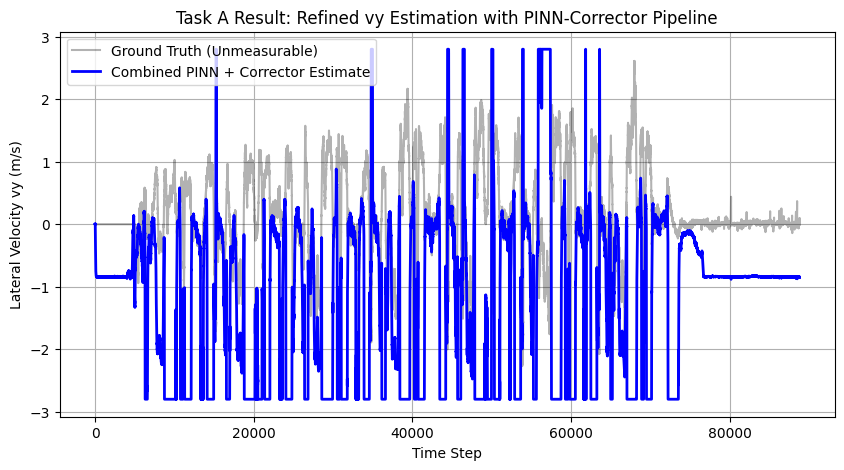

In [118]:

# Calculate Final RMSE
def calculate_rmse(predictions, ground_truth):
    # Only compare from index 1 onward (k=1 to k+n)
    return np.sqrt(np.mean((predictions[1:] - ground_truth[1:]) ** 2))

rmse_vy_refined = calculate_rmse(vy_est_refined, vy_true)

print("\n--- Final Combined State Estimation Performance ---")
print(f"Final RMSE (Lateral Velocity, vy) Refined: {rmse_vy_refined:.4f} m/s")
print("--------------------------------------------------")

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(vy_true, 'k-', label='Ground Truth (Unmeasurable)', alpha=0.3)
plt.plot(vy_est_refined, 'b', label='Combined PINN + Corrector Estimate', linewidth=2)
plt.title("Task A Result: Refined vy Estimation with PINN-Corrector Pipeline")
plt.xlabel("Time Step")
plt.ylabel("Lateral Velocity vy (m/s)")
plt.legend()
plt.grid(True)
plt.show()

In [138]:
import numpy as np
import torch

def estimate_vy_self_loop(
    model,
    df_phys,
    scaler_vx,  # Individual scaler for vx
    scaler_vy,  # Individual scaler for vy
    scaler_r,   # Individual scaler for r
    scaler_ax,  # Individual scaler for ax
    scaler_ay,  # Individual scaler for ay
    scaler_Y,   # Combined scaler for output [vx_next, vy_next]
    vy0=0.0,
    vy_min=None, # **FIXED BOUNDS based on your data analysis**
    vy_max=None,  # **FIXED BOUNDS based on your data analysis**
    device=None,
    verbose=False,
):
    """
    Run the trained PINN in a self-loop to estimate vy.
    
    NOTE: This version uses individual scalers (vx, vy, r, ax, ay) for input
    and the combined scaler_Y for inverse-scaling the output.
    """

    model.eval()
    if device is None:
        device = next(model.parameters()).device

    # Extract physical signals
    vx = df_phys['vxCG'].values
    ax = df_phys['axCG'].values
    ay = df_phys['ayCG'].values
    r  = df_phys['yawRate'].values
    T  = len(df_phys)
    
    # Ensure bounds are set, using your determined physical limits
    if vy_min is None: vy_min = -2.8 
    if vy_max is None: vy_max = 2.8

    vy_hat = np.zeros(T, dtype=np.float64)
    vy_hat[0] = np.clip(vy0, vy_min, vy_max)

    for k in range(T - 1):
        # Clip current vy to training range
        cur_vy = np.clip(vy_hat[k], vy_min, vy_max)

        # 1. Build input in PHYSICAL units (same order as PINN training: [vx, vy, r, ax, ay])
        # Note: The original code used [vx, cur_vy, ax, ay, r]. We match your training order.
        
        # 2. Scale Input using individual scalers
        x_scaled = np.column_stack([
            scaler_vx.transform(np.array([[vx[k]]])),
            scaler_vy.transform(np.array([[cur_vy]])),
            scaler_r.transform(np.array([[r[k]]])),      # r is yawRate
            scaler_ax.transform(np.array([[ax[k]]])),    # ax is acc_x
            scaler_ay.transform(np.array([[ay[k]]]))     # ay is acc_y
        ])
        
        x_t = torch.from_numpy(x_scaled).float().to(device)

        with torch.no_grad():
            y_scaled_t = model(x_t)

        y_scaled = y_scaled_t.cpu().numpy()  # shape (1, 2)

        # Check for NaN/inf in scaled outputs
        if not np.isfinite(y_scaled).all():
            print(f"Non-finite model output at step k={k}")
            raise ValueError("Model produced NaN/inf during self-loop.")

        # 3. Manually inverse-scale using scaler_Y components
        # This is the same as the original code's manual inverse-scale
        y_phys = y_scaled * scaler_Y.scale_ + scaler_Y.mean_  # (1, 2)

        # vx_next is index 0, vy_next is index 1
        vx_next_pred, vy_next_pred = y_phys[0, 0], y_phys[0, 1]

        # Optional debug prints
        if verbose and k % 200 == 0:
            print(
                f"k={k}, vx={vx[k]:.3f}, vy_hat={cur_vy:.3f} -> "
                f"vx_pred_next={vx_next_pred:.3f}, vy_pred_next={vy_next_pred:.3f}"
            )

        # 4. Update vy estimate for k+1 and apply tight clamp
        vy_hat[k + 1] = np.clip(vy_next_pred, vy_min, vy_max)

    return vy_hat

In [139]:
#in order to avoid overshooting during self-loop prediction, we can limit the vy range based on training data percentiles
vy_min_train, vy_max_train = np.percentile(train_data['vyCG'], [1, 99]) #significant decrease in rmse 0.98 ---> 0.57

print("vy range in train data:", vy_min_train, "to", vy_max_train)


#in order to avoid overshooting during self-loop prediction, we can limit the vy range based on training data percentiles
vy_min_test, vy_max_test = np.percentile(test_data['vyCG'], [1, 99]) #significant decrease in rmse 0.98 ---> 0.57

print("vy range in train data:", vy_min_test, "to", vy_max_test)

vy range in train data: -0.7976292959890513 to 0.9839650683388749
vy range in train data: -1.631377393133447 to 1.7728194300070526


In [140]:
vy_hat_test_noclip = estimate_vy_self_loop(
    model=model,
    df_phys=test_data,
    scaler_vx=scaler_vx,
    scaler_vy=scaler_vy,
    scaler_r=scaler_r,
    scaler_ax=scaler_ax,
    scaler_ay=scaler_ay,
    scaler_Y=scaler_Y,
    vy0=0.0,
    vy_min=vy_min_test,
    vy_max=vy_max_test,
)

In [141]:
# 2. Compare RMSE
# Note: The comparison starts from index 1 (the first predicted step)

# Ground-truth vy on TRAIN
vy_true_test = test_data['vyCG'].values

rmse_noclip = np.sqrt(np.mean((vy_hat_test_noclip[1:] - vy_true_test[1:])**2))

# 3. Print Results
print("RMSE without tight clipping:", rmse_noclip)
#print("RMSE with clipping:       ", rmse_vy_selfloop_test)

RMSE without tight clipping: 0.6117035799941899


In [142]:
# ---- Self-loop on TRAIN trajectory ----
vy_hat_train = estimate_vy_self_loop(
    model=model,
    df_phys=train_data,    # physical train trajectory
    scaler_vx=scaler_vx,
    scaler_vy=scaler_vy,
    scaler_r=scaler_r,
    scaler_ax=scaler_ax,
    scaler_ay=scaler_ay,
    scaler_Y=scaler_Y,
    vy0=0.0,                      # initialize vy(0) = 0
    vy_min=vy_min_train,
    vy_max=vy_max_train,
    verbose=False,
)

# Ground-truth vy on TRAIN
vy_true_train = train_data['vyCG'].values

# Ignore k=0 because vy0 was an arbitrary guess (not predicted)
rmse_vy_selfloop_train = np.sqrt(
    np.mean((vy_hat_train[1:] - vy_true_train[1:])**2)
)
print(f"Self-loop vy RMSE on TRAIN (m/s): {rmse_vy_selfloop_train:.4f}")

Self-loop vy RMSE on TRAIN (m/s): 0.3327
